# Real-Data ProtoHedge Tests - PyTorch

This notebook is the main workspace for **Axis 1: testing ProtoHedge on real empirical data**.

The goal is not just to make the code run. The goal is to decide whether the PyTorch ProtoHedge pipeline is credible enough for real-data research:

1. Load cleaned empirical hedging episodes.
2. Train vanilla Deep Hedging and ProtoHedge on the same train split.
3. Extract prototypes only from train trajectories, with no train/test leakage.
4. Evaluate on clean validation and test splits.
5. Compare against baselines.
6. Inspect whether learned prototypes correspond to recognizable market states.
7. Stress the model across regimes such as high volatility, selloffs, calm markets, and rallies.

This notebook assumes the cleaned WRDS-derived episode tensor already exists at `Data/training_paths.npy` with shape `[n_paths, n_steps, 5]` and feature order:

`spot`, `call_price`, `call_delta`, `call_vega`, `ivol`.

## How This Maps To The Paper's Empirical-Validation Goal

The ProtoHedge paper says the next crucial step is empirical validation: train on historical market data, test robustness to real frictions and non-stationarity, backtest performance, and check whether prototypes correspond to recognizable market scenarios like crises or flash crashes.

This notebook operationalizes that request as a concrete test bench:

- **Historical dynamics:** We replace `SimpleWorld_Spot_ATM` simulation with `RealWorld_Spot_ATM_Torch` loading empirical episodes.
- **Market frictions:** The real-data world uses spot and option transaction costs from the real-world setup.
- **No leakage:** Splits are explicit; prototypes are extracted from the train split only.
- **Backtest-style holdout:** We report train/validation/test distributions, not just training loss.
- **Interpretability:** We unscale prototypes, inspect their actions, usage, and relation to market states.
- **Regime robustness:** We group test episodes by spot-return and volatility regimes.

For now this is for the current real-data tensor. Later, we should repeat this notebook across tickers, markets, dates, and option types.

## What Means ProtoHedge Works?

ProtoHedge works on real data only if it passes several gates. A single pretty plot is not enough.

**Minimum correctness gates**

- The real-data world loads without NaNs or shape mismatches.
- Vanilla and ProtoHedge training produce finite `utility`, `utility0`, `pnl`, `gains`, `actions`, and `payoff`.
- Prototype extraction produces a payload with `prototypes` and `scaler`.
- Prototype dimensions match the model input features.
- Prototype extraction is fit only on training trajectories.
- Evaluation uses held-out validation/test paths.

**Economic-validity gates**

- Real prices are optionally normalized by initial spot so the empirical world is on the same scale as the original synthetic worlds.
- The default real-data test uses `hedge_mode="terminal"`, which matches the original Deep Hedging convention: an action at time `t` is a trade whose P&L is evaluated to the hedge horizon.
- Cumulative position bounds are optional market constraints, not a change to ProtoHedge's architecture. They prevent the neural network from turning a hedging experiment into an unconstrained leveraged directional trading strategy.

**Performance gates**

- ProtoHedge should improve over unhedged payoff on test utility and downside/tail metrics.
- ProtoHedge should be competitive with vanilla Deep Hedging on held-out test data under the same market constraints.
- ProtoHedge should also be compared with a simple empirical spot-delta baseline.
- It does not need to beat vanilla in every tiny run, but if it consistently underperforms after tuning, the prototype bottleneck is not working for this dataset.

**Interpretability gates**

- Frequently used prototypes should correspond to coherent market states.
- Prototype actions should be financially plausible, stable, and not just arbitrary saturation at action bounds.
- Similar market states should activate similar prototypes.

**Robustness gates**

- Results should not collapse in high-volatility, selloff, or other stress regimes.
- Prototype usage should shift in understandable ways across regimes.
- Results should remain qualitatively stable across seeds, prototype counts, and train/test splits.

## Testing Roadmap For Axis 1

Your project roadmap is:

1. **Gather Data from WRDS** - done outside this notebook.
2. **Clean the data and extract what we need** - produces `Data/training_paths.npy`.
3. **Extract hedging episodes** - paths shaped `[episode, step, feature]`.
4. **Integrate data into ProtoHedge** - handled by `RealWorld_Spot_ATM_Torch` and `run_train_torch.py`.
5. **Run ProtoHedge on real data** - this notebook.
6. **Compare with baselines** - unhedged, vanilla Deep Hedging, and later classical delta-style baselines.
7. **Analyze learned prototypes** - prototype tables, action maps, usage heatmaps.
8. **Backtest performance** - out-of-sample gains, tail risk, CVaR-style summaries.
9. **Evaluate market regimes** - return and volatility buckets.
10. **Repeat across tickers/markets/models** - future extension once this single-dataset harness is stable.

## 0. Setup

Run this notebook from the repo root or from `notebooks/`. The path setup below handles both.

In [105]:
from pathlib import Path
import sys
import json
import pickle
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
REPO_PARENT = REPO_ROOT.parent

# Hard guard: this notebook must use the local repo files, not an installed
# deephedging package and not classes cached from an earlier kernel state.
assert (REPO_ROOT / "world_real_torch.py").exists(), f"Could not find local repo module at {REPO_ROOT / 'world_real_torch.py'}"

repo_parent_str = str(REPO_PARENT)
sys.path = [p for p in sys.path if Path(p or ".").resolve() != REPO_PARENT]
sys.path.insert(0, repo_parent_str)

# Force a fresh import of all local deephedging modules. This is deliberately
# stronger than importlib.reload because a stale kernel may already have loaded
# deephedging from a different path or with older class definitions.
for module_name in list(sys.modules):
    if module_name == "deephedging" or module_name.startswith("deephedging."):
        del sys.modules[module_name]

from deephedging.base_torch import torchCast
from deephedging.prototype_extraction_torch import build_prototype_payload, save_prototype_payload
from deephedging.run_train_torch import run_experiment
from deephedging.world_real_torch import RealWorld_Spot_ATM_Torch
import deephedging.world_real_torch as world_real_torch
import deephedging.run_train_torch as run_train_torch

world_module_path = Path(world_real_torch.__file__).resolve()
expected_world_module_path = (REPO_ROOT / "world_real_torch.py").resolve()
assert world_module_path == expected_world_module_path, (
    "Imported the wrong world_real_torch.py. "
    f"Expected {expected_world_module_path}, got {world_module_path}. "
    "Restart the kernel and run this setup cell first."
)

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (9, 5)

print("repo root:", REPO_ROOT)
print("repo parent first on sys.path:", sys.path[0])
print("torch:", torch.__version__)
print("RealWorld module:", world_module_path)
print("run_train_torch module:", Path(run_train_torch.__file__).resolve())

repo root: /Users/yaniszaim/deephedging
repo parent first on sys.path: /Users/yaniszaim
torch: 2.5.1
RealWorld module: /Users/yaniszaim/deephedging/world_real_torch.py
run_train_torch module: /Users/yaniszaim/deephedging/run_train_torch.py


## 1. Experiment Configuration

The early notebook sections stay relatively light so `Run All` does not spend hours repeating the same single-model experiment blocks. The serious empirical result now comes from the robustness-focused sweep near the end of the notebook.

That sweep is configured to test the next paper question directly:

- tighter market constraints,
- validation-based checkpoint selection,
- mild action / delta regularization,
- explicit robustness screens for bound dependence.

The point is not to change ProtoHedge into a different model. The point is to test whether ProtoHedge remains competitive once we stop rewarding clearly boundary-seeking behavior.

In [106]:
DATA_PATH = REPO_ROOT / "Data" / "training_paths.npy"
OUTPUT_DIR = REPO_ROOT / ".deephedging_real_runs" / "notebook_real_data_robust_diagnostics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 1234
SAMPLES = 512       # Keep the early notebook sections light; the sweep section below runs on all paths.
EPOCHS = 5          # Quick diagnostics only. The full empirical sweep below uses 800 epochs.
N_PROTOTYPES = 25
BATCH_SIZE = None   # None means the trainer uses its default mini-batch behavior.
LR = 1e-3
MAX_POINTS = None   # Optional cap for KMeans prototype extraction rows.

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

# Real-data environment controls. These are market/environment choices, not
# changes to the ProtoHedge architecture.
NORMALIZE_REAL_WORLD = True
HEDGE_MODE = "step"           # Match the original TensorFlow real-data world (`world_real.py`) one-step hedge increments.
USE_POSITION_BOUNDS = True

BASE_TRADE_BOUNDS = {
    "lbnd_as": -5.0,
    "ubnd_as": 5.0,
    "lbnd_av": -5.0,
    "ubnd_av": 5.0,
}
BASE_POSITION_BOUNDS = {
    "lbnd_delta_s": -2.0,
    "ubnd_delta_s": 2.0,
    "lbnd_delta_v": -2.0,
    "ubnd_delta_v": 2.0,
}

# Robust-testing defaults. These keep the model class unchanged but tighten the
# admissible market region so the sweep tests economically cleaner behavior.
ROBUST_TRADE_BOUNDS = {
    "lbnd_as": -1.0,
    "ubnd_as": 1.0,
    "lbnd_av": -1.0,
    "ubnd_av": 1.0,
}
ROBUST_POSITION_BOUNDS = {
    "lbnd_delta_s": -1.0,
    "ubnd_delta_s": 1.0,
    "lbnd_delta_v": -1.0,
    "ubnd_delta_v": 1.0,
}

TRADE_BOUNDS = ROBUST_TRADE_BOUNDS.copy()
POSITION_BOUNDS = ROBUST_POSITION_BOUNDS.copy()

# Validation-based model selection. The trainer still optimizes the same
# hedging objective, but the saved checkpoint is chosen using validation loss
# plus explicit penalties for aggressive trading and bound usage.
TRAIN_SELECTION_CFG = {
    "selection_metric": "val_loss",
    "selection_alpha_action_abs": 0.005,
    "selection_alpha_delta_abs": 0.010,
    "selection_alpha_bound_occupancy": 0.100,
    "selection_alpha_path_bound_touch": 0.0,
}

# Mild regularization on actions / positions. These are intentionally small:
# they nudge the optimizer away from unnecessarily extreme hedge paths without
# redefining the ProtoHedge objective.
TRAIN_REG_CFG = {
    "action_penalty_weight": 0.001,
    "delta_penalty_weight": 0.002,
}

# Screening rule for interpreting a completed sweep. Passing the screen does not
# prove a model is good, but failing it means the result is not paper-ready.
ROBUST_SCREEN_CFG = {
    "max_bound_occupancy": 0.50,
    "max_path_touch_rate": None,
}

FEATURE_ORDER_IN_FILE = ["spot", "call_price", "call_delta", "call_vega", "ivol"]
MODEL_FEATURES = ["price", "delta", "time_left"]

print("data:", DATA_PATH)
print("output:", OUTPUT_DIR)
print("normalize:", NORMALIZE_REAL_WORLD)
print("hedge_mode:", HEDGE_MODE)
print("trade_bounds:", TRADE_BOUNDS)
print("position_bounds:", USE_POSITION_BOUNDS, POSITION_BOUNDS if USE_POSITION_BOUNDS else None)
print("selection_cfg:", TRAIN_SELECTION_CFG)
print("regularization_cfg:", TRAIN_REG_CFG)
print("robust_screen_cfg:", ROBUST_SCREEN_CFG)

data: /Users/yaniszaim/deephedging/Data/training_paths.npy
output: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_robust_diagnostics
normalize: True
hedge_mode: step
trade_bounds: {'lbnd_as': -1.0, 'ubnd_as': 1.0, 'lbnd_av': -1.0, 'ubnd_av': 1.0}
position_bounds: True {'lbnd_delta_s': -1.0, 'ubnd_delta_s': 1.0, 'lbnd_delta_v': -1.0, 'ubnd_delta_v': 1.0}
selection_cfg: {'selection_metric': 'val_loss', 'selection_alpha_action_abs': 0.005, 'selection_alpha_delta_abs': 0.01, 'selection_alpha_bound_occupancy': 0.1, 'selection_alpha_path_bound_touch': 0.0}
regularization_cfg: {'action_penalty_weight': 0.001, 'delta_penalty_weight': 0.002}
robust_screen_cfg: {'max_bound_occupancy': 0.5, 'max_path_touch_rate': None}


## 2. Load And Validate The Real Dataset

The current real-data tensor should have shape `[n_paths, 20, 5]`. The five columns are expected to be spot, call price, call delta, call vega, and implied volatility.

In [107]:
paths = np.load(DATA_PATH, mmap_mode="r")
print("shape:", paths.shape)
print("dtype:", paths.dtype)

assert paths.ndim == 3, f"Expected [paths, steps, features], got {paths.shape}"
assert paths.shape[-1] >= 5, f"Expected at least 5 features, got {paths.shape[-1]}"
assert np.isfinite(paths).all(), "Real-data tensor contains NaN or infinite values"

summary_rows = []
for i, name in enumerate(FEATURE_ORDER_IN_FILE):
    x = np.asarray(paths[:, :, i])
    summary_rows.append({
        "feature": name,
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "min": float(np.min(x)),
        "p01": float(np.quantile(x, 0.01)),
        "p50": float(np.quantile(x, 0.50)),
        "p99": float(np.quantile(x, 0.99)),
        "max": float(np.max(x)),
    })

data_summary = pd.DataFrame(summary_rows)
display(data_summary)

shape: (4485, 20, 5)
dtype: float64


,feature,mean,std,min,p01,p50,p99,max
0,spot,247.681312,127.162452,68.110000,83.680000,208.970000,573.760010,607.810000
1,call_price,107.492528,87.317232,3.870000,9.305000,77.525000,351.690000,483.020000
2,call_delta,0.993802,0.011497,0.748129,0.951260,0.996863,0.999951,0.999994
3,call_vega,0.930705,1.197486,0.000083,0.008794,0.521673,6.160625,16.427170
4,ivol,0.936722,0.899986,0.083625,0.127532,0.646663,4.453875,8.474846


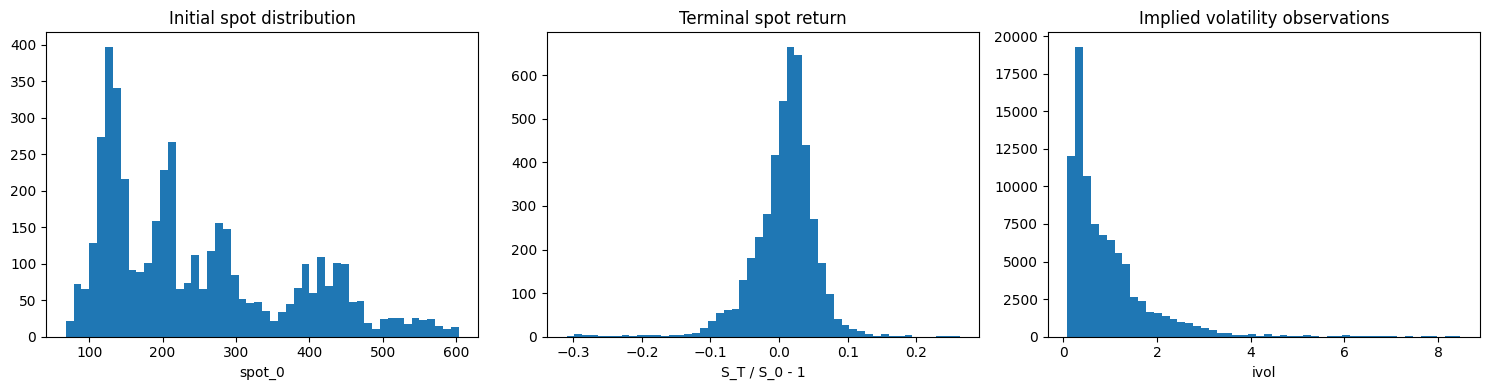

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(np.asarray(paths[:, 0, 0]), bins=50)
axes[0].set_title("Initial spot distribution")
axes[0].set_xlabel("spot_0")

terminal_return = np.asarray(paths[:, -1, 0] / paths[:, 0, 0] - 1.0)
axes[1].hist(terminal_return, bins=50)
axes[1].set_title("Terminal spot return")
axes[1].set_xlabel("S_T / S_0 - 1")

axes[2].hist(np.asarray(paths[:, :, 4]).reshape(-1), bins=50)
axes[2].set_title("Implied volatility observations")
axes[2].set_xlabel("ivol")

plt.tight_layout()
plt.show()

## 3. Train / Validation / Test Split

Splits are explicit arrays of path indices. This matters because prototypes must be extracted from the training split only.

In [109]:
def split_indices(n_paths, train_frac=0.70, val_frac=0.15, seed=1234, samples=None):
    if train_frac <= 0 or val_frac <= 0 or train_frac + val_frac >= 1:
        raise ValueError("Require train_frac > 0, val_frac > 0, and train_frac + val_frac < 1")

    rng = np.random.default_rng(seed)
    idx = rng.permutation(int(n_paths))
    if samples is not None:
        samples = int(samples)
        if samples <= 2:
            raise ValueError("samples must leave room for train, validation, and test splits")
        idx = idx[:samples]

    n = len(idx)
    n_train = max(1, int(np.floor(n * train_frac)))
    n_val = max(1, int(np.floor(n * val_frac)))
    if n_train + n_val >= n:
        raise ValueError("No test paths left; increase samples or reduce split fractions")

    return {
        "train": idx[:n_train].astype(np.int64),
        "val": idx[n_train:n_train+n_val].astype(np.int64),
        "test": idx[n_train+n_val:].astype(np.int64),
    }

splits = split_indices(paths.shape[0], TRAIN_FRAC, VAL_FRAC, SEED, SAMPLES)
np.savez(OUTPUT_DIR / "splits.npz", **splits)

split_df = pd.DataFrame({"split": list(splits), "n_paths": [len(v) for v in splits.values()]})
display(split_df)
print("saved:", OUTPUT_DIR / "splits.npz")

,split,n_paths
0,train,358
1,val,76
2,test,78


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_robust_diagnostics/splits.npz


## 4. Helper Functions

These helpers keep the notebook state explicit. The important point: `world_cfg(..., val_indices=...)` passes a true validation split into `run_experiment`.

In [110]:
REQUIRED_RESULT_KEYS = ["utility", "utility0", "pnl", "gains", "actions", "payoff"]
SUMMARY_KEYS = ["utility", "utility0", "gains", "payoff", "pnl", "cost"]


def as_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def world_cfg(indices, val_indices=None):
    cfg = {
        "world_type": "real",
        "data_path": str(DATA_PATH),
        "sample_indices": [int(i) for i in indices],
        "shuffle": False,
        "seed": int(SEED),
        "normalize": bool(NORMALIZE_REAL_WORLD),
        "hedge_mode": HEDGE_MODE,
        "position_bounds": bool(USE_POSITION_BOUNDS),
        **TRADE_BOUNDS,
    }
    if USE_POSITION_BOUNDS:
        cfg.update(POSITION_BOUNDS)
    if val_indices is not None:
        cfg["val_sample_indices"] = [int(i) for i in val_indices]
    return cfg


def training_cfg(epochs=EPOCHS, epoch_refresh=None):
    epoch_refresh = max(1, int(epochs if epoch_refresh is None else epoch_refresh))
    return {
        "epochs": int(epochs),
        "lr": float(LR),
        "batch_size": BATCH_SIZE,
        "epoch_refresh": epoch_refresh,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": None,
        "lr_decay_patience": None,
        **TRAIN_SELECTION_CFG,
        **TRAIN_REG_CFG,
    }


def objective_cfg():
    return {"risk_measure": "cvar", "risk_aversion": 1.0}


def vanilla_model_cfg():
    return {
        "agent_type": "feed_forward",
        "feature_list": MODEL_FEATURES,
        "network_width": 20,
        "network_depth": 3,
        "activation": "softplus",
    }


def proto_model_cfg(prototype_path):
    return {
        "agent_type": "protopnet",
        "prototype_path": str(prototype_path),
        "feature_list": MODEL_FEATURES,
        "weighted_similarity": True,
        "learn_distance_feature_weights": False,
    }


def assert_finite_result(label, result):
    for key in REQUIRED_RESULT_KEYS:
        assert key in result, f"{label}: missing result['{key}']"
        values = as_numpy(result[key])
        assert np.isfinite(values).all(), f"{label}: non-finite values in result['{key}']"


def assert_finite_baseline(label, result):
    for key in ["pnl", "gains", "actions", "payoff", "cost"]:
        assert key in result, f"{label}: missing result['{key}']"
        values = as_numpy(result[key])
        assert np.isfinite(values).all(), f"{label}: non-finite values in result['{key}']"


def position_bound_metrics(deltas, market, tol=1e-4):
    metrics = {
        "pct_at_any_position_bound": 0.0,
        "pct_at_upper_position_bound": 0.0,
        "pct_at_lower_position_bound": 0.0,
        "pct_paths_touch_any_position_bound": 0.0,
    }
    if market is None or "ubnd_delta" not in market or "lbnd_delta" not in market:
        return metrics

    ub = np.asarray(market.ubnd_delta)
    lb = np.asarray(market.lbnd_delta)
    near_upper = np.isclose(deltas, ub, atol=tol, rtol=0.0)
    near_lower = np.isclose(deltas, lb, atol=tol, rtol=0.0)
    near_bound = near_upper | near_lower
    metrics.update({
        "pct_at_any_position_bound": float(np.mean(near_bound)),
        "pct_at_upper_position_bound": float(np.mean(near_upper)),
        "pct_at_lower_position_bound": float(np.mean(near_lower)),
        "pct_paths_touch_any_position_bound": float(np.mean(np.any(near_bound, axis=(1, 2)))),
    })
    return metrics


def summarize_result(result, market=None):
    metrics = {}
    for key in SUMMARY_KEYS:
        if key not in result:
            continue
        values = as_numpy(result[key]).reshape(-1)
        metrics[f"{key}_mean"] = float(np.mean(values))
        metrics[f"{key}_std"] = float(np.std(values))
        metrics[f"{key}_p01"] = float(np.quantile(values, 0.01))
        metrics[f"{key}_p05"] = float(np.quantile(values, 0.05))
        metrics[f"{key}_p50"] = float(np.quantile(values, 0.50))
        metrics[f"{key}_p95"] = float(np.quantile(values, 0.95))
        metrics[f"{key}_p99"] = float(np.quantile(values, 0.99))

    if "actions" in result:
        actions = as_numpy(result["actions"])
        metrics["action_abs_mean"] = float(np.mean(np.abs(actions)))
        metrics["action_abs_max"] = float(np.max(np.abs(actions)))
        metrics["action_shape"] = list(actions.shape)
    if "deltas" in result:
        deltas = as_numpy(result["deltas"])
        metrics["delta_abs_mean"] = float(np.mean(np.abs(deltas)))
        metrics["delta_abs_max"] = float(np.max(np.abs(deltas)))
        metrics.update(position_bound_metrics(deltas=deltas, market=market))
    return metrics


def evaluate_gym(gym, indices, label):
    world = RealWorld_Spot_ATM_Torch(world_cfg(indices))
    data = torchCast(world.torch_data)
    gym.eval()
    with torch.no_grad():
        result = gym.forward(data, training=False, return_paths=True)
    assert_finite_result(label, result)
    result = {k: v.detach().cpu() if isinstance(v, torch.Tensor) else v for k, v in result.items()}
    metrics = summarize_result(result, market=world.data.market)
    metrics.update({"n_paths": int(world.nSamples), "n_steps": int(world.nSteps), "n_inst": int(world.nInst)})
    return world, result, metrics


def evaluate_unhedged(indices):
    world = RealWorld_Spot_ATM_Torch(world_cfg(indices))
    payoff = np.asarray(world.data.market.payoff, dtype=np.float32)
    n_paths, n_steps, n_inst = world.data.market.hedges.shape
    result = {
        "payoff": payoff,
        "pnl": np.zeros_like(payoff),
        "cost": np.zeros_like(payoff),
        "gains": payoff.copy(),
        "actions": np.zeros((n_paths, n_steps, n_inst), dtype=np.float32),
        "deltas": np.zeros((n_paths, n_steps, n_inst), dtype=np.float32),
    }
    assert_finite_baseline("unhedged", result)
    metrics = summarize_result(result, market=world.data.market)
    metrics.update({"n_paths": int(world.nSamples), "n_steps": int(world.nSteps), "n_inst": int(world.nInst)})
    return world, result, metrics


def evaluate_spot_delta_baseline(indices):
    """Spot-only empirical delta hedge under the same world/gym accounting.

    For a short call, a simple hedge holds a long spot position close to the
    empirical call delta. Actions are trades into that target cumulative
    position, then the same transaction costs and optional position bounds are
    applied as the neural models.
    """
    world = RealWorld_Spot_ATM_Torch(world_cfg(indices))
    market = world.data.market
    hedges = np.asarray(market.hedges, dtype=np.float32)
    trading_cost = np.asarray(market.cost, dtype=np.float32)
    payoff = np.asarray(market.payoff, dtype=np.float32)
    ubnd_a = np.asarray(market.ubnd_a, dtype=np.float32)
    lbnd_a = np.asarray(market.lbnd_a, dtype=np.float32)
    ubnd_delta = np.asarray(market.ubnd_delta, dtype=np.float32) if "ubnd_delta" in market else None
    lbnd_delta = np.asarray(market.lbnd_delta, dtype=np.float32) if "lbnd_delta" in market else None

    call_delta = np.asarray(world.data.features.per_step["call_delta"], dtype=np.float32)
    n_paths, n_steps, n_inst = hedges.shape
    delta = np.zeros((n_paths, n_inst), dtype=np.float32)
    actions = np.zeros((n_paths, n_steps, n_inst), dtype=np.float32)
    deltas = np.zeros((n_paths, n_steps, n_inst), dtype=np.float32)
    pnl = np.zeros((n_paths,), dtype=np.float32)
    cost = np.zeros((n_paths,), dtype=np.float32)

    for t in range(n_steps):
        target_delta = np.zeros_like(delta)
        target_delta[:, 0] = call_delta[:, t]
        if ubnd_delta is not None and lbnd_delta is not None:
            target_delta = np.minimum(np.maximum(target_delta, lbnd_delta[:, t, :]), ubnd_delta[:, t, :])

        action = target_delta - delta
        action = np.minimum(np.maximum(action, lbnd_a[:, t, :]), ubnd_a[:, t, :])
        if ubnd_delta is not None and lbnd_delta is not None:
            bounded_delta = np.minimum(np.maximum(delta + action, lbnd_delta[:, t, :]), ubnd_delta[:, t, :])
            action = bounded_delta - delta

        pnl += np.sum(action * hedges[:, t, :], axis=1)
        cost += np.sum(np.abs(action) * trading_cost[:, t, :], axis=1)
        delta += action
        actions[:, t, :] = action
        deltas[:, t, :] = delta

    result = {
        "payoff": payoff,
        "pnl": pnl,
        "cost": cost,
        "gains": payoff + pnl - cost,
        "actions": actions,
        "deltas": deltas,
    }
    assert_finite_baseline("spot_delta", result)
    metrics = summarize_result(result, market=world.data.market)
    metrics.update({"n_paths": int(world.nSamples), "n_steps": int(world.nSteps), "n_inst": int(world.nInst)})
    return world, result, metrics


def metrics_to_df(metrics):
    rows = []
    for model_name, split_metrics in metrics.items():
        for split_name, values in split_metrics.items():
            row = {"model": model_name, "split": split_name}
            row.update({k: v for k, v in values.items() if not isinstance(v, list)})
            rows.append(row)
    return pd.DataFrame(rows)

## 5. RealWorld Construction Smoke Test

Before training, verify the world exposes the objects expected by `DeepHedgingGymTorch`.

In [111]:
smoke_cfg = world_cfg(splits["train"][:min(32, len(splits["train"]))])
print("RealWorld class module:", RealWorld_Spot_ATM_Torch.__module__)
print("RealWorld module file:", Path(sys.modules[RealWorld_Spot_ATM_Torch.__module__].__file__).resolve())
print("smoke world cfg:", {k: smoke_cfg[k] for k in ["normalize", "hedge_mode", "position_bounds"] if k in smoke_cfg})

smoke_world = RealWorld_Spot_ATM_Torch(smoke_cfg)
print("nSamples:", smoke_world.nSamples)
print("nSteps:", smoke_world.nSteps)
print("nInst:", smoke_world.nInst)
print("normalize:", getattr(smoke_world, "normalize", None))
print("hedge_mode:", getattr(smoke_world, "hedge_mode", None))
print("position_bounds:", getattr(smoke_world, "position_bounds", None))
print("hedges:", smoke_world.data.market.hedges.shape)
print("cost:", smoke_world.data.market.cost.shape)
print("price feature:", smoke_world.data.features.per_step["price"].shape)
print("payoff:", smoke_world.data.market.payoff.shape)
print("inst_names:", smoke_world.inst_names)

if NORMALIZE_REAL_WORLD:
    if smoke_cfg.get("normalize") is not True:
        raise RuntimeError(f"world_cfg did not set normalize=True. smoke_cfg={smoke_cfg}")
    if getattr(smoke_world, "normalize", None) is not True:
        raise RuntimeError(
            "NORMALIZE_REAL_WORLD=True, but RealWorld_Spot_ATM_Torch did not report normalize=True. "
            "Restart the notebook kernel, then run cells from the top so the updated world_real_torch.py is reloaded."
        )
    initial_spot = np.asarray(smoke_world.data.features.per_step["spot"][:, 0])
    if not np.allclose(initial_spot, 1.0, rtol=1e-6, atol=1e-6):
        raise AssertionError(
            "Expected normalized initial spot to equal 1.0, but got raw-looking values. "
            f"First five spot_0 values: {initial_spot[:5]}. "
            f"RealWorld class file: {Path(sys.modules[RealWorld_Spot_ATM_Torch.__module__].__file__).resolve()}. "
            "This means the notebook is still using stale code or an older open copy of the notebook. "
            "Save/reload this notebook file in Jupyter, restart the kernel, and run the setup cell first."
        )
    print("normalization check: spot_0 == 1")

if USE_POSITION_BOUNDS:
    assert "ubnd_delta" in smoke_world.data.market
    assert "lbnd_delta" in smoke_world.data.market
    print("position bounds check:", smoke_world.data.market.lbnd_delta[0, 0, :], smoke_world.data.market.ubnd_delta[0, 0, :])

# Payoff should be short ATM-start call in the chosen price scale.
spot = smoke_world.data.features.per_step["spot"]
expected_payoff = -np.maximum(spot[:, -1] - spot[:, 0], 0.0)
np.testing.assert_allclose(smoke_world.data.market.payoff, expected_payoff, rtol=1e-5, atol=1e-6)
print("payoff check: ok")

RealWorld class module: deephedging.world_real_torch
RealWorld module file: /Users/yaniszaim/deephedging/world_real_torch.py
smoke world cfg: {'normalize': True, 'hedge_mode': 'step', 'position_bounds': True}
nSamples: 32
nSteps: 20
nInst: 2
normalize: True
hedge_mode: step
position_bounds: True
hedges: (32, 20, 2)
cost: (32, 20, 2)
price feature: (32, 20, 2)
payoff: (32,)
inst_names: ['spot', 'ATM Call']
normalization check: spot_0 == 1
position bounds check: [-1. -1.] [1. 1.]
payoff check: ok


## 5b. Environment Semantics And Baselines

This notebook now defaults to the stricter empirical setup we want for real-data testing:

- `NORMALIZE_REAL_WORLD=True` divides spot, call price, call vega, hedge P&L, costs, and payoff by each path's initial spot. This puts empirical paths on the same rough scale as the original synthetic worlds.
- `HEDGE_MODE="terminal"` makes hedge P&L follow the original Deep Hedging convention: a trade at time `t` is evaluated to the hedge horizon, matching the synthetic world design. The previous raw real-data smoke mode used one-step increments and remains available as `HEDGE_MODE="step"`.
- `USE_POSITION_BOUNDS=True` adds cumulative position constraints as market data. The agent architecture and ProtoHedge similarity mechanism are unchanged; both vanilla and ProtoHedge simply trade inside the same admissible market.
- The empirical spot-delta baseline below uses the same world accounting and costs, so it is a fairer baseline than eyeballing raw payoff alone.

In [112]:
# Quick baseline smoke checks before training neural models.
_, unhedged_smoke, unhedged_smoke_metrics = evaluate_unhedged(splits["train"][:min(64, len(splits["train"]))])
_, delta_smoke, delta_smoke_metrics = evaluate_spot_delta_baseline(splits["train"][:min(64, len(splits["train"]))])

display(pd.DataFrame([
    {"baseline": "unhedged", **unhedged_smoke_metrics},
    {"baseline": "spot_delta", **delta_smoke_metrics},
])[["baseline", "gains_mean", "gains_p05", "gains_p50", "action_abs_mean", "delta_abs_max"]])

,baseline,gains_mean,gains_p05,gains_p50,action_abs_mean,delta_abs_max
0,unhedged,-0.020729,-0.065083,-0.010944,0.000000,0.000000
1,spot_delta,-0.020405,-0.072553,-0.013538,0.027466,0.999994


## 6. Train Vanilla Deep Hedging On Real Data

This is the non-prototype neural baseline. ProtoHedge should be compared against this, not only against the unhedged payoff.

In [113]:
results_real_vanilla = run_experiment(
    override_world=world_cfg(splits["train"], val_indices=splits["val"]),
    override_model=vanilla_model_cfg(),
    override_objective=objective_cfg(),
    override_training=training_cfg(EPOCHS),
)


PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.1350 | train 0.0943 | val 0.0862 | select 0.1412


## 7. Extract Real-Data Prototypes From Train Split Only

This is where leakage can accidentally creep in. We use `results_real_vanilla["world"]`, which is the train world, and `results_real_vanilla["training_result"]`, which is the train trajectory output.

In [114]:
prototype_payload = build_prototype_payload(
    world=results_real_vanilla["world"],
    result=results_real_vanilla["training_result"],
    n_prototypes=N_PROTOTYPES,
    feature_names=MODEL_FEATURES,
    random_state=SEED,
    max_points=MAX_POINTS,
)

prototype_path = OUTPUT_DIR / f"real_train_prototypes_{N_PROTOTYPES}.pkl"
save_prototype_payload(prototype_payload, prototype_path)

print("prototype path:", prototype_path)
print("prototype shape:", np.asarray(prototype_payload["prototypes"]).shape)
print("feature names:", prototype_payload.get("feature_names"))
print("input dim:", prototype_payload.get("input_dim"))
assert "scaler" in prototype_payload
assert np.asarray(prototype_payload["prototypes"]).shape[1] == 5

prototype path: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_robust_diagnostics/real_train_prototypes_25.pkl
prototype shape: (25, 5)
feature names: ['delta', 'price', 'time_left']
input dim: 5


## 8. Train ProtoHedge On Real Data

The ProtoHedge model uses the same train/validation splits as vanilla, but with the train-only prototype payload.

In [115]:
results_real_proto = run_experiment(
    override_world=world_cfg(splits["train"], val_indices=splits["val"]),
    override_model=proto_model_cfg(prototype_path),
    override_objective=objective_cfg(),
    override_training=training_cfg(EPOCHS),
)


PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.1039 | train 0.0989 | val 0.0888 | select 0.1493


## 9. Evaluate Clean Train / Validation / Test Splits

This is the first real acceptance gate. We evaluate both models on splits that are constructed independently from training.

In [116]:
eval_artifacts = {"unhedged": {}, "spot_delta": {}, "vanilla": {}, "proto": {}}
metrics = {"unhedged": {}, "spot_delta": {}, "vanilla": {}, "proto": {}}

for split_name, idx in splits.items():
    w, r, m = evaluate_unhedged(idx)
    eval_artifacts["unhedged"][split_name] = {"world": w, "result": r}
    metrics["unhedged"][split_name] = m

    w, r, m = evaluate_spot_delta_baseline(idx)
    eval_artifacts["spot_delta"][split_name] = {"world": w, "result": r}
    metrics["spot_delta"][split_name] = m

    w, r, m = evaluate_gym(results_real_vanilla["gym"], idx, f"vanilla {split_name}")
    eval_artifacts["vanilla"][split_name] = {"world": w, "result": r}
    metrics["vanilla"][split_name] = m

    w, r, m = evaluate_gym(results_real_proto["gym"], idx, f"proto {split_name}")
    eval_artifacts["proto"][split_name] = {"world": w, "result": r}
    metrics["proto"][split_name] = m

metrics_df = metrics_to_df(metrics)
metrics_df.to_csv(OUTPUT_DIR / "metrics.csv", index=False)

summary_cols = [
    "model", "split", "utility_mean", "gains_mean", "gains_p05", "gains_p50",
    "pnl_mean", "cost_mean", "action_abs_mean", "action_abs_max", "delta_abs_max",
]
display(metrics_df[[c for c in summary_cols if c in metrics_df.columns]])
print("saved:", OUTPUT_DIR / "metrics.csv")

,model,split,utility_mean,gains_mean,gains_p05,gains_p50,pnl_mean,cost_mean,action_abs_mean,action_abs_max,delta_abs_max
0,unhedged,train,NaN,-0.023126,-0.071889,-0.015958,0.000000,0.000000,0.000000,0.000000,0.000000
1,unhedged,val,NaN,-0.020622,-0.068432,-0.012999,0.000000,0.000000,0.000000,0.000000,0.000000
2,unhedged,test,NaN,-0.022705,-0.072427,-0.017628,0.000000,0.000000,0.000000,0.000000,0.000000
3,spot_delta,train,NaN,-0.022678,-0.072487,-0.016601,0.000667,0.000220,0.027482,0.999988,0.999994
4,spot_delta,val,NaN,-0.021739,-0.067201,-0.016014,-0.000897,0.000221,0.027593,0.999979,0.999988
5,spot_delta,test,NaN,-0.021947,-0.070908,-0.017715,0.000984,0.000227,0.028340,0.999861,0.999988
6,vanilla,train,-0.038180,-0.015341,-0.066885,-0.011598,0.008478,0.000693,0.049926,0.079944,1.000000
7,vanilla,val,-0.033337,-0.011199,-0.065080,-0.005703,0.010101,0.000678,0.049922,0.079533,1.000000
8,vanilla,test,-0.034596,-0.013509,-0.065600,-0.006626,0.009889,0.000693,0.049927,0.079569,1.000000
9,proto,train,-0.055641,-0.022183,-0.090729,-0.017961,0.001641,0.000699,0.050000,0.106110,1.000000


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_robust_diagnostics/metrics.csv


In [117]:
summary = {
    "data_path": str(DATA_PATH),
    "output_dir": str(OUTPUT_DIR),
    "seed": SEED,
    "samples": SAMPLES,
    "epochs": EPOCHS,
    "n_prototypes": N_PROTOTYPES,
    "normalize_real_world": NORMALIZE_REAL_WORLD,
    "hedge_mode": HEDGE_MODE,
    "use_position_bounds": USE_POSITION_BOUNDS,
    "position_bounds": POSITION_BOUNDS if USE_POSITION_BOUNDS else None,
    "trade_bounds": TRADE_BOUNDS,
    "split_counts": {k: int(len(v)) for k, v in splits.items()},
    "prototype_path": str(prototype_path),
    "prototype_shape": list(np.asarray(prototype_payload["prototypes"]).shape),
    "metrics": metrics,
}

with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("saved:", OUTPUT_DIR / "summary.json")

saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_robust_diagnostics/summary.json


## 10. Training Curves

Use these to spot obvious failures: stagnant loss, exploding loss, or a model that only improves on train but fails validation.

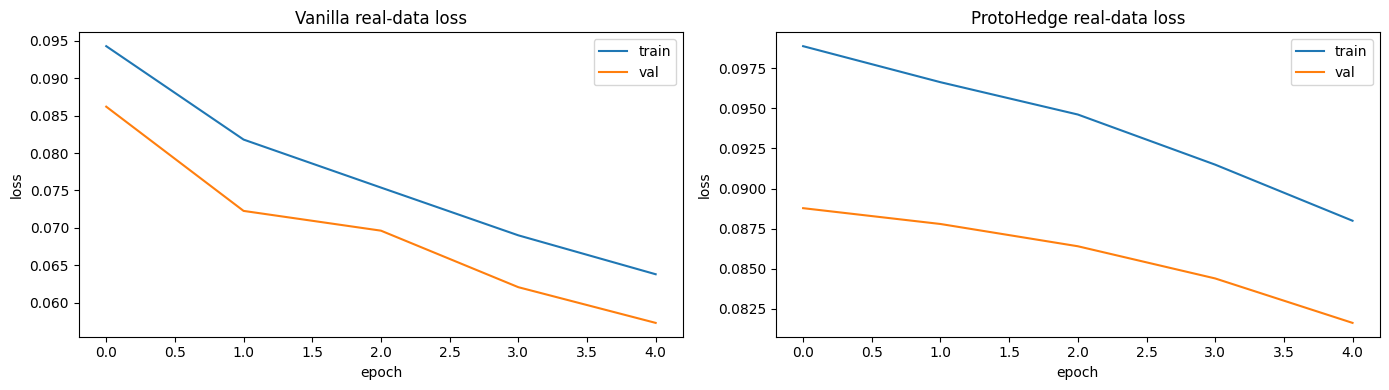

In [118]:
def plot_history(ax, history, title):
    losses = history["losses"]
    ax.plot(losses["training"], label="train")
    ax.plot(losses["val"], label="val")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_history(axes[0], results_real_vanilla["history"], "Vanilla real-data loss")
plot_history(axes[1], results_real_proto["history"], "ProtoHedge real-data loss")
plt.tight_layout()
plt.show()

## 11. Holdout Performance Plots

The core comparison is unhedged payoff vs vanilla gains vs ProtoHedge gains on held-out paths.

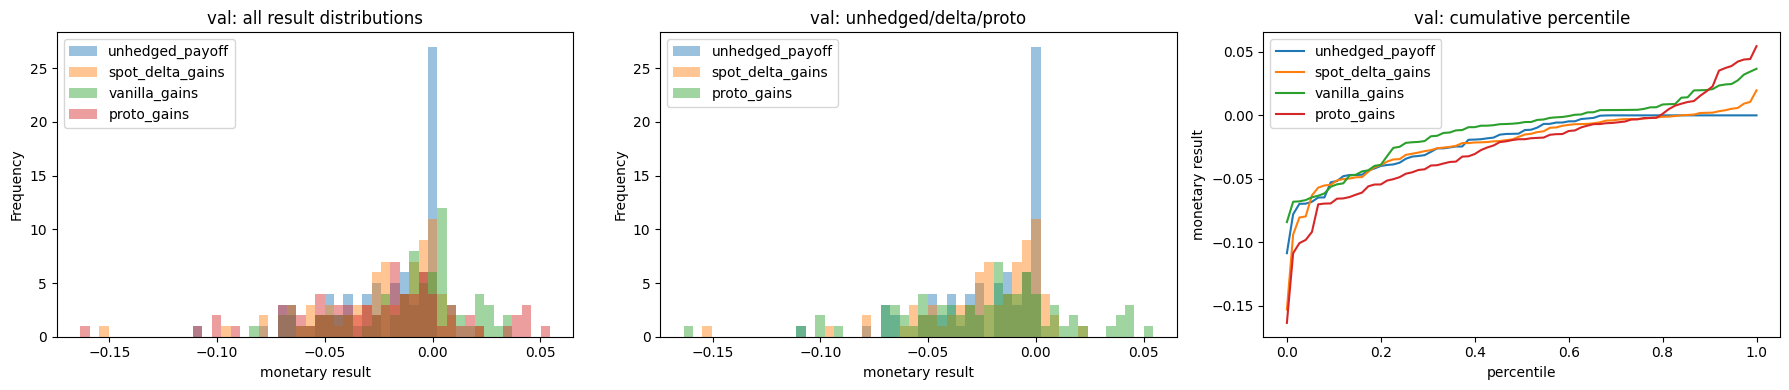

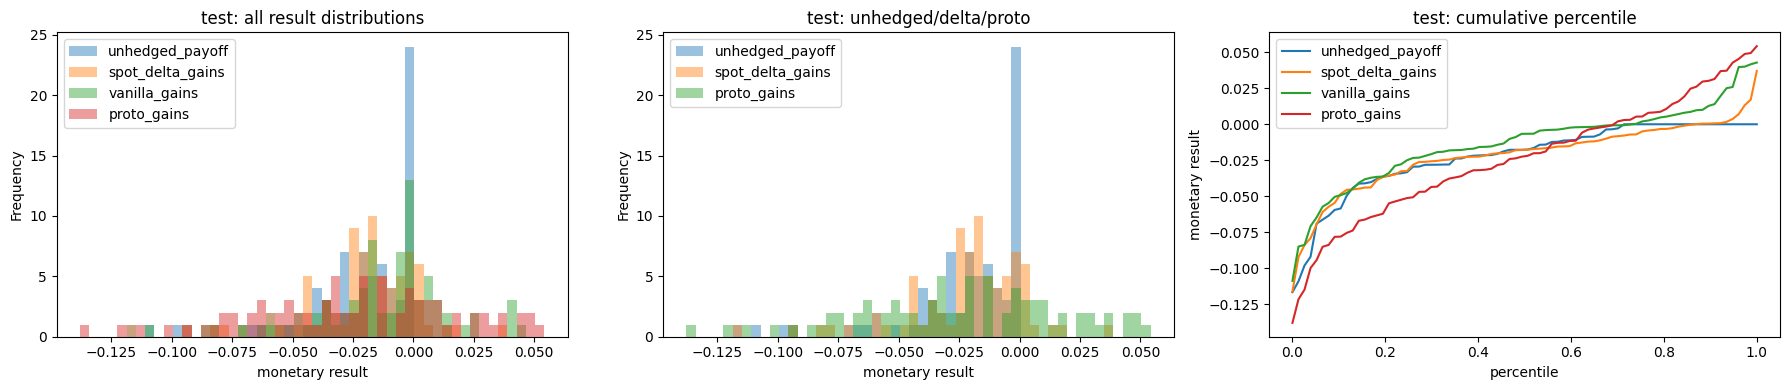

In [119]:
def split_gains_frame(split_name="test"):
    frame = pd.DataFrame()
    for model_name in ["unhedged", "spot_delta", "vanilla", "proto"]:
        result = eval_artifacts[model_name][split_name]["result"]
        label = "unhedged_payoff" if model_name == "unhedged" else f"{model_name}_gains"
        frame[label] = as_numpy(result["gains"]).reshape(-1)
    return frame

for split_name in ["val", "test"]:
    gdf = split_gains_frame(split_name)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # All models together.
    gdf.plot(kind="hist", bins=50, alpha=0.45, ax=axes[0])
    axes[0].set_title(f"{split_name}: all result distributions")
    axes[0].set_xlabel("monetary result")

    # Exclude vanilla if it dominates scale; this keeps ProtoHedge visible.
    non_vanilla_cols = [c for c in gdf.columns if c != "vanilla_gains"]
    gdf[non_vanilla_cols].plot(kind="hist", bins=50, alpha=0.45, ax=axes[1])
    axes[1].set_title(f"{split_name}: unhedged/delta/proto")
    axes[1].set_xlabel("monetary result")

    for col in gdf.columns:
        x = np.sort(gdf[col].values)
        y = np.linspace(0, 1, len(x))
        axes[2].plot(y, x, label=col)
    axes[2].set_title(f"{split_name}: cumulative percentile")
    axes[2].set_xlabel("percentile")
    axes[2].set_ylabel("monetary result")
    axes[2].legend()
    plt.tight_layout()
    plt.show()

In [120]:
def tail_table(split_name="test", alpha=0.05):
    gdf = split_gains_frame(split_name)
    rows = []
    for col in gdf.columns:
        x = gdf[col].values
        var = np.quantile(x, alpha)
        cvar = x[x <= var].mean() if np.any(x <= var) else var
        rows.append({
            "series": col,
            "mean": x.mean(),
            "std": x.std(),
            f"VaR_{alpha:.0%}": var,
            f"CVaR_{alpha:.0%}": cvar,
            "median": np.median(x),
        })
    return pd.DataFrame(rows)

display(tail_table("test", alpha=0.05))

,series,mean,std,VaR_5%,CVaR_5%,median
0,unhedged_payoff,-0.022705,0.026112,-0.072427,-0.103893,-0.017628
1,spot_delta_gains,-0.021947,0.024673,-0.070908,-0.092764,-0.017715
2,vanilla_gains,-0.013509,0.028217,-0.065600,-0.087028,-0.006626
3,proto_gains,-0.023650,0.042175,-0.095123,-0.118481,-0.022207


## 12. Prototype Table And Actions

The prototype vectors are stored in standardized feature space. We invert the scaler here so the table is interpretable.

Because `MODEL_FEATURES` is sorted internally, the 5 real-data prototype columns are:

`delta_spot`, `delta_ATM_call`, `price_spot`, `price_ATM_call`, `time_left`.

In [121]:
proto_scaled = np.asarray(prototype_payload["prototypes"])
proto_raw = prototype_payload["scaler"].inverse_transform(proto_scaled)
proto_actions = results_real_proto["model"].prototype_actions.detach().cpu().numpy()

proto_columns = ["delta_spot", "delta_ATM_call", "price_spot", "price_ATM_call", "time_left"]
action_columns = ["action_spot", "action_ATM_call"]

prototype_df = pd.DataFrame(proto_raw, columns=proto_columns)
prototype_df.insert(0, "prototype", np.arange(len(prototype_df)))
for j, col in enumerate(action_columns):
    prototype_df[col] = proto_actions[:, j]
prototype_df["action_norm"] = np.linalg.norm(proto_actions, axis=1)

display(prototype_df.sort_values("action_norm", ascending=False).head(15))
prototype_df.to_csv(OUTPUT_DIR / "prototype_table.csv", index=False)
print("saved:", OUTPUT_DIR / "prototype_table.csv")

,prototype,delta_spot,delta_ATM_call,price_spot,price_ATM_call,time_left,action_spot,action_ATM_call,action_norm
13,13,0.634993,0.387461,0.912091,0.340633,0.24,-0.107905,-0.146096,0.181625
14,14,0.318187,0.188231,1.012015,0.521032,0.32,-0.101730,-0.146569,0.178414
18,18,0.080150,0.047486,1.001568,0.202464,0.38,-0.136207,-0.114423,0.177891
19,19,1.000000,0.863597,1.013199,0.171775,0.06,-0.075945,-0.143577,0.162425
17,17,0.787753,0.455362,0.974773,0.643374,0.20,-0.126530,-0.099237,0.160804
8,8,0.080661,0.041678,0.997957,0.789803,0.38,-0.114831,-0.110246,0.159186
16,16,0.936059,0.581835,1.009463,0.526583,0.16,-0.138375,-0.074068,0.156951
7,7,0.784492,0.471085,1.028400,0.809394,0.20,-0.143395,-0.053651,0.153103
11,11,0.477799,0.262993,1.000308,0.830654,0.28,-0.083122,-0.126144,0.151069
23,23,1.000000,0.765797,0.950323,0.262727,0.08,-0.107324,-0.106172,0.150967


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_robust_diagnostics/prototype_table.csv


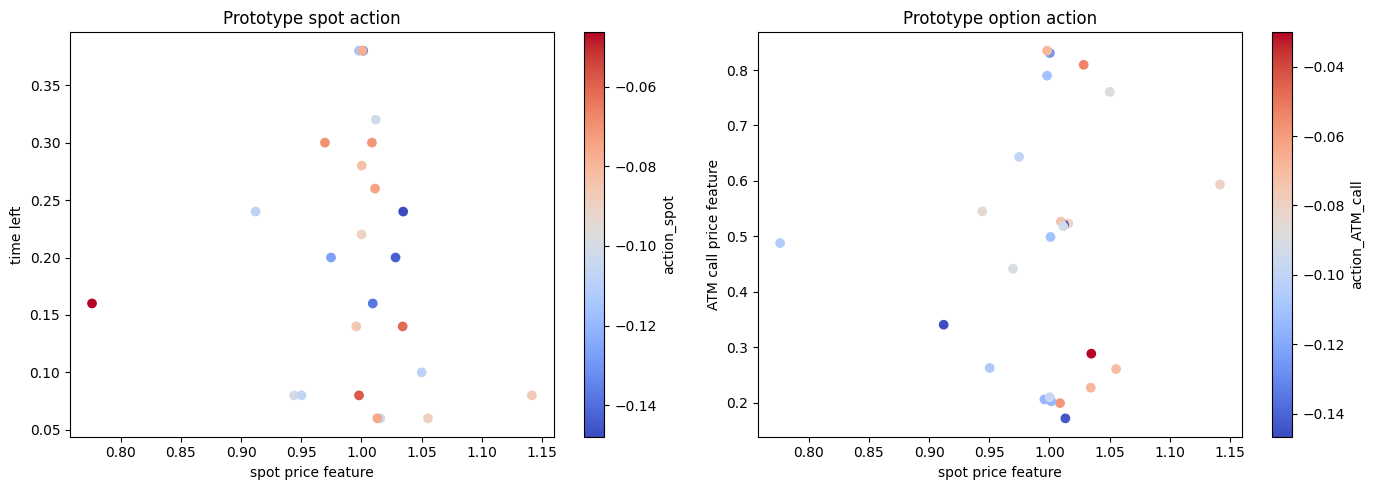

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc0 = axes[0].scatter(
    prototype_df["price_spot"],
    prototype_df["time_left"],
    c=prototype_df["action_spot"],
    cmap="coolwarm",
)
axes[0].set_title("Prototype spot action")
axes[0].set_xlabel("spot price feature")
axes[0].set_ylabel("time left")
plt.colorbar(sc0, ax=axes[0], label="action_spot")

sc1 = axes[1].scatter(
    prototype_df["price_spot"],
    prototype_df["price_ATM_call"],
    c=prototype_df["action_ATM_call"],
    cmap="coolwarm",
)
axes[1].set_title("Prototype option action")
axes[1].set_xlabel("spot price feature")
axes[1].set_ylabel("ATM call price feature")
plt.colorbar(sc1, ax=axes[1], label="action_ATM_call")
plt.tight_layout()
plt.show()

## 13. Prototype Usage On Held-Out Test Paths

If the model is interpretable, prototype usage should not be random noise. The top-used prototypes should map to sensible states and actions.

In [123]:
proto_test_result = eval_artifacts["proto"]["test"]["result"]
weights = as_numpy(proto_test_result.get("prototype_weights"))
assert weights is not None, "Expected prototype_weights from return_paths=True"

# weights shape: [paths, steps, prototypes]
avg_usage = weights.mean(axis=(0, 1))
time_usage = weights.mean(axis=0)

usage_df = pd.DataFrame({
    "prototype": np.arange(len(avg_usage)),
    "avg_usage": avg_usage,
}).merge(prototype_df, on="prototype")

display(usage_df.sort_values("avg_usage", ascending=False).head(15))
usage_df.to_csv(OUTPUT_DIR / "prototype_usage_test.csv", index=False)
print("saved:", OUTPUT_DIR / "prototype_usage_test.csv")

,prototype,avg_usage,delta_spot,delta_ATM_call,price_spot,price_ATM_call,time_left,action_spot,action_ATM_call,action_norm
23,23,0.170366,1.000000,0.765797,0.950323,0.262727,0.08,-0.107324,-0.106172,0.150967
6,6,0.166836,1.000000,0.787323,0.944052,0.545193,0.08,-0.100100,-0.085569,0.131689
19,19,0.115442,1.000000,0.863597,1.013199,0.171775,0.06,-0.075945,-0.143577,0.162425
2,2,0.092582,1.000000,0.819251,1.015660,0.523367,0.06,-0.103309,-0.081403,0.131527
21,21,0.086711,1.000000,0.776101,0.998041,0.834816,0.08,-0.057782,-0.068572,0.089671
9,9,0.067091,1.000000,0.627329,0.995762,0.205855,0.14,-0.085379,-0.114485,0.142816
5,5,0.051738,1.000000,0.823495,1.055348,0.260689,0.06,-0.089321,-0.070197,0.113603
4,4,0.030781,1.000000,0.727382,1.050120,0.760619,0.10,-0.108490,-0.087593,0.139437
13,13,0.029657,0.634993,0.387461,0.912091,0.340633,0.24,-0.107905,-0.146096,0.181625
18,18,0.022275,0.080150,0.047486,1.001568,0.202464,0.38,-0.136207,-0.114423,0.177891


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_robust_diagnostics/prototype_usage_test.csv


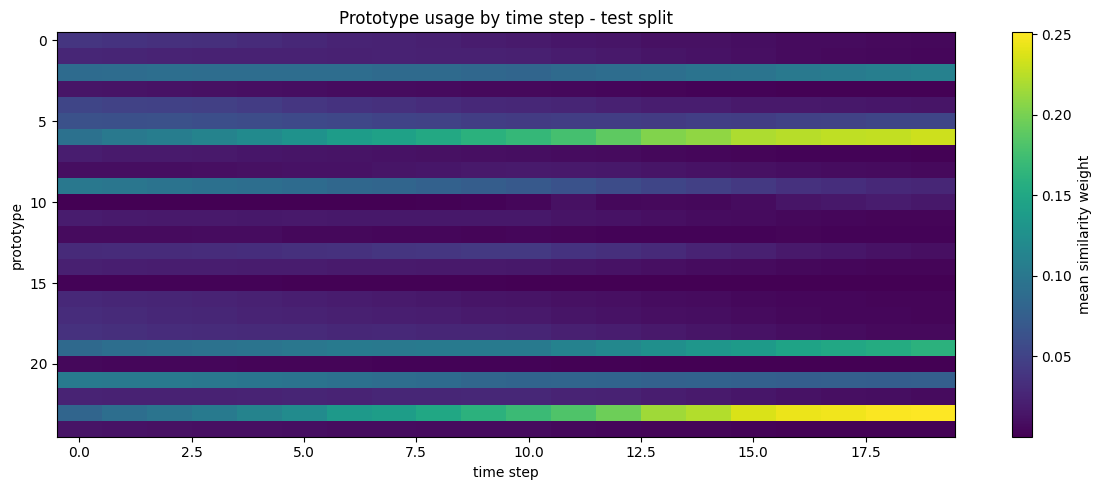

In [124]:
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(time_usage.T, aspect="auto", interpolation="nearest", cmap="viridis")
ax.set_title("Prototype usage by time step - test split")
ax.set_xlabel("time step")
ax.set_ylabel("prototype")
plt.colorbar(im, ax=ax, label="mean similarity weight")
plt.tight_layout()
plt.show()

## 14. Regime Analysis

This is a first version of the paper's robustness request. We bucket test episodes by terminal spot return and average implied volatility, then compare gains within each regime.

Later, if the raw WRDS dates are preserved in the episode metadata, we should replace these rough buckets with calendar regimes such as COVID crash, high-rate periods, earnings weeks, flash-crash windows, etc.

In [125]:
def test_regime_frame():
    world = eval_artifacts["proto"]["test"]["world"]
    spot = np.asarray(world.data.features.per_step["spot"])
    ivol = np.asarray(world.data.features.per_step["ivol"])
    terminal_return = spot[:, -1] / spot[:, 0] - 1.0
    avg_ivol = ivol.mean(axis=1)

    frame = split_gains_frame("test")
    frame["terminal_return"] = terminal_return
    frame["avg_ivol"] = avg_ivol
    frame["return_regime"] = pd.qcut(
        frame["terminal_return"],
        q=3,
        labels=["down", "middle", "up"],
        duplicates="drop",
    )
    frame["vol_regime"] = pd.qcut(
        frame["avg_ivol"],
        q=3,
        labels=["low_vol", "mid_vol", "high_vol"],
        duplicates="drop",
    )
    return frame

regime_df = test_regime_frame()
display(regime_df.head())

,unhedged_payoff,spot_delta_gains,vanilla_gains,proto_gains,terminal_return,avg_ivol,return_regime,vol_regime
0,-0.029367,-0.023445,-0.028827,0.037176,0.029367,0.683026,up,mid_vol
1,-0.000000,-0.003227,-0.000153,0.045367,-0.025369,0.675772,down,mid_vol
2,-0.000000,0.017122,-0.001788,0.008667,-0.136896,0.619289,down,low_vol
3,-0.041214,-0.045524,-0.036287,-0.036025,0.041214,0.367617,up,low_vol
4,-0.007030,0.000122,-0.014218,-0.000709,0.007030,0.465050,middle,low_vol


In [126]:
def summarize_by_regime(frame, regime_col):
    result_cols = [c for c in frame.columns if c.endswith("_gains") or c == "unhedged_payoff"]
    rows = []
    for regime, grp in frame.groupby(regime_col, observed=True):
        for col in result_cols:
            x = grp[col].values
            rows.append({
                "regime_type": regime_col,
                "regime": regime,
                "series": col,
                "n": len(x),
                "mean": x.mean(),
                "p05": np.quantile(x, 0.05),
                "median": np.median(x),
                "p95": np.quantile(x, 0.95),
            })
    return pd.DataFrame(rows)

return_regime_summary = summarize_by_regime(regime_df, "return_regime")
vol_regime_summary = summarize_by_regime(regime_df, "vol_regime")
regime_summary = pd.concat([return_regime_summary, vol_regime_summary], ignore_index=True)
regime_summary.to_csv(OUTPUT_DIR / "regime_summary_test.csv", index=False)
display(regime_summary)
print("saved:", OUTPUT_DIR / "regime_summary_test.csv")

,regime_type,regime,series,n,mean,p05,median,p95
0,return_regime,down,unhedged_payoff,26,-0.000382,-0.003314,0.000000,-0.000000
1,return_regime,down,spot_delta_gains,26,-0.002077,-0.016963,-0.002967,0.016141
2,return_regime,down,vanilla_gains,26,0.005322,-0.008343,-0.000696,0.041218
3,return_regime,down,proto_gains,26,0.007363,-0.043080,0.006657,0.047935
4,return_regime,middle,unhedged_payoff,26,-0.016529,-0.023781,-0.017628,-0.008599
5,return_regime,middle,spot_delta_gains,26,-0.016790,-0.026164,-0.017056,-0.000894
6,return_regime,middle,vanilla_gains,26,-0.006086,-0.023016,-0.011771,0.023712
7,return_regime,middle,proto_gains,26,-0.024379,-0.062971,-0.027911,0.023116
8,return_regime,up,unhedged_payoff,26,-0.051204,-0.106279,-0.040594,-0.028088
9,return_regime,up,spot_delta_gains,26,-0.046975,-0.090078,-0.043901,-0.018544


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_robust_diagnostics/regime_summary_test.csv


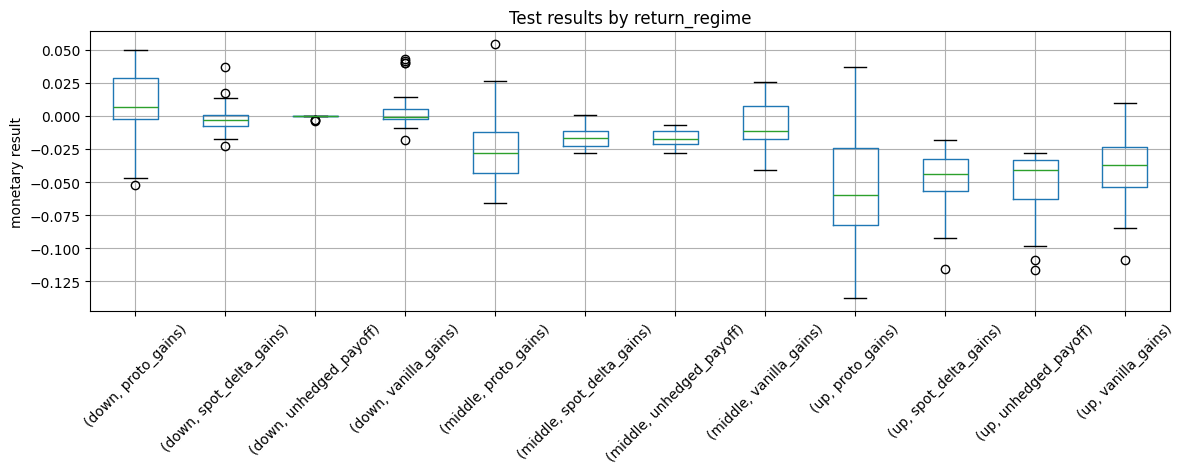

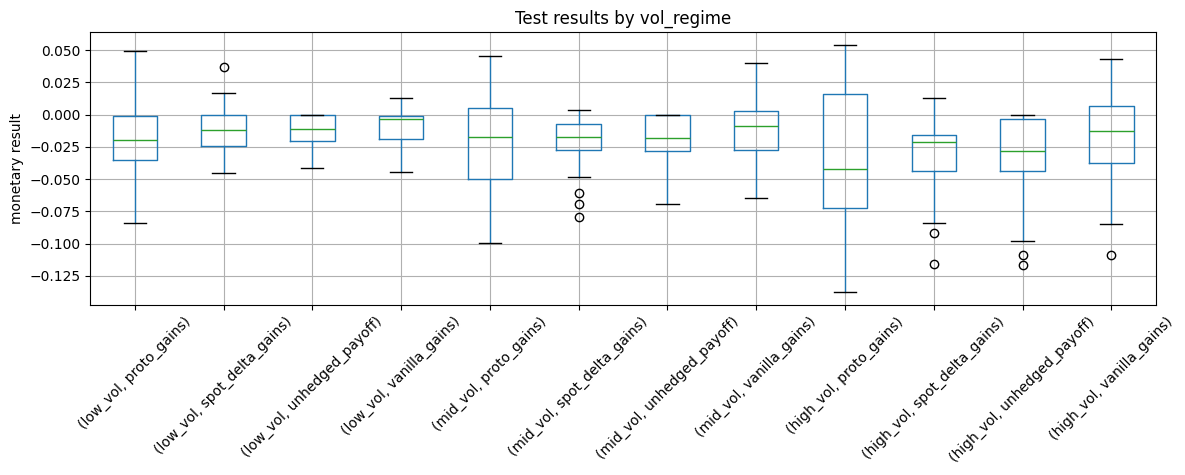

In [127]:
for regime_col in ["return_regime", "vol_regime"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    result_cols = [c for c in regime_df.columns if c.endswith("_gains") or c == "unhedged_payoff"]
    plot_df = regime_df.melt(
        id_vars=[regime_col],
        value_vars=result_cols,
        var_name="series",
        value_name="result",
    )
    plot_df.boxplot(column="result", by=[regime_col, "series"], ax=ax, rot=45)
    ax.set_title(f"Test results by {regime_col}")
    ax.set_xlabel("")
    ax.set_ylabel("monetary result")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

## 15. Current Baselines And Next Baselines

This notebook now compares:

- `unhedged_payoff`: no hedge.
- `spot_delta_gains`: a simple empirical spot-delta hedge using the dataset's `call_delta` feature.
- `vanilla_gains`: vanilla neural Deep Hedging.
- `proto_gains`: prototype-based Deep Hedging.

The spot-delta baseline is intentionally simple and transparent. It does not use the option hedge instrument yet; it only targets a spot position near the empirical call delta for a short call. That makes it a useful sanity baseline before adding richer classical baselines.

A later extension should add:

- a spot-plus-option delta/vega hedge,
- transaction-cost-aware delta rebalancing bands,
- buy-and-hold option hedge baselines,
- walk-forward retraining instead of one random split.

## 16. Decision Gate Before Larger Real-Data Experiments

Use this checklist after each run:

- Did both neural models train without NaNs?
- Did validation/test metrics remain finite?
- Are we using the original real-data semantics, i.e. `HEDGE_MODE = "step"`?
- Are normalized payoff/gains on a plausible scale?
- Are cumulative positions inside the configured bounds?
- Does ProtoHedge improve over unhedged on test tail metrics?
- Is ProtoHedge competitive with vanilla Deep Hedging and the spot-delta baseline under the same market constraints?
- Are prototype actions within plausible ranges, not all saturated at bounds?
- Do the new robustness diagnostics show acceptable bound occupancy rather than strategies living on the rails?
- Are top-used prototypes interpretable in raw feature space?
- Does performance remain reasonable in down-market and high-volatility regimes?
- Are results stable if you rerun with a different seed or prototype count?

If the answer is yes, then we are ready to scale this notebook to more paths, more seeds, and eventually more tickers / markets / option types.

## 17. Suggested Next Runs

The next run should be the focused robust empirical sweep:

- all available real-data paths,
- one-step hedge increments, matching the original TensorFlow `world_real.py`,
- 800 epochs,
- tighter trade and cumulative position bounds,
- validation-based checkpoint selection,
- mild action / delta regularization,
- one seed first,
- prototype counts `[10, 25, 50, 100]`,
- prototype sources `spot_delta` and `vanilla`,
- weighted and unweighted prototype similarity.

If that run still produces acceptable mean performance without heavy bound dependence, then the next step is the same robust grid across multiple seeds.

## 18. Automated Interpretation Diagnostics

This section turns the tables above into explicit diagnostics. It checks four things that matter for the empirical ProtoHedge story:

- **Performance:** mean, downside tail, and utility relative to unhedged, spot-delta, and vanilla.
- **Constraint behavior:** whether a model is trading by saturating the cumulative position bounds.
- **Selection behavior:** whether the chosen checkpoint is coming from a validation-based criterion rather than simply the final epoch.
- **Prototype behavior:** whether usage is concentrated and whether ProtoHedge actions are too small.

These diagnostics are not replacements for judgment, but they make the next experiment less subjective.

In [128]:
def make_test_comparison(metrics_df, split="test"):
    df = metrics_df[metrics_df["split"] == split].copy()
    cols = [
        "model", "gains_mean", "gains_p05", "gains_p50", "pnl_mean", "cost_mean",
        "action_abs_mean", "action_abs_max", "delta_abs_mean", "delta_abs_max", "utility_mean",
    ]
    cols = [c for c in cols if c in df.columns]
    out = df[cols].sort_values("gains_mean", ascending=False).reset_index(drop=True)

    base = df.set_index("model")
    if "proto" in base.index:
        proto_mean = base.loc["proto", "gains_mean"]
        proto_p05 = base.loc["proto", "gains_p05"]
        for model_name in ["unhedged", "spot_delta", "vanilla"]:
            if model_name in base.index:
                out[f"proto_mean_minus_{model_name}"] = proto_mean - base.loc[model_name, "gains_mean"]
                out[f"proto_p05_minus_{model_name}"] = proto_p05 - base.loc[model_name, "gains_p05"]
    return out

comparison_test = make_test_comparison(metrics_df, "test")
display(comparison_test)

,model,gains_mean,gains_p05,gains_p50,pnl_mean,cost_mean,action_abs_mean,action_abs_max,delta_abs_mean,delta_abs_max,utility_mean,proto_mean_minus_unhedged,proto_p05_minus_unhedged,proto_mean_minus_spot_delta,proto_p05_minus_spot_delta,proto_mean_minus_vanilla,proto_p05_minus_vanilla
0,vanilla,-0.013509,-0.065600,-0.006626,0.009889,0.000693,0.049927,0.079569,0.614781,1.000000,-0.034596,-0.000945,-0.022695,-0.001703,-0.024214,-0.01014,-0.029522
1,spot_delta,-0.021947,-0.070908,-0.017715,0.000984,0.000227,0.028340,0.999861,0.495822,0.999988,NaN,-0.000945,-0.022695,-0.001703,-0.024214,-0.01014,-0.029522
2,unhedged,-0.022705,-0.072427,-0.017628,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,-0.000945,-0.022695,-0.001703,-0.024214,-0.01014,-0.029522
3,proto,-0.023650,-0.095123,-0.022207,-0.000249,0.000696,0.050000,0.105139,0.762637,1.000000,-0.058593,-0.000945,-0.022695,-0.001703,-0.024214,-0.01014,-0.029522


In [129]:
def position_saturation_table(split_name="test", tol=1e-4):
    rows = []
    max_occ = ROBUST_SCREEN_CFG.get("max_bound_occupancy")
    max_touch = ROBUST_SCREEN_CFG.get("max_path_touch_rate")
    for model_name in ["spot_delta", "vanilla", "proto"]:
        if model_name not in eval_artifacts or split_name not in eval_artifacts[model_name]:
            continue
        world = eval_artifacts[model_name][split_name]["world"]
        result = eval_artifacts[model_name][split_name]["result"]
        if "deltas" not in result:
            continue
        deltas = as_numpy(result["deltas"])
        if "ubnd_delta" in world.data.market and "lbnd_delta" in world.data.market:
            ub = np.asarray(world.data.market.ubnd_delta)
            lb = np.asarray(world.data.market.lbnd_delta)
            near_upper = np.isclose(deltas, ub, atol=tol, rtol=0.0)
            near_lower = np.isclose(deltas, lb, atol=tol, rtol=0.0)
            near_bound = near_upper | near_lower
        else:
            near_upper = near_lower = near_bound = np.zeros_like(deltas, dtype=bool)

        row = {
            "model": model_name,
            "split": split_name,
            "delta_abs_mean": float(np.mean(np.abs(deltas))),
            "delta_abs_max": float(np.max(np.abs(deltas))),
            "pct_at_any_position_bound": float(np.mean(near_bound)),
            "pct_at_upper_position_bound": float(np.mean(near_upper)),
            "pct_at_lower_position_bound": float(np.mean(near_lower)),
            "pct_paths_touch_any_position_bound": float(np.mean(np.any(near_bound, axis=(1, 2)))),
        }
        row["passes_bound_occupancy_screen"] = True if max_occ is None else row["pct_at_any_position_bound"] <= max_occ
        row["passes_path_touch_screen"] = True if max_touch is None else row["pct_paths_touch_any_position_bound"] <= max_touch
        row["passes_robust_screen"] = row["passes_bound_occupancy_screen"] and row["passes_path_touch_screen"]
        rows.append(row)
    return pd.DataFrame(rows)

saturation_test = position_saturation_table("test")
display(saturation_test)
saturation_test.to_csv(OUTPUT_DIR / "position_saturation_test.csv", index=False)
print("saved:", OUTPUT_DIR / "position_saturation_test.csv")

,model,split,delta_abs_mean,delta_abs_max,pct_at_any_position_bound,pct_at_upper_position_bound,pct_at_lower_position_bound,pct_paths_touch_any_position_bound,passes_bound_occupancy_screen,passes_path_touch_screen,passes_robust_screen
0,spot_delta,test,0.495822,0.999988,0.008013,0.008013,0.000000,0.24359,True,True,True
1,vanilla,test,0.614781,1.000000,0.206410,0.206410,0.000000,1.00000,True,True,True
2,proto,test,0.762637,1.000000,0.503205,0.000000,0.503205,1.00000,False,True,False


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_robust_diagnostics/position_saturation_test.csv


In [130]:
def prototype_usage_diagnostics(usage_df):
    usage = usage_df["avg_usage"].to_numpy(dtype=float)
    usage = usage / max(usage.sum(), 1e-12)
    entropy = -np.sum(np.where(usage > 0, usage * np.log(usage), 0.0))
    effective_n = float(np.exp(entropy))
    top = np.sort(usage)[::-1]
    return pd.DataFrame([{
        "n_prototypes": len(usage),
        "top1_usage": float(top[:1].sum()),
        "top3_usage": float(top[:3].sum()),
        "top5_usage": float(top[:5].sum()),
        "entropy": float(entropy),
        "effective_n_prototypes": effective_n,
        "action_norm_mean": float(usage_df["action_norm"].mean()),
        "action_norm_max": float(usage_df["action_norm"].max()),
    }])

usage_diagnostics = prototype_usage_diagnostics(usage_df)
display(usage_diagnostics)
usage_diagnostics.to_csv(OUTPUT_DIR / "prototype_usage_diagnostics.csv", index=False)
print("saved:", OUTPUT_DIR / "prototype_usage_diagnostics.csv")

,n_prototypes,top1_usage,top3_usage,top5_usage,entropy,effective_n_prototypes,action_norm_mean,action_norm_max
0,25,0.170366,0.452643,0.631936,2.632473,13.908128,0.137978,0.181625


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/notebook_real_data_robust_diagnostics/prototype_usage_diagnostics.csv


In [131]:
def print_real_data_interpretation(metrics_df, saturation_df=None):
    test = metrics_df[metrics_df["split"] == "test"].set_index("model")
    lines = []
    lines.append("Current robust real-data interpretation:")
    if {"unhedged", "spot_delta", "vanilla", "proto"}.issubset(test.index):
        proto_mean = test.loc["proto", "gains_mean"]
        proto_tail = test.loc["proto", "gains_p05"]
        lines.append(f"- Proto mean gains: {proto_mean:.6f}")
        lines.append(f"- Proto 5% gains tail: {proto_tail:.6f}")
        lines.append(f"- Proto minus unhedged mean: {proto_mean - test.loc['unhedged', 'gains_mean']:.6f}")
        lines.append(f"- Proto minus spot-delta mean: {proto_mean - test.loc['spot_delta', 'gains_mean']:.6f}")
        lines.append(f"- Proto minus vanilla mean: {proto_mean - test.loc['vanilla', 'gains_mean']:.6f}")
        lines.append(f"- Proto 5% tail minus unhedged: {proto_tail - test.loc['unhedged', 'gains_p05']:.6f}")
        lines.append(f"- Proto 5% tail minus spot-delta: {proto_tail - test.loc['spot_delta', 'gains_p05']:.6f}")
        lines.append(f"- Proto 5% tail minus vanilla: {proto_tail - test.loc['vanilla', 'gains_p05']:.6f}")
    if saturation_df is not None and not saturation_df.empty:
        lines.append(f"- Robust bound-occupancy threshold: {ROBUST_SCREEN_CFG['max_bound_occupancy']}")
        for model_name in ["vanilla", "proto"]:
            rows = saturation_df[saturation_df["model"] == model_name]
            if rows.empty:
                continue
            row = rows.iloc[0]
            lines.append(
                f"- {model_name} bound occupancy: {row['pct_at_any_position_bound']:.6f} | "
                f"path touch rate: {row['pct_paths_touch_any_position_bound']:.6f} | "
                f"passes robust screen: {bool(row['passes_robust_screen'])}"
            )
    print("\n".join(lines))

print_real_data_interpretation(metrics_df, saturation_test)

Current robust real-data interpretation:
- Proto mean gains: -0.023650
- Proto 5% gains tail: -0.095123
- Proto minus unhedged mean: -0.000945
- Proto minus spot-delta mean: -0.001703
- Proto minus vanilla mean: -0.010140
- Proto 5% tail minus unhedged: -0.022695
- Proto 5% tail minus spot-delta: -0.024214
- Proto 5% tail minus vanilla: -0.029522
- Robust bound-occupancy threshold: 0.5
- vanilla bound occupancy: 0.206410 | path touch rate: 1.000000 | passes robust screen: True
- proto bound occupancy: 0.503205 | path touch rate: 1.000000 | passes robust screen: False


## 19. Prototype Source Sensitivity

The current ProtoHedge payload is extracted from the vanilla model's training trajectories. That is faithful to the current workflow, but the diagnostics show many train states have `delta_spot` near the cumulative position bound. That can make the prototype space reflect a saturated vanilla policy rather than a broad set of empirical market states.

This optional section tests whether ProtoHedge improves when prototypes are extracted from different state distributions:

- `vanilla_source`: current/default behavior.
- `spot_delta_source`: prototype states from the transparent empirical spot-delta hedge.
- `zero_market_source`: market states with zero pre-existing hedge position.

Leave `RUN_PROTO_SOURCE_SENSITIVITY = False` for ordinary notebook runs. Turn it on when you want the next experiment.

In [132]:
RUN_PROTO_SOURCE_SENSITIVITY = False
PROTO_SOURCE_VARIANTS = ["spot_delta_source", "zero_market_source"]
PROTO_SOURCE_EPOCHS = EPOCHS
PROTO_SOURCE_N_PROTOTYPES = N_PROTOTYPES


def train_and_evaluate_proto_variant(variant_name, source_result, n_prototypes=PROTO_SOURCE_N_PROTOTYPES, epochs=PROTO_SOURCE_EPOCHS):
    variant_dir = OUTPUT_DIR / "proto_source_sensitivity"
    variant_dir.mkdir(parents=True, exist_ok=True)
    variant_path = variant_dir / f"{variant_name}_prototypes_{n_prototypes}.pkl"

    payload = build_prototype_payload(
        world=results_real_vanilla["world"],
        result=source_result,
        n_prototypes=n_prototypes,
        feature_names=MODEL_FEATURES,
        random_state=SEED,
        max_points=MAX_POINTS,
    )
    save_prototype_payload(payload, variant_path)

    result = run_experiment(
        override_world=world_cfg(splits["train"], val_indices=splits["val"]),
        override_model=proto_model_cfg(variant_path),
        override_objective=objective_cfg(),
        override_training=training_cfg(epochs),
    )

    artifacts = {}
    variant_metrics = {}
    for split_name, idx in splits.items():
        w, r, m = evaluate_gym(result["gym"], idx, f"{variant_name} {split_name}")
        artifacts[split_name] = {"world": w, "result": r}
        variant_metrics[split_name] = m

    proto_raw = payload["scaler"].inverse_transform(np.asarray(payload["prototypes"]))
    proto_actions = result["model"].prototype_actions.detach().cpu().numpy()
    proto_df = pd.DataFrame(proto_raw, columns=proto_columns)
    proto_df.insert(0, "prototype", np.arange(len(proto_df)))
    for j, col in enumerate(action_columns):
        proto_df[col] = proto_actions[:, j]
    proto_df["action_norm"] = np.linalg.norm(proto_actions, axis=1)
    proto_df.to_csv(variant_dir / f"{variant_name}_prototype_table.csv", index=False)

    return {
        "name": variant_name,
        "prototype_path": variant_path,
        "payload": payload,
        "training": result,
        "artifacts": artifacts,
        "metrics": variant_metrics,
        "prototype_table": proto_df,
    }


def run_proto_source_sensitivity():
    source_results = {
        "spot_delta_source": eval_artifacts["spot_delta"]["train"]["result"],
        "zero_market_source": None,
    }
    variant_results = {}
    variant_metric_rows = []

    for variant_name in PROTO_SOURCE_VARIANTS:
        print(f"\n=== Running {variant_name} ===")
        variant = train_and_evaluate_proto_variant(
            variant_name=variant_name,
            source_result=source_results[variant_name],
            n_prototypes=PROTO_SOURCE_N_PROTOTYPES,
            epochs=PROTO_SOURCE_EPOCHS,
        )
        variant_results[variant_name] = variant
        for split_name, values in variant["metrics"].items():
            row = {"model": variant_name, "split": split_name}
            row.update({k: v for k, v in values.items() if not isinstance(v, list)})
            variant_metric_rows.append(row)

    variant_metrics_df = pd.DataFrame(variant_metric_rows)
    variant_metrics_df.to_csv(OUTPUT_DIR / "proto_source_sensitivity_metrics.csv", index=False)
    print("saved:", OUTPUT_DIR / "proto_source_sensitivity_metrics.csv")
    return variant_results, variant_metrics_df

if RUN_PROTO_SOURCE_SENSITIVITY:
    proto_source_results, proto_source_metrics_df = run_proto_source_sensitivity()
    display(proto_source_metrics_df[proto_source_metrics_df["split"] == "test"].sort_values("gains_mean", ascending=False))
else:
    print("Prototype source sensitivity is ready. Set RUN_PROTO_SOURCE_SENSITIVITY = True and rerun this cell when you want the next experiment.")

Prototype source sensitivity is ready. Set RUN_PROTO_SOURCE_SENSITIVITY = True and rerun this cell when you want the next experiment.


## 20. Recommended Experiment Queue

Based on the current pipeline, the next question is not whether ProtoHedge runs. It does. The next question is whether ProtoHedge stays competitive once we test it under stricter and more defensible empirical conditions.

Run the queue in this order:

1. Use `focused_robust_original_epochs` in the sweep section below: full data, step-mode hedge increments, tighter bounds, validation-based checkpoint selection, mild regularization, one seed, prototype counts `[10, 25, 50, 100]`, sources `spot_delta` and `vanilla`.
2. Read the generated `paper_best_models.csv`, `paper_model_comparison.csv`, the robustness-screen columns, and the plots before launching anything larger.
3. If ProtoHedge remains competitive on mean / CVaR / shortfall and passes the robustness screen, run `paper_robust_original_epochs` for the same grid across three seeds.
4. If the robust run still fails on bound occupancy, tighten the environment further or increase the regularization slightly and rerun the same focused grid.
5. If ProtoHedge is stable across seeds, move from one dataset to multiple tickers / markets and then path-dependent options.

The paper-level claim we are moving toward is: ProtoHedge can remain competitive with strong hedging baselines on historical data while exposing a compact set of interpretable prototype states, without relying on pathological boundary-seeking behavior.

## 21. Real-Data Sweep: ProtoHedge vs Baselines

This is now the main paper-phase empirical grid. The immediate goal is no longer a single-seed pilot; it is to test whether the ProtoHedge frontier remains stable across multiple seeds under the tighter real-data constraints.

The sweep uses three robustness controls:

- tighter trade and cumulative position bounds,
- validation-based checkpoint selection,
- mild action / delta regularization.

Presets:

- `focused_original_epochs_reference`: old full-data step-mode reference without the new robustness controls.
- `focused_robust_original_epochs`: single-seed robust full-data sweep.
- `paper_robust_original_epochs`: multi-seed robust paper sweep.

`Run All` is now configured for the multi-seed robust preset. The helper checkpoints metrics, paper tables, plots, splits, and reloadable trained-model artifacts after every completed model.


In [133]:
import importlib
import deephedging.real_data_sweep_torch as real_data_sweep_torch
real_data_sweep_torch = importlib.reload(real_data_sweep_torch)

RUN_REAL_DATA_SWEEP = True
SWEEP_PRESET = "paper_robust_original_epochs"  # "focused_original_epochs_reference", "focused_robust_original_epochs", or "paper_robust_original_epochs"
FULL_RUN_EPOCHS = 800
FULL_RUN_EPOCH_REFRESH = 50
ANALYSIS_FRONTIER_TOL_PCT = 0.02
SPOT_DELTA_BAND_GRID = [0.0, 0.01, 0.02, 0.05, 0.10, 0.15]
TUNED_BASELINE_METRIC = "gains_mean"

REFERENCE_SELECTION_CFG = {
    "selection_metric": "train_loss",
    "selection_alpha_action_abs": 0.0,
    "selection_alpha_delta_abs": 0.0,
    "selection_alpha_bound_occupancy": 0.0,
    "selection_alpha_path_bound_touch": 0.0,
}
REFERENCE_REG_CFG = {
    "action_penalty_weight": 0.0,
    "delta_penalty_weight": 0.0,
}
REFERENCE_SCREEN_CFG = {
    "max_bound_occupancy": None,
    "max_path_touch_rate": None,
}

SWEEP_PRESETS = {
    "focused_original_epochs_reference": {
        "output_dir": REPO_ROOT / ".deephedging_real_runs" / "real_data_sweep_focused_800_step_reference",
        "samples": None,
        "epochs": FULL_RUN_EPOCHS,
        "epoch_refresh": FULL_RUN_EPOCH_REFRESH,
        "seeds": [1234],
        "prototype_counts": [10, 25, 50, 100],
        "prototype_sources": ["spot_delta", "vanilla"],
        "weighted_options": [True, False],
        "learn_weight_options": [False],
        "risk_measures": ["cvar"],
        "trade_bounds": BASE_TRADE_BOUNDS,
        "position_bounds": BASE_POSITION_BOUNDS,
        "selection_cfg": REFERENCE_SELECTION_CFG,
        "reg_cfg": REFERENCE_REG_CFG,
        "robust_screen_cfg": REFERENCE_SCREEN_CFG,
        "max_points": MAX_POINTS,
        "spot_delta_band_grid": SPOT_DELTA_BAND_GRID,
        "tuned_baseline_metric": TUNED_BASELINE_METRIC,
    },
    "focused_robust_original_epochs": {
        "output_dir": REPO_ROOT / ".deephedging_real_runs" / "real_data_sweep_focused_800_step_robust",
        "samples": None,
        "epochs": FULL_RUN_EPOCHS,
        "epoch_refresh": FULL_RUN_EPOCH_REFRESH,
        "seeds": [1234],
        "prototype_counts": [10, 25, 50, 100],
        "prototype_sources": ["spot_delta", "vanilla"],
        "weighted_options": [True, False],
        "learn_weight_options": [False],
        "risk_measures": ["cvar"],
        "trade_bounds": TRADE_BOUNDS,
        "position_bounds": POSITION_BOUNDS,
        "selection_cfg": TRAIN_SELECTION_CFG,
        "reg_cfg": TRAIN_REG_CFG,
        "robust_screen_cfg": ROBUST_SCREEN_CFG,
        "max_points": MAX_POINTS,
        "spot_delta_band_grid": SPOT_DELTA_BAND_GRID,
        "tuned_baseline_metric": TUNED_BASELINE_METRIC,
    },
    "paper_robust_original_epochs": {
        "output_dir": REPO_ROOT / ".deephedging_real_runs" / "real_data_sweep_paper_800_step_robust",
        "samples": None,
        "epochs": FULL_RUN_EPOCHS,
        "epoch_refresh": FULL_RUN_EPOCH_REFRESH,
        "seeds": [1234, 2345, 3456],
        "prototype_counts": [10, 25, 50, 100],
        "prototype_sources": ["spot_delta", "vanilla"],
        "weighted_options": [True, False],
        "learn_weight_options": [False],
        "risk_measures": ["cvar"],
        "trade_bounds": TRADE_BOUNDS,
        "position_bounds": POSITION_BOUNDS,
        "selection_cfg": TRAIN_SELECTION_CFG,
        "reg_cfg": TRAIN_REG_CFG,
        "robust_screen_cfg": ROBUST_SCREEN_CFG,
        "max_points": MAX_POINTS,
        "spot_delta_band_grid": SPOT_DELTA_BAND_GRID,
        "tuned_baseline_metric": TUNED_BASELINE_METRIC,
    },
}

preset = SWEEP_PRESETS[SWEEP_PRESET]
SWEEP_OUTPUT_DIR = preset["output_dir"]

n_vanilla_runs = len(preset["seeds"]) * len(preset["risk_measures"])
n_proto_runs = (
    len(preset["seeds"])
    * len(preset["risk_measures"])
    * len(preset["prototype_counts"])
    * len(preset["prototype_sources"])
    * len(preset["weighted_options"])
    * len(preset["learn_weight_options"])
)

print("sweep preset:", SWEEP_PRESET)
print("output dir:", SWEEP_OUTPUT_DIR)
print("samples:", "all paths" if preset["samples"] is None else preset["samples"])
print("epochs per neural run:", preset["epochs"])
print("epoch_refresh:", preset["epoch_refresh"])
print("hedge_mode:", HEDGE_MODE)
print("trade_bounds:", preset["trade_bounds"])
print("position_bounds:", preset["position_bounds"])
print("selection_cfg:", preset["selection_cfg"])
print("regularization_cfg:", preset["reg_cfg"])
print("robust_screen_cfg:", preset["robust_screen_cfg"])
print("frontier tolerance vs vanilla mean:", ANALYSIS_FRONTIER_TOL_PCT)
print("seeds:", preset["seeds"])
print("prototype_counts:", preset["prototype_counts"])
print("prototype_sources:", preset["prototype_sources"])
print("weighted_options:", preset["weighted_options"])
print("neural training jobs:", n_vanilla_runs + n_proto_runs, f"({n_vanilla_runs} vanilla + {n_proto_runs} proto)")
print("checkpointing: after baselines, vanilla, and every ProtoHedge variant")
print("saved artifacts: reloadable trained models are written under", SWEEP_OUTPUT_DIR / "model_artifacts")

if RUN_REAL_DATA_SWEEP:
    sweep_metrics_df = real_data_sweep_torch.run_real_data_sweep(
        data_path=DATA_PATH,
        output_dir=SWEEP_OUTPUT_DIR,
        samples=preset["samples"],
        epochs=preset["epochs"],
        seeds=preset["seeds"],
        prototype_counts=preset["prototype_counts"],
        prototype_sources=preset["prototype_sources"],
        weighted_similarity_options=preset["weighted_options"],
        learn_distance_feature_weights_options=preset["learn_weight_options"],
        risk_measures=preset["risk_measures"],
        normalize=NORMALIZE_REAL_WORLD,
        hedge_mode=HEDGE_MODE,
        position_bounds=USE_POSITION_BOUNDS,
        trade_bounds=preset["trade_bounds"],
        cumulative_bounds=preset["position_bounds"],
        lr=LR,
        batch_size=BATCH_SIZE,
        epoch_refresh=preset["epoch_refresh"],
        selection_metric=preset["selection_cfg"]["selection_metric"],
        selection_alpha_action_abs=preset["selection_cfg"]["selection_alpha_action_abs"],
        selection_alpha_delta_abs=preset["selection_cfg"]["selection_alpha_delta_abs"],
        selection_alpha_bound_occupancy=preset["selection_cfg"]["selection_alpha_bound_occupancy"],
        selection_alpha_path_bound_touch=preset["selection_cfg"]["selection_alpha_path_bound_touch"],
        action_penalty_weight=preset["reg_cfg"]["action_penalty_weight"],
        delta_penalty_weight=preset["reg_cfg"]["delta_penalty_weight"],
        max_bound_occupancy=preset["robust_screen_cfg"]["max_bound_occupancy"],
        max_path_touch_rate=preset["robust_screen_cfg"]["max_path_touch_rate"],
        max_points=preset["max_points"],
        spot_delta_band_grid=tuple(preset["spot_delta_band_grid"]),
        tuned_baseline_metric=preset["tuned_baseline_metric"],
    )
else:
    metrics_path = SWEEP_OUTPUT_DIR / "sweep_metrics.csv"
    if metrics_path.exists():
        sweep_metrics_df = pd.read_csv(metrics_path)
        print("Loaded existing sweep metrics:", metrics_path)
    else:
        sweep_metrics_df = None
        print("Full sweep is configured but not launched. Set RUN_REAL_DATA_SWEEP = True when ready.")



sweep preset: paper_robust_original_epochs
output dir: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust
samples: all paths
epochs per neural run: 800
epoch_refresh: 50
hedge_mode: step
trade_bounds: {'lbnd_as': -1.0, 'ubnd_as': 1.0, 'lbnd_av': -1.0, 'ubnd_av': 1.0}
position_bounds: {'lbnd_delta_s': -1.0, 'ubnd_delta_s': 1.0, 'lbnd_delta_v': -1.0, 'ubnd_delta_v': 1.0}
selection_cfg: {'selection_metric': 'val_loss', 'selection_alpha_action_abs': 0.005, 'selection_alpha_delta_abs': 0.01, 'selection_alpha_bound_occupancy': 0.1, 'selection_alpha_path_bound_touch': 0.0}
regularization_cfg: {'action_penalty_weight': 0.001, 'delta_penalty_weight': 0.002}
robust_screen_cfg: {'max_bound_occupancy': 0.5, 'max_path_touch_rate': None}
frontier tolerance vs vanilla mean: 0.02
seeds: [1234, 2345, 3456]
prototype_counts: [10, 25, 50, 100]
prototype_sources: ['spot_delta', 'vanilla']
weighted_options: [True, False]
neural training jobs: 51 (3 vanilla + 48 proto)

## 22. Sweep Dashboard And Paper Tables

After the sweep runs, this dashboard ranks models by held-out test metrics and shows the generated plot files.

Interpretation priority:

1. `gains_mean_avg`: average test result across seeds / splits.
2. `gains_cvar05_avg`: average 5% tail outcome. Higher is better because losses are less severe.
3. `shortfall_prob_avg`: fraction of paths with negative gains. Lower is better.
4. `pct_at_any_position_bound_avg`: fraction of delta states at a cumulative position bound.
5. `selected_val_pct_at_any_position_bound_avg`: bound occupancy of the validation-selected checkpoint.
6. `passes_robust_screen`: whether the completed model passes the bound-dependence acceptance rule.

The generated `paper_*` files are the ones to use in writeups and presentations.

,model,model_family,prototype_source,n_prototypes,weighted_similarity,gains_mean_avg,gains_p05_avg,gains_cvar05_avg,shortfall_prob_avg,pct_at_any_position_bound_avg,pct_paths_touch_any_position_bound_avg,selected_epoch_avg,selected_score_avg,selected_val_pct_at_any_position_bound_avg,passes_robust_screen,selected_band_avg,n_runs
0,vanilla,vanilla,NaN,NaN,NaN,1.659881,0.124837,-0.044903,0.027201,0.602967,1.000000,778.000000,-0.703691,0.588008,False,NaN,3
1,proto_source=spot_delta_k=10_weighted=0_learnw=0,proto,spot_delta,10.0,False,1.646594,0.115969,-0.056544,0.027695,0.317099,1.000000,747.000000,-0.749799,0.297086,True,NaN,3
2,proto_source=spot_delta_k=100_weighted=0_learnw=0,proto,spot_delta,100.0,False,1.638515,0.054076,-0.074958,0.035608,0.583531,1.000000,654.666667,-0.702477,0.578423,False,NaN,3
3,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,1.638294,0.136032,-0.029352,0.022255,0.355106,1.000000,527.333333,-0.745368,0.350893,True,NaN,3
4,proto_source=spot_delta_k=50_weighted=1_learnw=0,proto,spot_delta,50.0,True,1.624111,0.104745,-0.056166,0.030663,0.421958,1.000000,667.666667,-0.719613,0.393093,True,NaN,3
5,proto_source=spot_delta_k=25_weighted=1_learnw=0,proto,spot_delta,25.0,True,1.607576,0.107802,-0.096923,0.030663,0.353858,0.999011,449.333333,-0.726416,0.345759,True,NaN,3
6,proto_source=spot_delta_k=100_weighted=1_learnw=0,proto,spot_delta,100.0,True,1.606054,0.099434,-0.086626,0.031652,0.362253,1.000000,656.333333,-0.750593,0.360863,True,NaN,3
7,proto_source=vanilla_k=10_weighted=0_learnw=0,proto,vanilla,10.0,False,1.603850,0.084309,-0.124396,0.038576,0.434570,1.000000,737.333333,-0.726311,0.422520,True,NaN,3
8,proto_source=spot_delta_k=50_weighted=0_learnw=0,proto,spot_delta,50.0,False,1.595167,0.062351,-0.138613,0.036597,0.537636,1.000000,669.666667,-0.703453,0.533966,False,NaN,3
9,proto_source=vanilla_k=25_weighted=0_learnw=0,proto,vanilla,25.0,False,1.594726,0.124910,-0.074121,0.029674,0.297774,0.999505,668.333333,-0.761900,0.267498,True,NaN,3


Best model selections:


,selection,model,model_family,prototype_source,n_prototypes,weighted_similarity,gains_mean_avg,gains_cvar05_avg,shortfall_prob_avg,pct_at_any_position_bound_avg,selected_epoch_avg,selected_score_avg,passes_robust_screen,selected_band_avg,n_runs
0,best_mean,vanilla,vanilla,NaN,NaN,NaN,1.659881,-0.044903,0.027201,0.602967,778.000000,-0.703691,False,NaN,3
1,best_cvar05,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,1.638294,-0.029352,0.022255,0.355106,527.333333,-0.745368,True,NaN,3
2,best_shortfall,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,1.638294,-0.029352,0.022255,0.355106,527.333333,-0.745368,True,NaN,3
3,best_proto_mean,proto_source=spot_delta_k=10_weighted=0_learnw=0,proto,spot_delta,10.0,False,1.646594,-0.056544,0.027695,0.317099,747.000000,-0.749799,True,NaN,3
4,best_proto_cvar05,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,1.638294,-0.029352,0.022255,0.355106,527.333333,-0.745368,True,NaN,3
5,best_proto_shortfall,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,1.638294,-0.029352,0.022255,0.355106,527.333333,-0.745368,True,NaN,3
6,best_screened_proto_mean,proto_source=spot_delta_k=10_weighted=0_learnw=0,proto,spot_delta,10.0,False,1.646594,-0.056544,0.027695,0.317099,747.000000,-0.749799,True,NaN,3
7,best_screened_proto_cvar05,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,1.638294,-0.029352,0.022255,0.355106,527.333333,-0.745368,True,NaN,3
8,best_screened_proto_shortfall,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,1.638294,-0.029352,0.022255,0.355106,527.333333,-0.745368,True,NaN,3


Paper selected comparison table:


,model,model_family,prototype_source,n_prototypes,weighted_similarity,gains_mean_avg,gains_cvar05_avg,shortfall_prob_avg,pct_at_any_position_bound_avg,selected_epoch_avg,selected_score_avg,passes_robust_screen,selected_band_avg,n_runs
0,vanilla,vanilla,NaN,NaN,NaN,1.659881,-0.044903,0.027201,0.602967,778.000000,-0.703691,False,NaN,3
1,proto_source=spot_delta_k=10_weighted=0_learnw=0,proto,spot_delta,10.0,False,1.646594,-0.056544,0.027695,0.317099,747.000000,-0.749799,True,NaN,3
2,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,1.638294,-0.029352,0.022255,0.355106,527.333333,-0.745368,True,NaN,3
3,spot_delta_band,baseline,NaN,NaN,NaN,-0.020898,-0.090389,0.818497,0.000000,NaN,NaN,True,0.026667,3
4,spot_delta,baseline,NaN,NaN,NaN,-0.020930,-0.090437,0.818497,0.011771,NaN,NaN,True,NaN,3
5,unhedged,baseline,NaN,NaN,NaN,-0.021229,-0.095208,0.651335,0.000000,NaN,NaN,True,NaN,3


Models passing the robustness screen:


,model,model_family,prototype_source,n_prototypes,weighted_similarity,gains_mean_avg,gains_cvar05_avg,shortfall_prob_avg,pct_at_any_position_bound_avg,selected_epoch_avg,selected_score_avg
1,proto_source=spot_delta_k=10_weighted=0_learnw=0,proto,spot_delta,10.0,False,1.646594,-0.056544,0.027695,0.317099,747.000000,-0.749799
3,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,1.638294,-0.029352,0.022255,0.355106,527.333333,-0.745368
4,proto_source=spot_delta_k=50_weighted=1_learnw=0,proto,spot_delta,50.0,True,1.624111,-0.056166,0.030663,0.421958,667.666667,-0.719613
5,proto_source=spot_delta_k=25_weighted=1_learnw=0,proto,spot_delta,25.0,True,1.607576,-0.096923,0.030663,0.353858,449.333333,-0.726416
6,proto_source=spot_delta_k=100_weighted=1_learnw=0,proto,spot_delta,100.0,True,1.606054,-0.086626,0.031652,0.362253,656.333333,-0.750593
7,proto_source=vanilla_k=10_weighted=0_learnw=0,proto,vanilla,10.0,False,1.603850,-0.124396,0.038576,0.434570,737.333333,-0.726311
9,proto_source=vanilla_k=25_weighted=0_learnw=0,proto,vanilla,25.0,False,1.594726,-0.074121,0.029674,0.297774,668.333333,-0.761900
10,proto_source=vanilla_k=10_weighted=1_learnw=0,proto,vanilla,10.0,True,1.577740,-0.119618,0.032146,0.354612,671.000000,-0.715816
11,proto_source=spot_delta_k=10_weighted=1_learnw=0,proto,spot_delta,10.0,True,1.561882,-0.115513,0.036597,0.437883,621.333333,-0.706175
12,proto_source=vanilla_k=25_weighted=1_learnw=0,proto,vanilla,25.0,True,1.534766,-0.098709,0.033136,0.470017,587.666667,-0.682873


# Real-Data ProtoHedge Sweep Interpretation

This report is generated from `sweep_metrics.csv`.

## Baselines

- `vanilla`: mean `1.659881`, CVaR5 `-0.044903`, shortfall `0.027201`, bound occupancy `0.602967`
- `spot_delta_band`: mean `-0.020898`, CVaR5 `-0.090389`, shortfall `0.818497`, selected band `0.026667`, bound occupancy `0.000000`
- `spot_delta`: mean `-0.020930`, CVaR5 `-0.090437`, shortfall `0.818497`, bound occupancy `0.011771`
- `unhedged`: mean `-0.021229`, CVaR5 `-0.095208`, shortfall `0.651335`, bound occupancy `0.000000`

## Best ProtoHedge Configurations

- Best mean: `proto_source=spot_delta_k=10_weighted=0_learnw=0` with mean `1.646594` and CVaR5 `-0.056544`.
- Best downside tail: `proto_source=spot_delta_k=25_weighted=0_learnw=0` with CVaR5 `-0.029352` and mean `1.638294`.
- Lowest shortfall probability: `proto_source=spot_delta_k=25_weighted=0_learnw=0` with shortfall `0.022255`.

Best ProtoHedge mean minus vanilla mean: `-0.013287`.
Best ProtoHedge mean minus unhedged mean: `1.667822`.
Best ProtoHedge mean minus spot-delta mean: `1.667523`.
Best ProtoHedge mean minus tuned spot-delta-band mean: `1.667491`.
Best ProtoHedge bound occupancy: `0.317099`.
Best ProtoHedge path touch rate: `1.000000`.
Vanilla bound occupancy: `0.602967`.
Best screen-passing ProtoHedge: `proto_source=spot_delta_k=10_weighted=0_learnw=0` with mean `1.646594` and bound occupancy `0.317099`.

## Larger Picture

This sweep is the empirical bridge between the PyTorch port and the paper extension. A positive result means more than training code running: it means a compact prototype policy can compete with neural Deep Hedging and simple classical hedges on held-out historical paths while remaining inspectable.

Treat small pilot sweeps as hypothesis generators. A paper-level claim requires full-data runs, multiple seeds, and robustness checks across prototype counts and market regimes.

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/sweep_test_gains_mean.png


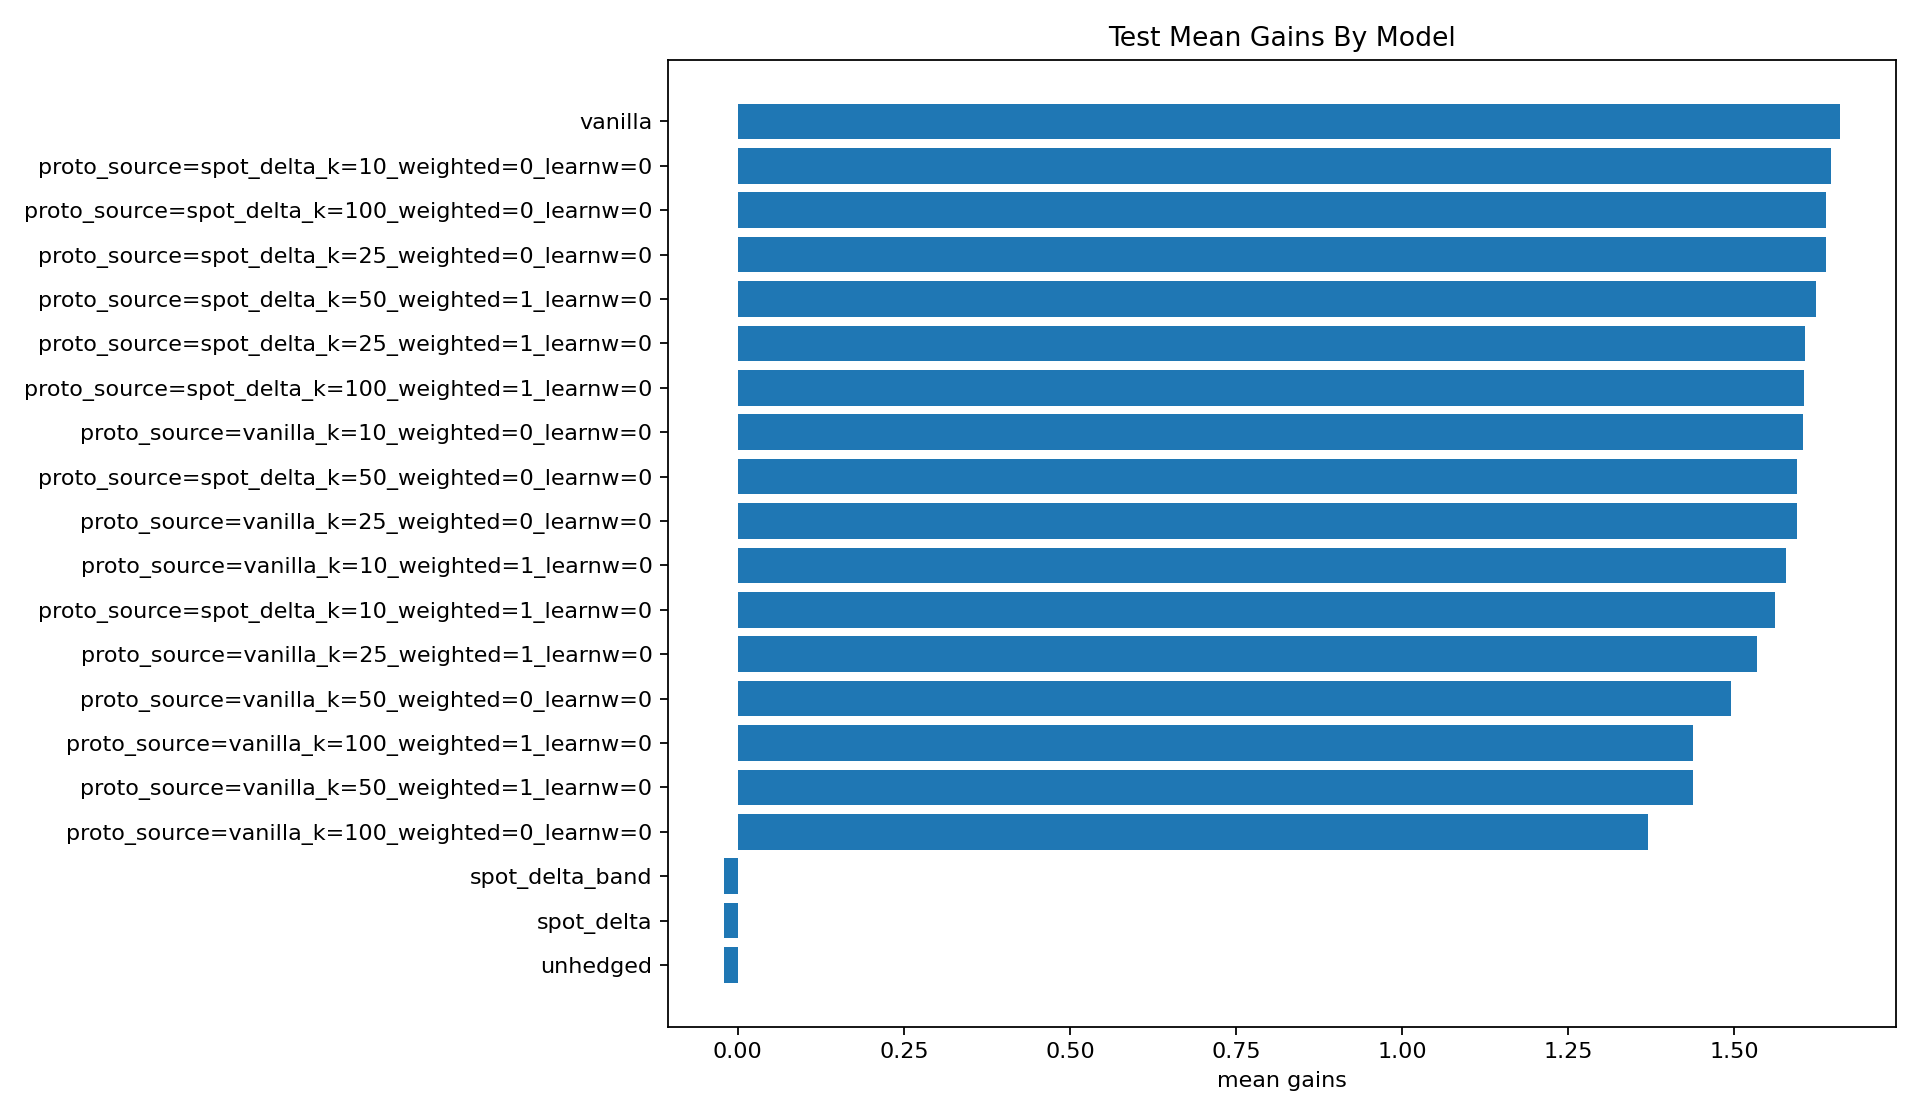

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/sweep_test_cvar05.png


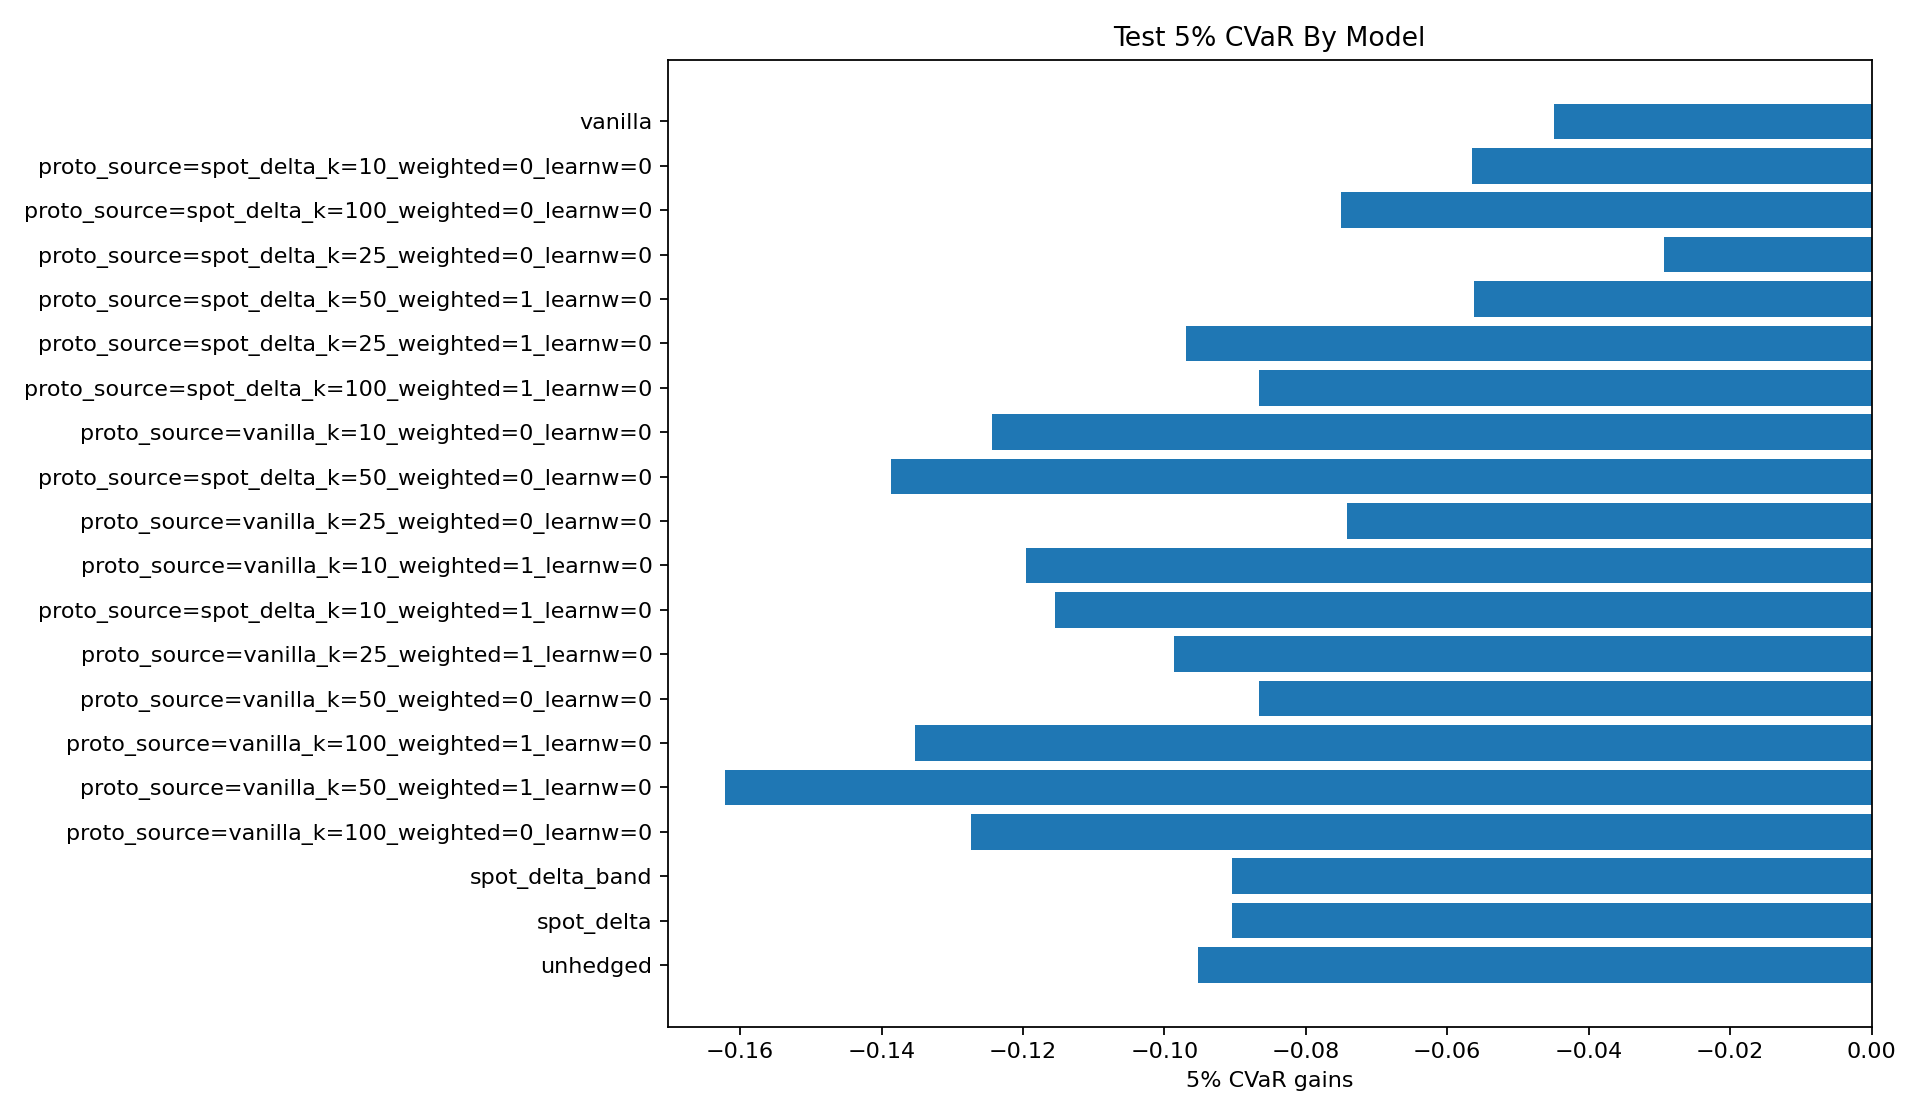

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/sweep_test_shortfall_prob.png


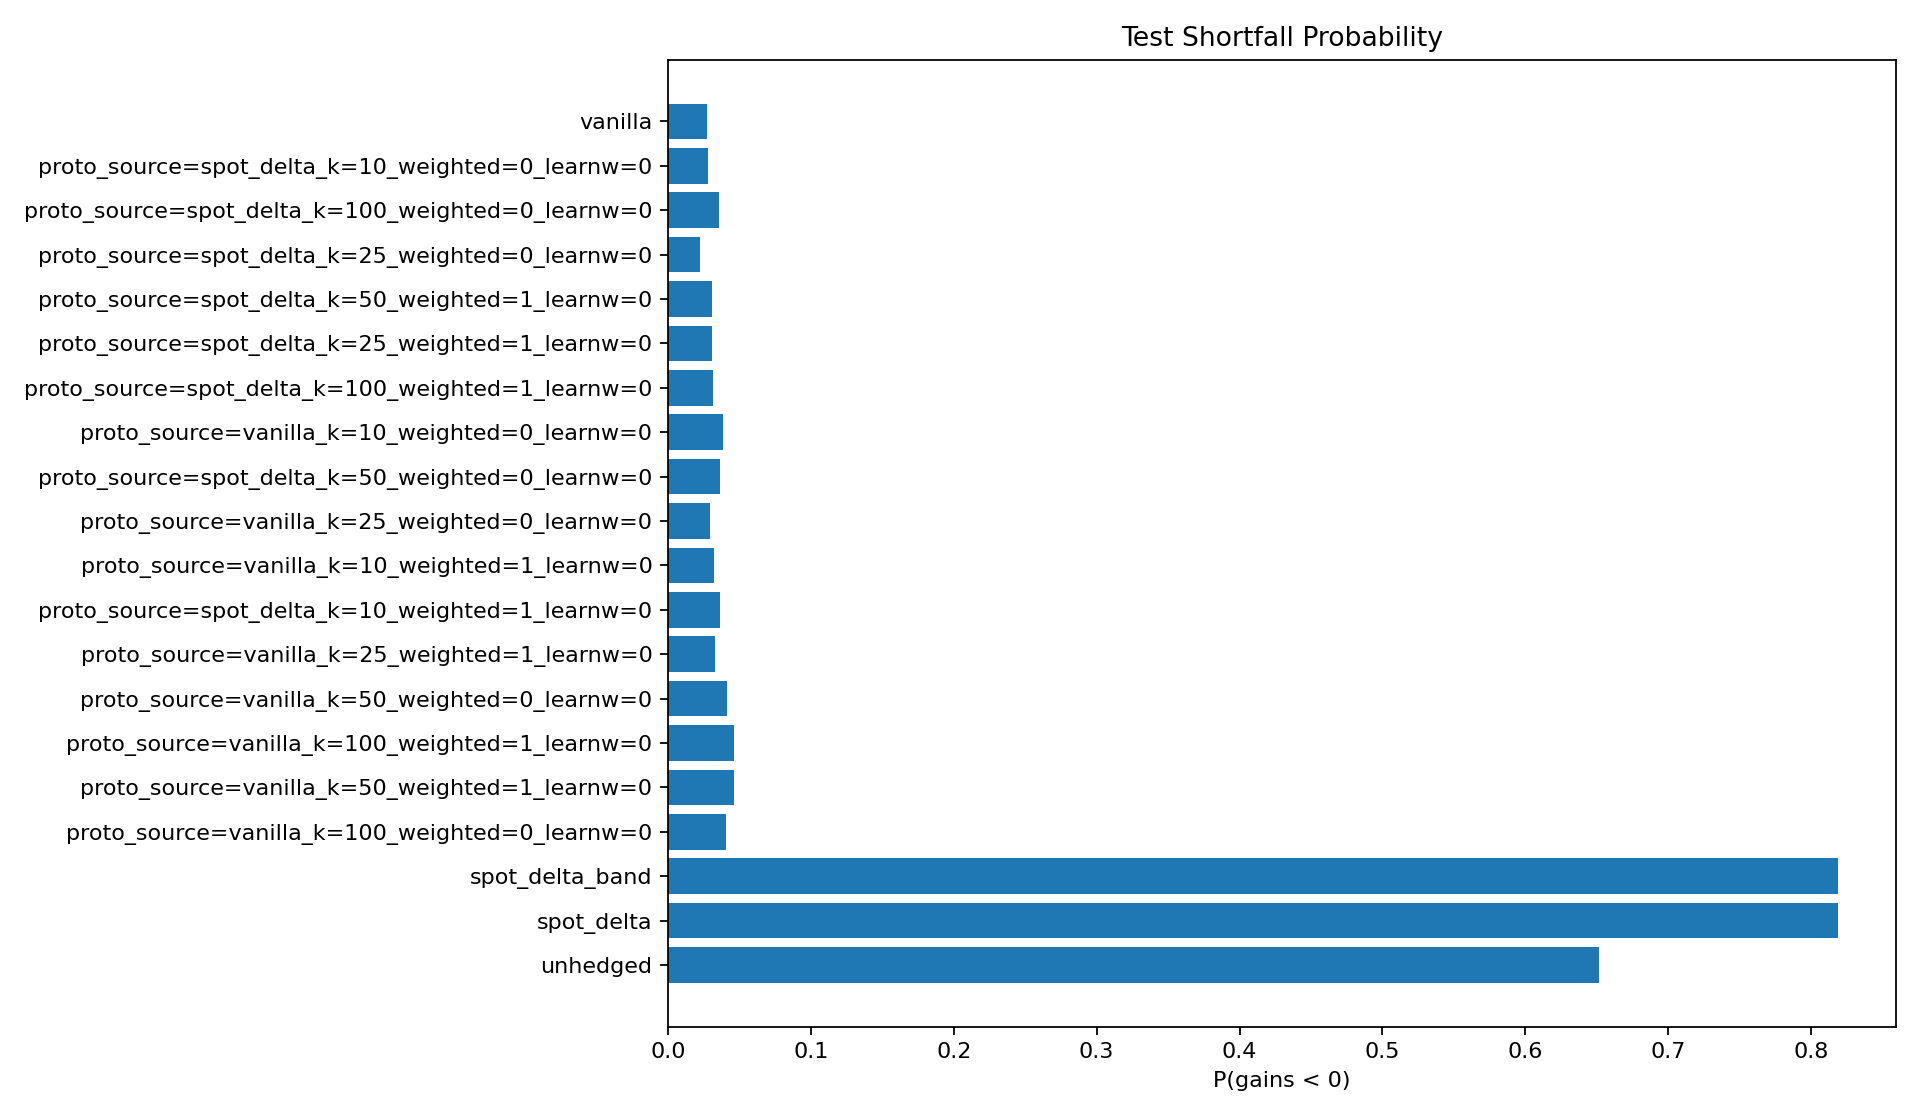

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/sweep_test_bound_saturation.png


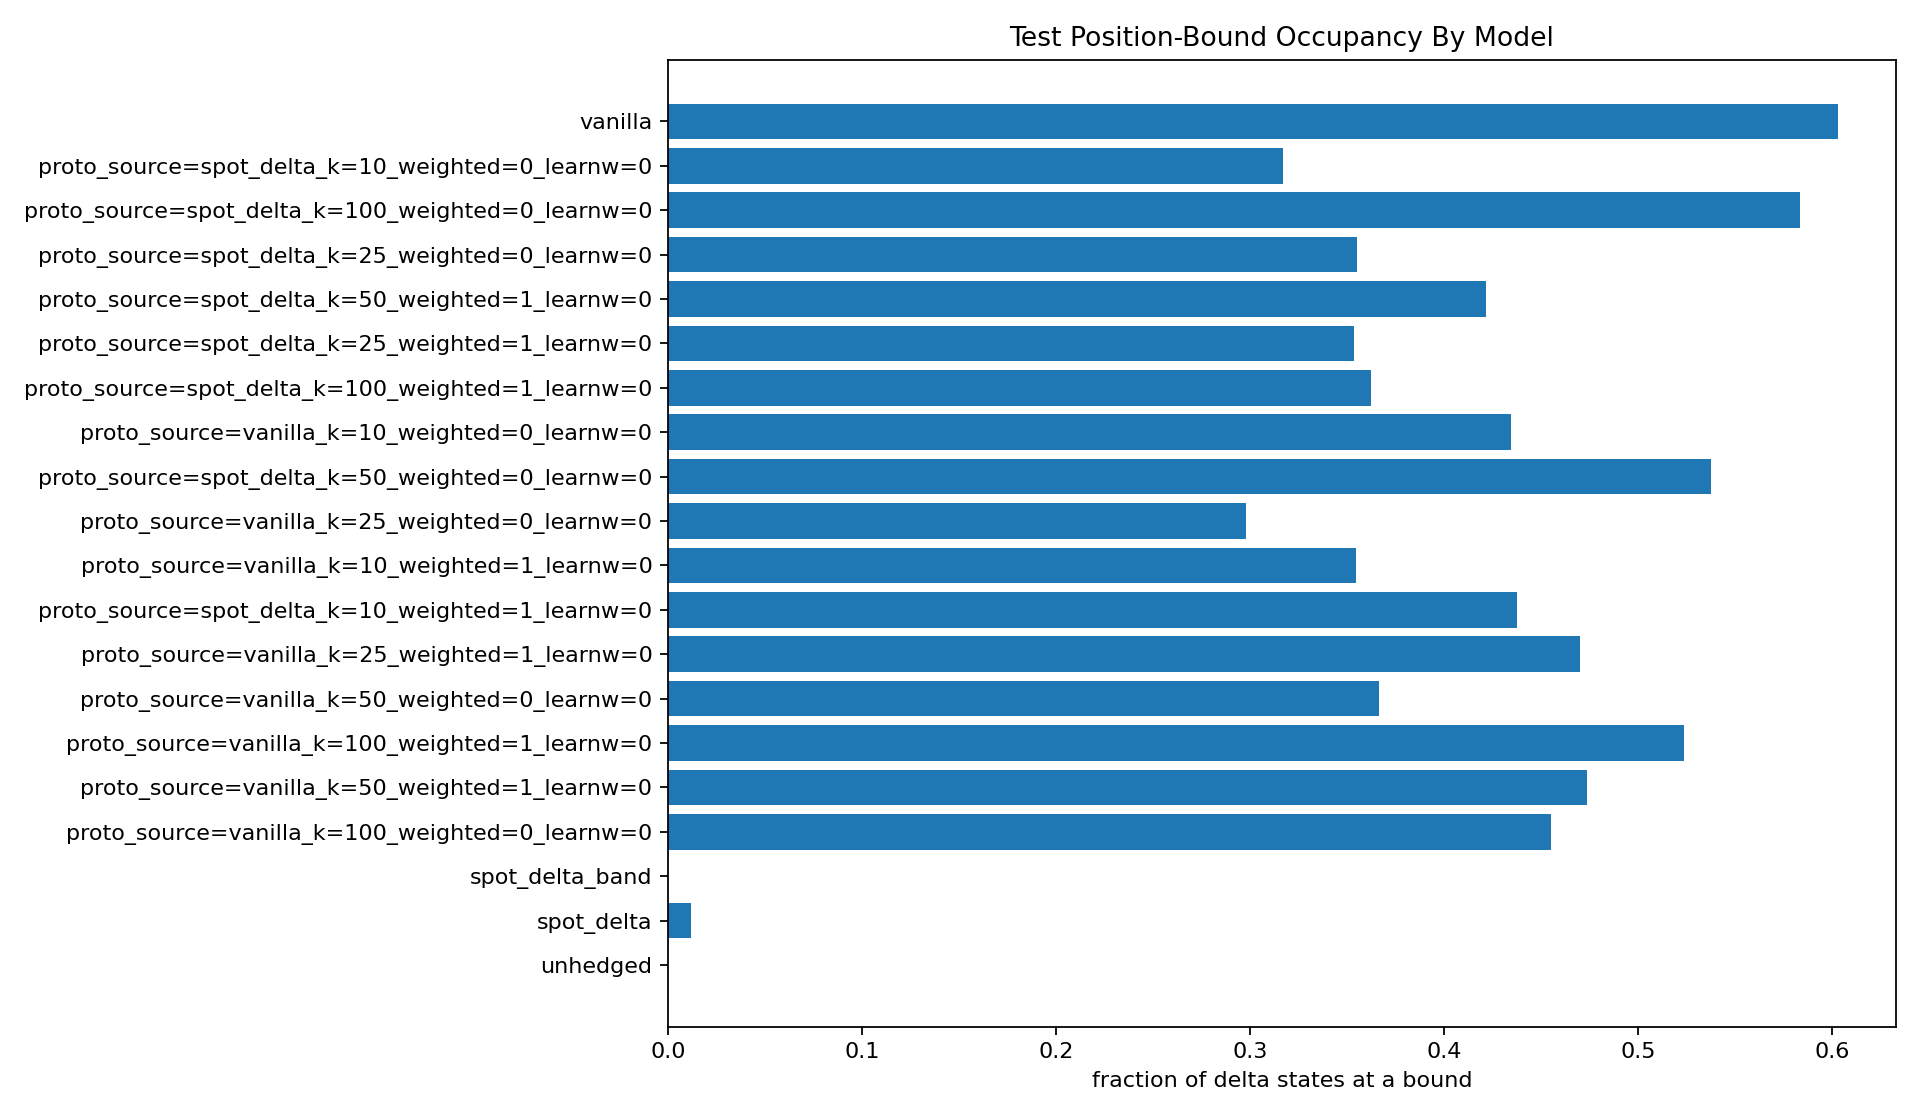

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/proto_gains_vs_n_prototypes.png


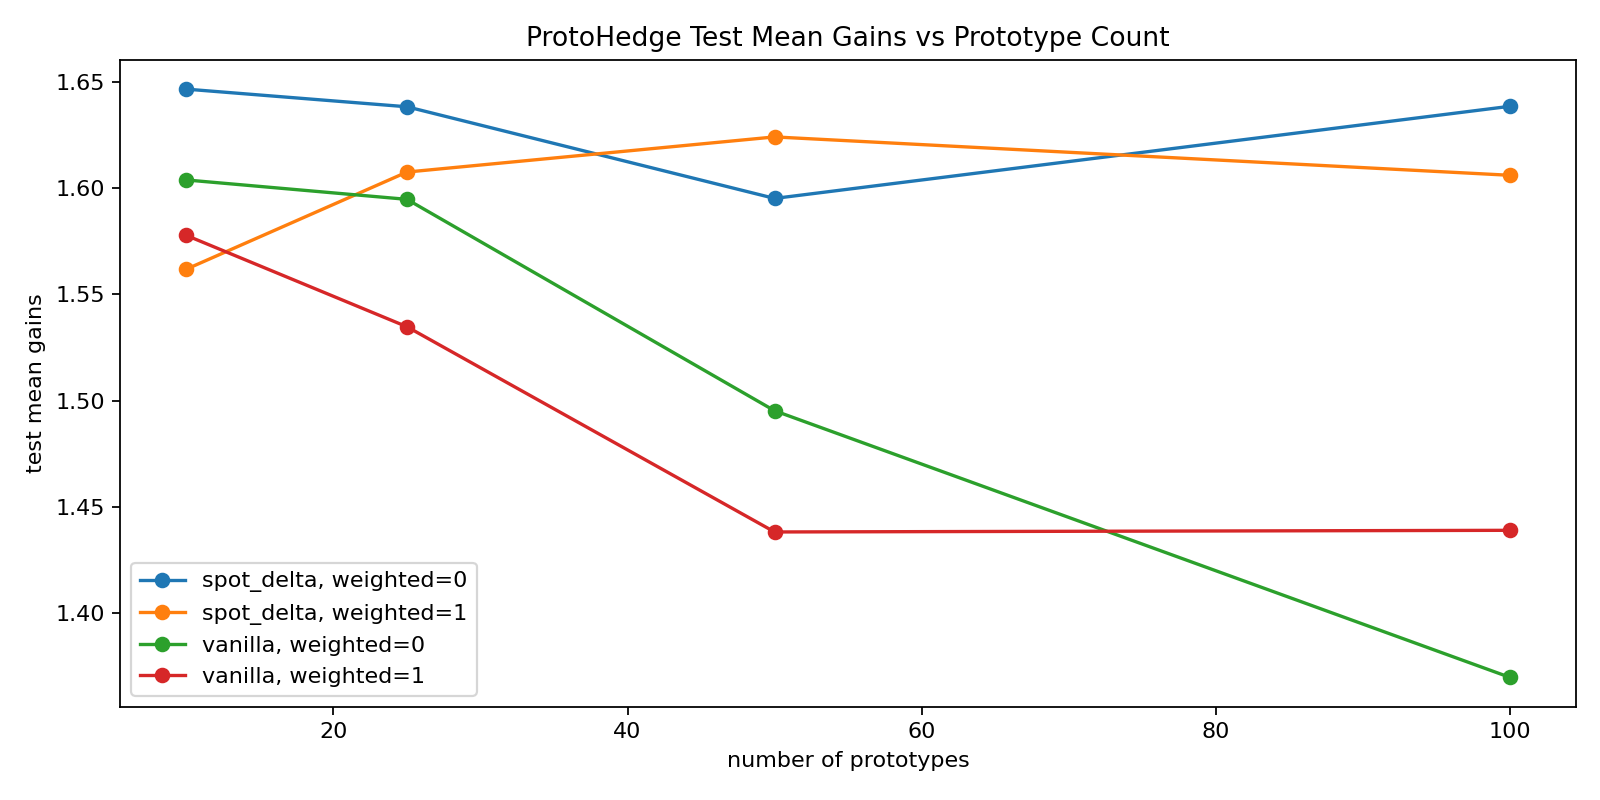

/Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/proto_cvar05_vs_n_prototypes.png


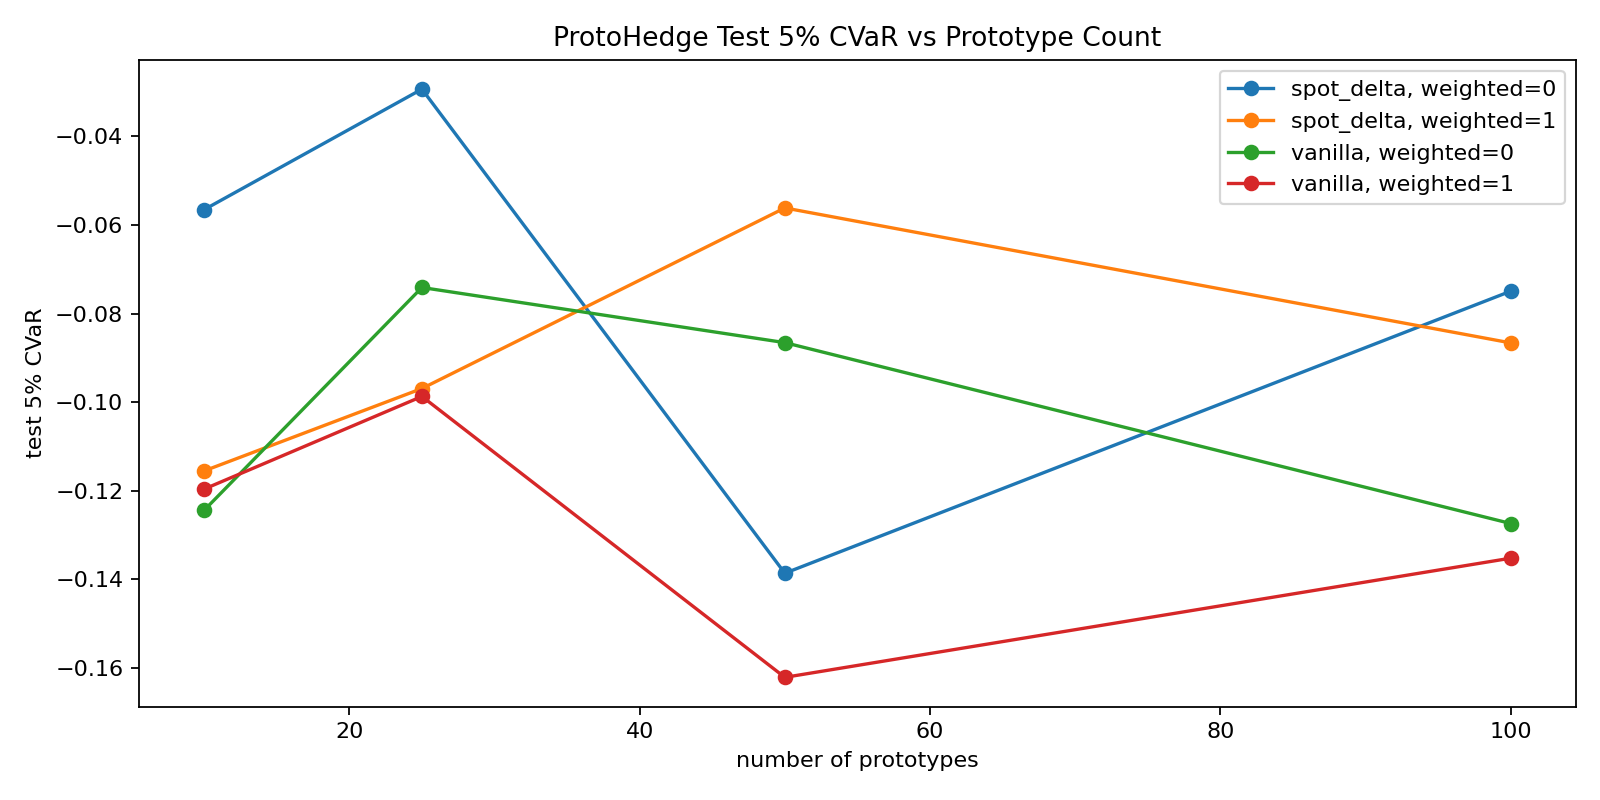

In [134]:
from IPython.display import Image, display as ipy_display, Markdown

summary_path = SWEEP_OUTPUT_DIR / "sweep_test_summary.csv"
paper_comparison_path = SWEEP_OUTPUT_DIR / "paper_model_comparison.csv"
paper_best_path = SWEEP_OUTPUT_DIR / "paper_best_models.csv"
paper_selected_path = SWEEP_OUTPUT_DIR / "paper_selected_table.csv"
interpretation_path = SWEEP_OUTPUT_DIR / "interpretation.md"

if summary_path.exists():
    sweep_summary_df = pd.read_csv(summary_path)
    display_cols = [
        "model", "model_family", "prototype_source", "n_prototypes", "weighted_similarity",
        "gains_mean_avg", "gains_p05_avg", "gains_cvar05_avg", "shortfall_prob_avg",
        "pct_at_any_position_bound_avg", "pct_paths_touch_any_position_bound_avg",
        "selected_epoch_avg", "selected_score_avg", "selected_val_pct_at_any_position_bound_avg",
        "passes_robust_screen", "selected_band_avg", "n_runs",
    ]
    display_cols = [c for c in display_cols if c in sweep_summary_df.columns]
    display(sweep_summary_df[display_cols].head(30))
else:
    sweep_summary_df = None
    print("No sweep summary found yet:", summary_path)

if paper_best_path.exists():
    paper_best_df = pd.read_csv(paper_best_path)
    display_cols = [
        "selection", "model", "model_family", "prototype_source", "n_prototypes", "weighted_similarity",
        "gains_mean_avg", "gains_cvar05_avg", "shortfall_prob_avg",
        "pct_at_any_position_bound_avg", "selected_epoch_avg", "selected_score_avg",
        "passes_robust_screen", "selected_band_avg", "n_runs",
    ]
    display_cols = [c for c in display_cols if c in paper_best_df.columns]
    print("Best model selections:")
    display(paper_best_df[display_cols])

if paper_selected_path.exists():
    paper_selected_df = pd.read_csv(paper_selected_path)
    display_cols = [
        "model", "model_family", "prototype_source", "n_prototypes", "weighted_similarity",
        "gains_mean_avg", "gains_cvar05_avg", "shortfall_prob_avg",
        "pct_at_any_position_bound_avg", "selected_epoch_avg", "selected_score_avg",
        "passes_robust_screen", "selected_band_avg", "n_runs",
    ]
    display_cols = [c for c in display_cols if c in paper_selected_df.columns]
    print("Paper selected comparison table:")
    display(paper_selected_df[display_cols])

if paper_comparison_path.exists():
    paper_comparison_df = pd.read_csv(paper_comparison_path)
    screened_df = paper_comparison_df[paper_comparison_df["passes_robust_screen"] == True].copy() if "passes_robust_screen" in paper_comparison_df.columns else pd.DataFrame()
    if not screened_df.empty:
        display_cols = [
            "model", "model_family", "prototype_source", "n_prototypes", "weighted_similarity",
            "gains_mean_avg", "gains_cvar05_avg", "shortfall_prob_avg",
            "pct_at_any_position_bound_avg", "selected_epoch_avg", "selected_score_avg",
        ]
        display_cols = [c for c in display_cols if c in screened_df.columns]
        print("Models passing the robustness screen:")
        display(screened_df[display_cols].sort_values("gains_mean_avg", ascending=False).head(20))
    else:
        print("No model passed the current robustness screen.")

if interpretation_path.exists():
    ipy_display(Markdown(interpretation_path.read_text()))

plot_files = [
    "sweep_test_gains_mean.png",
    "sweep_test_cvar05.png",
    "sweep_test_shortfall_prob.png",
    "sweep_test_bound_saturation.png",
    "proto_gains_vs_n_prototypes.png",
    "proto_cvar05_vs_n_prototypes.png",
]
for filename in plot_files:
    path = SWEEP_OUTPUT_DIR / filename
    if path.exists():
        print(path)
        ipy_display(Image(filename=str(path)))

## 23. Sweep-Level Interpretation Template

Use this template after the sweep finishes:

- If vanilla still wins mean and ProtoHedge stays close while reducing bound occupancy, that is a positive empirical result.
- If a screened ProtoHedge configuration is within 1--2% of vanilla mean, that is already strong support for the "interpretability at low cost" story.
- If a ProtoHedge configuration beats vanilla on some tail metric while remaining near vanilla on mean, that is especially interesting.
- If ProtoHedge only looks strong when it fails the robustness screen, do not use that as the paper result.
- If multiple screened ProtoHedge configurations survive across seeds, move them into the paper frontier.
- The next task after the multi-seed sweep is no longer more training alone; it is frontier selection, regime slicing, and prototype interpretation.

In the larger picture, this is the bridge from "the PyTorch port runs on real data" to "we have empirical evidence about the performance-interpretability tradeoff of ProtoHedge on historical hedging episodes."


## 24. Frontier Shortlist From The Paper Sweep

This cell turns the sweep output into a paper-facing shortlist. The goal is to find screened ProtoHedge configurations that stay close to vanilla on gains and therefore best support the interpretability-at-low-cost claim.


In [135]:
import importlib
import deephedging.real_data_analysis_torch as real_data_analysis_torch
real_data_analysis_torch = importlib.reload(real_data_analysis_torch)

FRONTIER_SHORTLIST_PATH = SWEEP_OUTPUT_DIR / "frontier_shortlist.csv"
ARTIFACT_INDEX_PATH = SWEEP_OUTPUT_DIR / "artifact_index.csv"
SWEEP_METRICS_PATH = SWEEP_OUTPUT_DIR / "sweep_metrics.csv"

if summary_path.exists():
    frontier_df = real_data_analysis_torch.build_frontier_candidates(
        sweep_summary_df,
        vanilla_tol_pct=ANALYSIS_FRONTIER_TOL_PCT,
    )
    artifact_index_df = real_data_analysis_torch.list_saved_artifacts(SWEEP_OUTPUT_DIR)
    frontier_df.to_csv(FRONTIER_SHORTLIST_PATH, index=False)
    artifact_index_df.to_csv(ARTIFACT_INDEX_PATH, index=False)
    print("saved:", FRONTIER_SHORTLIST_PATH)
    print("saved:", ARTIFACT_INDEX_PATH)
    display(frontier_df)

    if SWEEP_METRICS_PATH.exists():
        sweep_metrics_df = pd.read_csv(SWEEP_METRICS_PATH)
        compare_models = frontier_df["model"].tolist() + ["vanilla", "spot_delta", "unhedged"]
        frontier_seed_df = sweep_metrics_df[
            (sweep_metrics_df["split"] == "test")
            & (sweep_metrics_df["model"].isin(compare_models))
        ].copy()
        display_cols = [
            "model", "seed", "gains_mean", "gains_p05", "gains_cvar05", "shortfall_prob",
            "pct_at_any_position_bound", "selected_epoch", "selected_score", "artifact_dir",
        ]
        display_cols = [c for c in display_cols if c in frontier_seed_df.columns]
        print("Seed-level test rows for the frontier candidates:")
        display(frontier_seed_df[display_cols].sort_values(["model", "seed"]).reset_index(drop=True))
else:
    frontier_df = None
    artifact_index_df = pd.DataFrame()
    print("No sweep summary found yet; run the sweep first.")


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_shortlist.csv
saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/artifact_index.csv


,reason,model,model_family,prototype_source,n_prototypes,weighted_similarity,learn_distance_feature_weights,risk_measure,n_runs,gains_mean_avg,gains_mean_std,gains_p05_avg,gains_cvar05_avg,shortfall_prob_avg,delta_abs_max_avg,action_abs_mean_avg,pct_at_any_position_bound_avg,pct_at_upper_position_bound_avg,pct_at_lower_position_bound_avg,pct_paths_touch_any_position_bound_avg,selected_epoch_avg,selected_score_avg,selected_val_pct_at_any_position_bound_avg,selected_val_pct_paths_touch_any_position_bound_avg,selected_band_avg,passes_bound_occupancy_screen,passes_path_touch_screen,passes_robust_screen
0,best_screened_mean,proto_source=spot_delta_k=10_weighted=0_learnw=0,proto,spot_delta,10.0,False,False,cvar,3,1.646594,0.039342,0.115969,-0.056544,0.027695,1.0,0.367824,0.317099,0.091345,0.225754,1.0,747.000000,-0.749799,0.297086,0.999008,NaN,True,True,True
1,best_screened_cvar05,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,spot_delta,25.0,False,False,cvar,3,1.638294,0.012456,0.136032,-0.029352,0.022255,1.0,0.378348,0.355106,0.104797,0.250309,1.0,527.333333,-0.745368,0.350893,1.000000,NaN,True,True,True


Seed-level test rows for the frontier candidates:


,model,seed,gains_mean,gains_p05,gains_cvar05,shortfall_prob,pct_at_any_position_bound,selected_epoch,selected_score,artifact_dir
0,proto_source=spot_delta_k=10_weighted=0_learnw=0,1234,1.621228,0.022975,-0.124600,0.041543,0.475000,710.0,-0.739267,/Users/yaniszaim/deephedging/.deephedging_real...
1,proto_source=spot_delta_k=10_weighted=0_learnw=0,2345,1.691915,0.159162,-0.035082,0.019288,0.228895,732.0,-0.754882,/Users/yaniszaim/deephedging/.deephedging_real...
2,proto_source=spot_delta_k=10_weighted=0_learnw=0,3456,1.626637,0.165770,-0.009952,0.022255,0.247404,799.0,-0.755248,/Users/yaniszaim/deephedging/.deephedging_real...
3,proto_source=spot_delta_k=25_weighted=0_learnw=0,1234,1.637365,0.101427,-0.060942,0.031157,0.421105,655.0,-0.739363,/Users/yaniszaim/deephedging/.deephedging_real...
4,proto_source=spot_delta_k=25_weighted=0_learnw=0,2345,1.651188,0.143011,-0.028432,0.020772,0.305675,471.0,-0.747401,/Users/yaniszaim/deephedging/.deephedging_real...
5,proto_source=spot_delta_k=25_weighted=0_learnw=0,3456,1.626328,0.163659,0.001319,0.014837,0.338539,456.0,-0.749342,/Users/yaniszaim/deephedging/.deephedging_real...
6,spot_delta,1234,-0.019698,-0.064111,-0.084592,0.808605,0.011573,NaN,NaN,NaN
7,spot_delta,2345,-0.021716,-0.068125,-0.093049,0.832344,0.011684,NaN,NaN,NaN
8,spot_delta,3456,-0.021376,-0.067401,-0.093670,0.814540,0.012055,NaN,NaN,NaN
9,unhedged,1234,-0.020197,-0.067500,-0.092059,0.646884,0.000000,NaN,NaN,NaN


## 25. Reload Representative Models For Deeper Analysis

The sweep now saves reloadable trained models. For the deeper analysis below, we use the first seed from the preset as a representative held-out split and reload vanilla plus the strongest screened ProtoHedge candidates from that seed.


In [136]:
FRONTIER_ANALYSIS_SEED = int(preset["seeds"][0])
FRONTIER_ANALYSIS_DIR = SWEEP_OUTPUT_DIR / f"frontier_analysis_seed_{FRONTIER_ANALYSIS_SEED}"
FRONTIER_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
MAX_FRONTIER_PROTO_MODELS = 3

if frontier_df is not None and not frontier_df.empty and not artifact_index_df.empty:
    proto_frontier_df = frontier_df[frontier_df["model_family"] == "proto"].head(MAX_FRONTIER_PROTO_MODELS).copy()
    proto_frontier_df["analysis_label"] = [
        "proto_mean" if reason == "best_screened_mean" else
        "proto_tail" if reason == "best_screened_cvar05" else
        "proto_shortfall" if reason == "best_screened_shortfall" else
        f"proto_near_{i+1}"
        for i, reason in enumerate(proto_frontier_df["reason"].tolist())
    ]

    selection_rows = [{"analysis_label": "vanilla", "model": "vanilla"}]
    selection_rows.extend(proto_frontier_df[["analysis_label", "model", "reason"]].to_dict(orient="records"))

    selected_artifacts = []
    for item in selection_rows:
        model_name = item["model"]
        rows = artifact_index_df[
            (artifact_index_df["model_name"] == model_name)
            & (artifact_index_df["seed"] == FRONTIER_ANALYSIS_SEED)
        ].copy()
        if rows.empty:
            rows = artifact_index_df[artifact_index_df["model_name"] == model_name].copy()
        if rows.empty:
            continue
        row = rows.sort_values(["best_score", "best_epoch"], ascending=[True, True]).iloc[0].to_dict()
        row.update(item)
        selected_artifacts.append(row)

    selected_artifacts_df = pd.DataFrame(selected_artifacts)
    selected_artifacts_df.to_csv(FRONTIER_ANALYSIS_DIR / "selected_artifacts.csv", index=False)
    print("saved:", FRONTIER_ANALYSIS_DIR / "selected_artifacts.csv")
    display(selected_artifacts_df)

    frontier_bundles = {}
    frontier_results = {}
    for row in selected_artifacts:
        bundle, result, metrics = real_data_analysis_torch.evaluate_saved_artifact(row["artifact_dir"], split="test")
        frontier_bundles[row["analysis_label"]] = bundle
        frontier_results[row["analysis_label"]] = {
            "model_name": row["model"],
            "result": result,
            "metrics": metrics,
        }

    if selected_artifacts:
        baseline_eval = real_data_analysis_torch.evaluate_saved_baselines(selected_artifacts[0]["artifact_dir"], split="test")
    else:
        baseline_eval = None
else:
    selected_artifacts_df = pd.DataFrame()
    frontier_bundles = {}
    frontier_results = {}
    baseline_eval = None
    print("Frontier artifacts are not available yet.")


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_analysis_seed_1234/selected_artifacts.csv


,artifact_dir,model_name,model_family,seed,risk_measure,prototype_source,n_prototypes,weighted_similarity,learn_distance_feature_weights,best_epoch,best_score,analysis_label,model,reason
0,/Users/yaniszaim/deephedging/.deephedging_real...,vanilla,vanilla,1234,cvar,None,NaN,None,None,755,-0.695907,vanilla,vanilla,NaN
1,/Users/yaniszaim/deephedging/.deephedging_real...,proto_source=spot_delta_k=10_weighted=0_learnw=0,proto,1234,cvar,spot_delta,10.0,False,False,710,-0.739267,proto_mean,proto_source=spot_delta_k=10_weighted=0_learnw=0,best_screened_mean
2,/Users/yaniszaim/deephedging/.deephedging_real...,proto_source=spot_delta_k=25_weighted=0_learnw=0,proto,1234,cvar,spot_delta,25.0,False,False,655,-0.739363,proto_tail,proto_source=spot_delta_k=25_weighted=0_learnw=0,best_screened_cvar05


/Users/yaniszaim/deephedging/real_data_analysis_torch.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(artifact_dir / ARTIFACT_STATE, map_locatio

## 26. Regime Robustness For The Frontier Models

This section moves from overall averages to market conditions. We slice the held-out test episodes by return, implied-volatility, and drawdown regimes, then compare the shortlisted models inside those buckets.


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_analysis_seed_1234/regime_frame.csv
saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_analysis_seed_1234/regime_summary.csv


,regime_type,regime,series,n,mean,p05,cvar05,shortfall_prob
0,return_regime,down,unhedged_gains,225,0.000000,0.000000,0.000000,0.000000
1,return_regime,down,spot_delta_gains,225,-0.002247,-0.023356,-0.038401,0.551111
2,return_regime,down,vanilla_gains,225,1.558297,0.089945,-0.003779,0.031111
3,return_regime,down,proto_mean_gains,225,1.532081,0.026455,-0.102839,0.040000
4,return_regime,down,proto_tail_gains,225,1.526314,0.089606,-0.054845,0.031111
5,return_regime,middle,unhedged_gains,224,-0.012544,-0.025072,-0.025405,0.941964
6,return_regime,middle,spot_delta_gains,224,-0.012694,-0.030144,-0.037668,0.879464
7,return_regime,middle,vanilla_gains,224,1.783665,0.150916,-0.083474,0.031250
8,return_regime,middle,proto_mean_gains,224,1.773207,0.080352,-0.085502,0.031250
9,return_regime,middle,proto_tail_gains,224,1.823921,0.148270,0.012823,0.017857


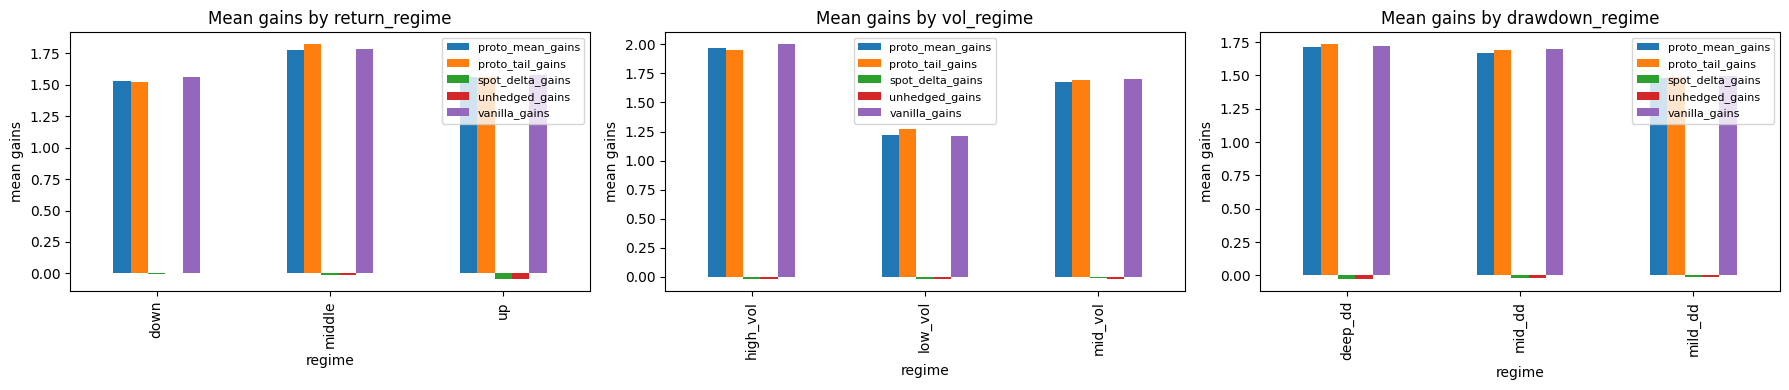

saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_analysis_seed_1234/regime_mean_gains.png


In [137]:
import matplotlib.pyplot as plt

if frontier_results and baseline_eval is not None:
    regime_world = baseline_eval["world"]
    regime_result_dict = {
        "unhedged": baseline_eval["unhedged"]["result"],
        "spot_delta": baseline_eval["spot_delta"]["result"],
        "vanilla": frontier_results["vanilla"]["result"],
    }
    for analysis_label in [k for k in frontier_results.keys() if k != "vanilla"]:
        regime_result_dict[analysis_label] = frontier_results[analysis_label]["result"]

    regime_frame = real_data_analysis_torch.build_regime_frame(regime_world, regime_result_dict)
    regime_frame.to_csv(FRONTIER_ANALYSIS_DIR / "regime_frame.csv", index=False)

    regime_summaries = []
    series_cols = [c for c in regime_frame.columns if c.endswith("_gains")]
    for regime_col in ["return_regime", "vol_regime", "drawdown_regime"]:
        regime_summaries.append(real_data_analysis_torch.summarize_by_regime(regime_frame, regime_col, series_cols=series_cols))
    frontier_regime_summary = pd.concat(regime_summaries, ignore_index=True)
    frontier_regime_summary.to_csv(FRONTIER_ANALYSIS_DIR / "regime_summary.csv", index=False)
    print("saved:", FRONTIER_ANALYSIS_DIR / "regime_frame.csv")
    print("saved:", FRONTIER_ANALYSIS_DIR / "regime_summary.csv")
    display(frontier_regime_summary)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, regime_col in zip(axes, ["return_regime", "vol_regime", "drawdown_regime"]):
        plot_df = frontier_regime_summary[
            (frontier_regime_summary["regime_type"] == regime_col)
            & (frontier_regime_summary["series"].str.endswith("_gains"))
        ].copy()
        pivot = plot_df.pivot(index="regime", columns="series", values="mean")
        pivot.plot(kind="bar", ax=ax)
        ax.set_title(f"Mean gains by {regime_col}")
        ax.set_ylabel("mean gains")
        ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.savefig(FRONTIER_ANALYSIS_DIR / "regime_mean_gains.png", dpi=160, bbox_inches="tight")
    plt.show()
    print("saved:", FRONTIER_ANALYSIS_DIR / "regime_mean_gains.png")
else:
    regime_world = None
    regime_frame = None
    frontier_regime_summary = pd.DataFrame()
    print("Frontier models have not been reloaded yet.")


## 27. Prototype Interpretation For The Best Screened Frontier Model

This section turns the strongest screened ProtoHedge candidate into paper-facing prototype evidence: which prototypes are used most, what raw feature states they represent, what actions they recommend, and how usage shifts across regimes.


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_analysis_seed_1234/proto_mean_prototype_top15.csv
saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_analysis_seed_1234/proto_mean_prototype_full.csv


,prototype_index,usage_mean,top1_frequency,delta_0,delta_1,price_0,price_1,time_left,proto_action_0,proto_action_1
0,2,0.305880,0.334050,1.148230e-08,0.0,1.000000,0.639225,0.40,-0.841516,-0.917876
1,9,0.242769,0.240134,9.812700e-01,0.0,0.807064,0.324927,0.14,0.333564,0.999877
2,6,0.241916,0.248591,1.148230e-08,0.0,1.000000,0.245018,0.40,-0.160271,0.999877
3,4,0.137968,0.139911,9.968690e-01,0.0,1.062357,0.674642,0.12,-0.372436,-1.126819
4,1,0.026756,0.007493,9.998370e-01,0.0,1.006506,0.636468,0.12,-0.943971,-0.089813
5,8,0.023055,0.014837,9.952950e-01,0.0,1.001056,0.641462,0.30,-0.520763,-0.681012
6,7,0.018486,0.012018,9.997170e-01,0.0,0.940274,0.500297,0.14,-0.485990,0.360755
7,5,0.001918,0.002967,9.996850e-01,0.0,0.987102,0.243423,0.12,-0.800052,0.356685
8,0,0.000912,0.000000,9.991040e-01,0.0,1.004843,0.237737,0.30,-0.137173,0.527501
9,3,0.000337,0.000000,9.961550e-01,0.0,1.030923,0.236097,0.10,-0.861245,0.002455


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_analysis_seed_1234/proto_mean_prototype_usage_by_regime.csv


prototype,prototype_2,prototype_9,prototype_6,prototype_4,prototype_1,prototype_8,prototype_7,prototype_5,prototype_0,prototype_3
regime,,,,,,,,,,
down,0.338072,0.267843,0.198142,0.137156,0.019062,0.023244,0.015718,0.000449,0.000247,0.000068
middle,0.295688,0.245330,0.255635,0.133672,0.025837,0.023066,0.018019,0.001631,0.000769,0.000354
up,0.283836,0.215148,0.272036,0.143061,0.035364,0.022854,0.021719,0.003672,0.001720,0.000590


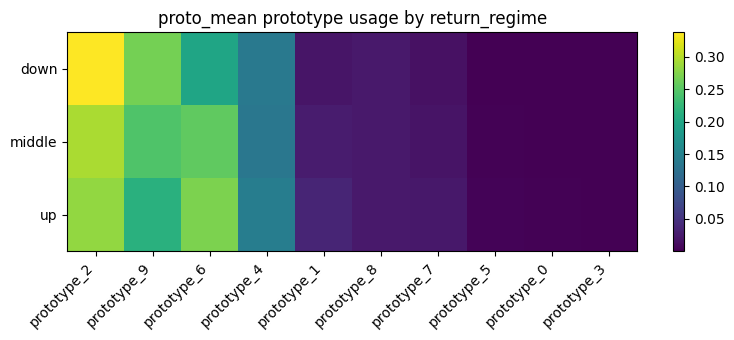

saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_analysis_seed_1234/proto_mean_return_regime_prototype_usage_heatmap.png


prototype,prototype_2,prototype_9,prototype_6,prototype_4,prototype_1,prototype_8,prototype_7,prototype_5,prototype_0,prototype_3
regime,,,,,,,,,,
high_vol,0.426163,0.216093,0.164063,0.134316,0.021581,0.019995,0.016219,0.000944,0.000463,0.000163
low_vol,0.147874,0.269328,0.367367,0.148424,0.025634,0.017359,0.018221,0.003514,0.001676,0.000604
mid_vol,0.343773,0.242889,0.194109,0.131137,0.033080,0.031850,0.021030,0.001292,0.000596,0.000243


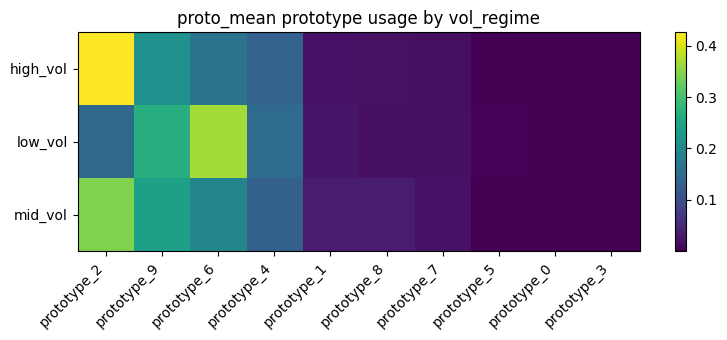

saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_analysis_seed_1234/proto_mean_vol_regime_prototype_usage_heatmap.png


prototype,prototype_2,prototype_9,prototype_6,prototype_4,prototype_1,prototype_8,prototype_7,prototype_5,prototype_0,prototype_3
regime,,,,,,,,,,
deep_dd,0.270323,0.234747,0.288406,0.132727,0.030306,0.019799,0.019209,0.002698,0.001303,0.000482
mid_dd,0.300911,0.236571,0.254965,0.135587,0.026915,0.023289,0.017753,0.002437,0.001118,0.000453
mild_dd,0.346385,0.256963,0.182438,0.145583,0.023047,0.026077,0.018493,0.000620,0.000317,0.000077


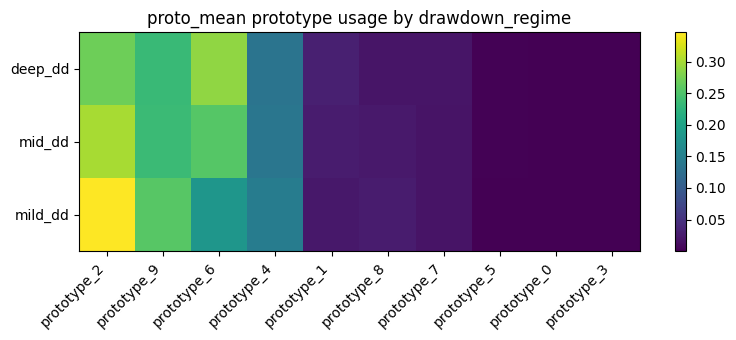

saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/frontier_analysis_seed_1234/proto_mean_drawdown_regime_prototype_usage_heatmap.png


In [138]:
if frontier_results and baseline_eval is not None:
    proto_focus_label = None
    for candidate in ["proto_mean", "proto_tail", "proto_shortfall"]:
        if candidate in frontier_results:
            proto_focus_label = candidate
            break
    if proto_focus_label is None:
        proto_focus_label = next((k for k in frontier_results.keys() if k != "vanilla"), None)

    if proto_focus_label is not None:
        proto_bundle = frontier_bundles[proto_focus_label]
        proto_result = frontier_results[proto_focus_label]["result"]
        proto_top_df, proto_full_df = real_data_analysis_torch.prototype_usage_table(
            proto_bundle,
            proto_result,
            top_n=15,
        )
        proto_top_df.to_csv(FRONTIER_ANALYSIS_DIR / f"{proto_focus_label}_prototype_top15.csv", index=False)
        proto_full_df.to_csv(FRONTIER_ANALYSIS_DIR / f"{proto_focus_label}_prototype_full.csv", index=False)
        print("saved:", FRONTIER_ANALYSIS_DIR / f"{proto_focus_label}_prototype_top15.csv")
        print("saved:", FRONTIER_ANALYSIS_DIR / f"{proto_focus_label}_prototype_full.csv")
        display(proto_top_df)

        if regime_frame is not None:
            proto_regime_usage = real_data_analysis_torch.prototype_usage_by_regime(proto_result, regime_frame)
            proto_regime_usage.to_csv(FRONTIER_ANALYSIS_DIR / f"{proto_focus_label}_prototype_usage_by_regime.csv", index=False)
            print("saved:", FRONTIER_ANALYSIS_DIR / f"{proto_focus_label}_prototype_usage_by_regime.csv")

            top_proto_names = [f"prototype_{int(i)}" for i in proto_top_df["prototype_index"].head(10).tolist()]
            for regime_col in ["return_regime", "vol_regime", "drawdown_regime"]:
                plot_df = proto_regime_usage[proto_regime_usage["regime_type"] == regime_col].copy()
                pivot = plot_df.pivot(index="regime", columns="prototype", values="mean_weight")
                pivot = pivot[[c for c in top_proto_names if c in pivot.columns]]
                display(pivot)
                fig, ax = plt.subplots(figsize=(max(8, 0.8 * len(pivot.columns)), 3.5))
                im = ax.imshow(pivot.to_numpy(), aspect="auto")
                ax.set_xticks(range(len(pivot.columns)))
                ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
                ax.set_yticks(range(len(pivot.index)))
                ax.set_yticklabels(pivot.index)
                ax.set_title(f"{proto_focus_label} prototype usage by {regime_col}")
                fig.colorbar(im, ax=ax)
                plt.tight_layout()
                out_path = FRONTIER_ANALYSIS_DIR / f"{proto_focus_label}_{regime_col}_prototype_usage_heatmap.png"
                plt.savefig(out_path, dpi=160, bbox_inches="tight")
                plt.show()
                print("saved:", out_path)
    else:
        print("No ProtoHedge frontier model was reloaded.")
else:
    print("Frontier models have not been reloaded yet.")


## 28. Finalize The Paper Frontier

This section assumes the sweep has already been run and uses the saved sweep outputs to define the final model set for the empirical-validation section: unhedged, spot-delta, vanilla Deep Hedging, the mean-oriented ProtoHedge frontier model, and the tail-oriented ProtoHedge frontier model.

In [139]:
from pathlib import Path
import importlib
import pandas as pd
from IPython.display import display

from deephedging import real_data_analysis_torch

importlib.reload(real_data_analysis_torch)

if "SWEEP_OUTPUT_DIR" not in globals():
    _sweep_candidates = [
        Path(".deephedging_real_runs/real_data_sweep_paper_800_step_robust"),
        Path("../.deephedging_real_runs/real_data_sweep_paper_800_step_robust"),
        Path(".deephedging_real_runs/real_data_sweep_focused_800_step_robust"),
        Path("../.deephedging_real_runs/real_data_sweep_focused_800_step_robust"),
    ]
    for _candidate in _sweep_candidates:
        if _candidate.exists():
            SWEEP_OUTPUT_DIR = _candidate.resolve()
            break
    else:
        raise FileNotFoundError("Could not infer SWEEP_OUTPUT_DIR. Run Section 21 first or set SWEEP_OUTPUT_DIR manually.")

SWEEP_OUTPUT_DIR = Path(SWEEP_OUTPUT_DIR).resolve()
PAPER_ANALYSIS_DIR = SWEEP_OUTPUT_DIR / "paper_empirical_section"
PAPER_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

if "ANALYSIS_FRONTIER_TOL_PCT" not in globals():
    ANALYSIS_FRONTIER_TOL_PCT = 0.02

sweep_summary_df = pd.read_csv(SWEEP_OUTPUT_DIR / "sweep_test_summary.csv")

frontier_shortlist_path = SWEEP_OUTPUT_DIR / "frontier_shortlist.csv"
if frontier_shortlist_path.exists():
    frontier_df = pd.read_csv(frontier_shortlist_path)
else:
    frontier_df = real_data_analysis_torch.build_frontier_candidates(
        sweep_summary_df,
        vanilla_tol_pct=ANALYSIS_FRONTIER_TOL_PCT,
    )
    frontier_df.to_csv(frontier_shortlist_path, index=False)

artifact_index_path = SWEEP_OUTPUT_DIR / "artifact_index.csv"
if artifact_index_path.exists():
    artifact_index_df = pd.read_csv(artifact_index_path)
else:
    artifact_index_df = real_data_analysis_torch.list_saved_artifacts(SWEEP_OUTPUT_DIR)
    artifact_index_df.to_csv(artifact_index_path, index=False)

PAPER_LABEL_MAP = {
    "baseline_unhedged": "Unhedged",
    "baseline_spot_delta": "Spot-Delta",
    "baseline_spot_delta_band": "Spot-Delta Band",
    "vanilla": "Vanilla DH",
    "proto_mean": "ProtoHedge (Mean frontier)",
    "proto_tail": "ProtoHedge (Tail frontier)",
    "proto_shortfall": "ProtoHedge (Shortfall frontier)",
}

paper_model_df = real_data_analysis_torch.build_paper_model_table(sweep_summary_df, frontier_df)
paper_artifact_df = real_data_analysis_torch.select_frontier_artifacts_for_all_seeds(artifact_index_df, frontier_df)

paper_model_df.to_csv(PAPER_ANALYSIS_DIR / "paper_model_frontier.csv", index=False)
paper_artifact_df.to_csv(PAPER_ANALYSIS_DIR / "paper_frontier_artifacts.csv", index=False)

display_cols = [
    "analysis_label",
    "paper_label",
    "model",
    "prototype_source",
    "n_prototypes",
    "weighted_similarity",
    "gains_mean_avg",
    "gains_cvar05_avg",
    "shortfall_prob_avg",
    "pct_at_any_position_bound_avg",
    "mean_gap_vs_vanilla_pct",
]
display(paper_model_df[display_cols].copy())
display(paper_artifact_df[["seed", "analysis_label", "paper_label", "model_name", "artifact_dir"]].copy())

print(f"Using sweep outputs from: {SWEEP_OUTPUT_DIR}")
print(f"Paper analysis directory: {PAPER_ANALYSIS_DIR}")
print(f"Selected paper models: {len(paper_model_df)}")
print(f"Selected saved artifacts: {len(paper_artifact_df)}")


,analysis_label,paper_label,model,prototype_source,n_prototypes,weighted_similarity,gains_mean_avg,gains_cvar05_avg,shortfall_prob_avg,pct_at_any_position_bound_avg,mean_gap_vs_vanilla_pct
0,baseline_unhedged,Unhedged,unhedged,NaN,NaN,NaN,-0.021229,-0.095208,0.651335,0.000000,-101.278944
1,baseline_spot_delta,Spot-Delta,spot_delta,NaN,NaN,NaN,-0.020930,-0.090437,0.818497,0.011771,-101.260920
2,baseline_spot_delta_band,Spot-Delta Band,spot_delta_band,NaN,NaN,NaN,-0.020898,-0.090389,0.818497,0.000000,-101.259001
3,vanilla,Vanilla DH,vanilla,NaN,NaN,NaN,1.659881,-0.044903,0.027201,0.602967,0.000000
4,proto_mean,ProtoHedge (Mean frontier),proto_source=spot_delta_k=10_weighted=0_learnw=0,spot_delta,10.0,False,1.646594,-0.056544,0.027695,0.317099,-0.800502
5,proto_tail,ProtoHedge (Tail frontier),proto_source=spot_delta_k=25_weighted=0_learnw=0,spot_delta,25.0,False,1.638294,-0.029352,0.022255,0.355106,-1.300523


,seed,analysis_label,paper_label,model_name,artifact_dir
0,1234,vanilla,Vanilla DH,vanilla,/Users/yaniszaim/deephedging/.deephedging_real...
1,1234,proto_mean,ProtoHedge (Mean frontier),proto_source=spot_delta_k=10_weighted=0_learnw=0,/Users/yaniszaim/deephedging/.deephedging_real...
2,1234,proto_tail,ProtoHedge (Tail frontier),proto_source=spot_delta_k=25_weighted=0_learnw=0,/Users/yaniszaim/deephedging/.deephedging_real...
3,2345,vanilla,Vanilla DH,vanilla,/Users/yaniszaim/deephedging/.deephedging_real...
4,2345,proto_mean,ProtoHedge (Mean frontier),proto_source=spot_delta_k=10_weighted=0_learnw=0,/Users/yaniszaim/deephedging/.deephedging_real...
5,2345,proto_tail,ProtoHedge (Tail frontier),proto_source=spot_delta_k=25_weighted=0_learnw=0,/Users/yaniszaim/deephedging/.deephedging_real...
6,3456,vanilla,Vanilla DH,vanilla,/Users/yaniszaim/deephedging/.deephedging_real...
7,3456,proto_mean,ProtoHedge (Mean frontier),proto_source=spot_delta_k=10_weighted=0_learnw=0,/Users/yaniszaim/deephedging/.deephedging_real...
8,3456,proto_tail,ProtoHedge (Tail frontier),proto_source=spot_delta_k=25_weighted=0_learnw=0,/Users/yaniszaim/deephedging/.deephedging_real...


Using sweep outputs from: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust
Paper analysis directory: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/paper_empirical_section
Selected paper models: 6
Selected saved artifacts: 9


## 29. Main Empirical Comparison Table

This cell builds the compact comparison table for the paper from the robust multi-seed sweep. It saves both CSV and LaTeX versions so the table can be dropped directly into the draft.

In [140]:
from pathlib import Path
import pandas as pd
from IPython.display import display

if "PAPER_ANALYSIS_DIR" not in globals():
    raise NameError("Run Section 28 first so PAPER_ANALYSIS_DIR and paper_model_df are defined.")
if "paper_model_df" not in globals():
    paper_model_df = pd.read_csv(Path(PAPER_ANALYSIS_DIR) / "paper_model_frontier.csv")

paper_main_table = paper_model_df.copy()
paper_main_table["prototype_source"] = paper_main_table["prototype_source"].fillna("-")
paper_main_table["n_prototypes"] = paper_main_table["n_prototypes"].fillna("-")
paper_main_table["weighted_similarity"] = paper_main_table["weighted_similarity"].map({True: "Yes", False: "No"}).fillna("-")
paper_main_table["passes_robust_screen"] = paper_main_table["passes_robust_screen"].map({True: "Yes", False: "No"}).fillna("-")

paper_main_table = paper_main_table[[
    "paper_label",
    "prototype_source",
    "n_prototypes",
    "weighted_similarity",
    "gains_mean_avg",
    "gains_mean_std",
    "gains_cvar05_avg",
    "shortfall_prob_avg",
    "pct_at_any_position_bound_avg",
    "mean_gap_vs_vanilla_pct",
    "passes_robust_screen",
]].copy()
paper_main_table.columns = [
    "Model",
    "Prototype source",
    "K",
    "Weighted",
    "Mean gains",
    "Mean std",
    "CVaR5",
    "Shortfall prob.",
    "Bound occupancy",
    "Mean gap vs vanilla (%)",
    "Robust screen",
]
paper_main_table = paper_main_table.round({
    "Mean gains": 4,
    "Mean std": 4,
    "CVaR5": 4,
    "Shortfall prob.": 4,
    "Bound occupancy": 4,
    "Mean gap vs vanilla (%)": 2,
})

paper_main_table.to_csv(Path(PAPER_ANALYSIS_DIR) / "paper_main_table_display.csv", index=False)
paper_model_df.to_csv(Path(PAPER_ANALYSIS_DIR) / "paper_main_table_raw.csv", index=False)

def _latex_escape(value):
    text = str(value)
    return text.replace("_", r"\_").replace("%", r"\%")

row_break = " " + ("\\" * 2)
latex_lines = [
    r"\begin{tabular}{llllrrrrrrl}",
    r"\toprule",
    " & ".join(_latex_escape(col) for col in paper_main_table.columns) + row_break,
    r"\midrule",
]
for _, row in paper_main_table.iterrows():
    values = []
    for value in row.tolist():
        if isinstance(value, float):
            values.append(f"{value:.4f}")
        else:
            values.append(_latex_escape(value))
    latex_lines.append(" & ".join(values) + row_break)
latex_lines.extend([r"\bottomrule", r"\end{tabular}"])
(Path(PAPER_ANALYSIS_DIR) / "paper_main_table.tex").write_text("\n".join(latex_lines))

display(paper_main_table)
print(f"Saved display table to: {Path(PAPER_ANALYSIS_DIR) / 'paper_main_table_display.csv'}")
print(f"Saved LaTeX table to: {Path(PAPER_ANALYSIS_DIR) / 'paper_main_table.tex'}")


,Model,Prototype source,K,Weighted,Mean gains,Mean std,CVaR5,Shortfall prob.,Bound occupancy,Mean gap vs vanilla (%),Robust screen
0,Unhedged,-,-,-,-0.0212,0.0009,-0.0952,0.6513,0.0000,-101.28,Yes
1,Spot-Delta,-,-,-,-0.0209,0.0011,-0.0904,0.8185,0.0118,-101.26,Yes
2,Spot-Delta Band,-,-,-,-0.0209,0.0011,-0.0904,0.8185,0.0000,-101.26,Yes
3,Vanilla DH,-,-,-,1.6599,0.0298,-0.0449,0.0272,0.6030,0.00,No
4,ProtoHedge (Mean frontier),spot_delta,10.0,No,1.6466,0.0393,-0.0565,0.0277,0.3171,-0.80,Yes
5,ProtoHedge (Tail frontier),spot_delta,25.0,No,1.6383,0.0125,-0.0294,0.0223,0.3551,-1.30,Yes


Saved display table to: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/paper_empirical_section/paper_main_table_display.csv
Saved LaTeX table to: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/paper_empirical_section/paper_main_table.tex


## 30. Aggregate Regime Analysis Across Seeds

The earlier regime section used one representative seed. This cell reruns regime diagnostics for the shortlisted models across all seeds and saves aggregate regime summaries and heatmaps for the paper.

In [141]:
from pathlib import Path
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from deephedging import real_data_analysis_torch

importlib.reload(real_data_analysis_torch)

if "SWEEP_OUTPUT_DIR" not in globals():
    _sweep_candidates = [
        Path(".deephedging_real_runs/real_data_sweep_paper_800_step_robust"),
        Path("../.deephedging_real_runs/real_data_sweep_paper_800_step_robust"),
        Path(".deephedging_real_runs/real_data_sweep_focused_800_step_robust"),
        Path("../.deephedging_real_runs/real_data_sweep_focused_800_step_robust"),
    ]
    for _candidate in _sweep_candidates:
        if _candidate.exists():
            SWEEP_OUTPUT_DIR = _candidate.resolve()
            break
    else:
        raise FileNotFoundError("Could not infer SWEEP_OUTPUT_DIR. Run Section 28 first or set SWEEP_OUTPUT_DIR manually.")

SWEEP_OUTPUT_DIR = Path(SWEEP_OUTPUT_DIR).resolve()
PAPER_ANALYSIS_DIR = (SWEEP_OUTPUT_DIR / "paper_empirical_section").resolve()
PAPER_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

artifact_csv_path = PAPER_ANALYSIS_DIR / "paper_frontier_artifacts.csv"
if not artifact_csv_path.exists():
    frontier_path = SWEEP_OUTPUT_DIR / "frontier_shortlist.csv"
    if not frontier_path.exists():
        sweep_summary_df = pd.read_csv(SWEEP_OUTPUT_DIR / "sweep_test_summary.csv")
        frontier_df = real_data_analysis_torch.build_frontier_candidates(sweep_summary_df, vanilla_tol_pct=0.02)
        frontier_df.to_csv(frontier_path, index=False)
    else:
        frontier_df = pd.read_csv(frontier_path)

    artifact_index_path = SWEEP_OUTPUT_DIR / "artifact_index.csv"
    if artifact_index_path.exists():
        artifact_index_df = pd.read_csv(artifact_index_path)
    else:
        artifact_index_df = real_data_analysis_torch.list_saved_artifacts(SWEEP_OUTPUT_DIR)
        artifact_index_df.to_csv(artifact_index_path, index=False)

    paper_artifact_df = real_data_analysis_torch.select_frontier_artifacts_for_all_seeds(artifact_index_df, frontier_df)
    paper_artifact_df.to_csv(artifact_csv_path, index=False)
else:
    paper_artifact_df = pd.read_csv(artifact_csv_path)

if "analysis_label" not in paper_artifact_df.columns:
    raise ValueError(f"Malformed artifact table: missing analysis_label in {artifact_csv_path}")
if "paper_label" not in paper_artifact_df.columns:
    label_map = {
        "baseline_unhedged": "Unhedged",
        "baseline_spot_delta": "Spot-Delta",
        "vanilla": "Vanilla DH",
        "proto_mean": "ProtoHedge (Mean frontier)",
        "proto_tail": "ProtoHedge (Tail frontier)",
        "proto_shortfall": "ProtoHedge (Shortfall frontier)",
    }
    paper_artifact_df["paper_label"] = paper_artifact_df["analysis_label"].map(label_map).fillna(paper_artifact_df["analysis_label"])
if "paper_order" not in paper_artifact_df.columns:
    order_map = {"vanilla": 0, "proto_mean": 1, "proto_tail": 2, "proto_shortfall": 3, "proto_candidate": 4}
    paper_artifact_df["paper_order"] = paper_artifact_df["analysis_label"].map(order_map).fillna(99).astype(int)

PAPER_LABEL_MAP = {
    "baseline_unhedged": "Unhedged",
    "baseline_spot_delta": "Spot-Delta",
    "vanilla": "Vanilla DH",
    "proto_mean": "ProtoHedge (Mean frontier)",
    "proto_tail": "ProtoHedge (Tail frontier)",
    "proto_shortfall": "ProtoHedge (Shortfall frontier)",
}

REGIME_COL_ORDERS = {
    "return_regime": ["down", "middle", "up"],
    "vol_regime": ["low_vol", "mid_vol", "high_vol"],
    "drawdown_regime": ["mild_dd", "mid_dd", "deep_dd"],
}
paper_label_order = [
    "Unhedged",
    "Spot-Delta",
    "Spot-Delta Band",
    "Vanilla DH",
    "ProtoHedge (Mean frontier)",
    "ProtoHedge (Tail frontier)",
    "ProtoHedge (Shortfall frontier)",
]

paper_regime_rows = []
paper_regime_frames_by_seed = {}
paper_result_keys_by_seed = {}

for seed in sorted(paper_artifact_df["seed"].astype(int).unique()):
    seed_artifacts = paper_artifact_df[paper_artifact_df["seed"].astype(int) == int(seed)].copy()
    vanilla_artifact = seed_artifacts[seed_artifacts["analysis_label"] == "vanilla"]
    if vanilla_artifact.empty:
        raise ValueError(f"Missing vanilla artifact for seed {seed}")

    vanilla_artifact_dir = vanilla_artifact.iloc[0]["artifact_dir"]
    baseline_eval = real_data_analysis_torch.evaluate_saved_baselines(vanilla_artifact_dir, split="test")
    world = baseline_eval["world"]
    baseline_label_map = {
        "unhedged": "Unhedged",
        "spot_delta": "Spot-Delta",
        "spot_delta_band": "Spot-Delta Band",
    }
    result_dict = {}
    paper_result_keys = {}
    for _baseline_name, _payload in baseline_eval.items():
        if _baseline_name == "world":
            continue
        result_dict[_baseline_name] = _payload["result"]
        paper_result_keys[_baseline_name] = baseline_label_map.get(_baseline_name, _baseline_name)

    for _, row in seed_artifacts.sort_values(["paper_order", "analysis_label"]).iterrows():
        bundle, result, _ = real_data_analysis_torch.evaluate_saved_artifact(row["artifact_dir"], split="test")
        result_dict[row["analysis_label"]] = result
        paper_result_keys[row["analysis_label"]] = row["paper_label"]
        world = bundle.get("eval_world", bundle["world"])

    paper_regime_frames_by_seed[int(seed)] = real_data_analysis_torch.build_regime_frame(world, result_dict)
    paper_result_keys_by_seed[int(seed)] = paper_result_keys

    seed_parts = []
    series_cols = [f"{key}_gains" for key in result_dict.keys()]
    for regime_col in REGIME_COL_ORDERS:
        part = real_data_analysis_torch.summarize_by_regime(
            paper_regime_frames_by_seed[int(seed)],
            regime_col,
            series_cols=series_cols,
        )
        part["seed"] = int(seed)
        part["analysis_label"] = part["series"].str.replace("_gains", "", regex=False)
        part["paper_label"] = part["analysis_label"].map(paper_result_keys)
        seed_parts.append(part)

    paper_regime_rows.append(pd.concat(seed_parts, ignore_index=True))
    print(f"Finished regime evaluation for seed {seed}")

paper_regime_seed_df = pd.concat(paper_regime_rows, ignore_index=True)
paper_regime_agg_df = real_data_analysis_torch.aggregate_regime_summaries(paper_regime_seed_df)

paper_regime_seed_df.to_csv(PAPER_ANALYSIS_DIR / "paper_regime_seed_summary.csv", index=False)
paper_regime_agg_df.to_csv(PAPER_ANALYSIS_DIR / "paper_regime_aggregate_summary.csv", index=False)

display_cols = [
    "paper_label",
    "regime_type",
    "regime",
    "mean_avg",
    "cvar05_avg",
    "shortfall_prob_avg",
    "n_seeds",
]
display(paper_regime_agg_df[display_cols].copy())

metric_specs = [
    ("mean_avg", "Mean gains", "viridis"),
    ("cvar05_avg", "CVaR5", "viridis"),
    ("shortfall_prob_avg", "Shortfall prob.", "magma_r"),
]
fig, axes = plt.subplots(len(metric_specs), len(REGIME_COL_ORDERS), figsize=(16, 11), constrained_layout=True)
for row_idx, (metric_col, metric_title, cmap) in enumerate(metric_specs):
    for col_idx, regime_type in enumerate(REGIME_COL_ORDERS):
        ax = axes[row_idx, col_idx]
        subset = paper_regime_agg_df[paper_regime_agg_df["regime_type"] == regime_type].copy()
        pivot = subset.pivot(index="paper_label", columns="regime", values=metric_col)
        pivot = pivot.reindex(index=[label for label in paper_label_order if label in pivot.index])
        pivot = pivot[[col for col in REGIME_COL_ORDERS[regime_type] if col in pivot.columns]]
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax, cbar=(col_idx == len(REGIME_COL_ORDERS) - 1))
        ax.set_title(f"{metric_title} | {regime_type.replace('_', ' ')}")
        ax.set_xlabel("")
        ax.set_ylabel("")

heatmap_path = PAPER_ANALYSIS_DIR / "paper_regime_metric_heatmaps.png"
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print(f"Saved aggregate regime tables to: {PAPER_ANALYSIS_DIR}")
print(f"Saved regime heatmaps to: {heatmap_path}")


Finished regime evaluation for seed 1234


/Users/yaniszaim/deephedging/real_data_analysis_torch.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(artifact_dir / ARTIFACT_STATE, map_locatio

Finished regime evaluation for seed 2345
Finished regime evaluation for seed 3456


/Users/yaniszaim/deephedging/real_data_analysis_torch.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(artifact_dir / ARTIFACT_STATE, map_locatio

,paper_label,regime_type,regime,mean_avg,cvar05_avg,shortfall_prob_avg,n_seeds
0,ProtoHedge (Mean frontier),drawdown_regime,deep_dd,1.817326,-0.046586,0.031111,3
1,ProtoHedge (Tail frontier),drawdown_regime,deep_dd,1.794979,-0.001781,0.019259,3
2,Spot-Delta,drawdown_regime,deep_dd,-0.029552,-0.079448,0.971852,3
3,Spot-Delta Band,drawdown_regime,deep_dd,-0.029557,-0.079384,0.970370,3
4,Unhedged,drawdown_regime,deep_dd,-0.031255,-0.082843,0.945185,3
5,Vanilla DH,drawdown_regime,deep_dd,1.819785,-0.015024,0.026667,3
6,ProtoHedge (Mean frontier),drawdown_regime,mid_dd,1.631770,-0.015098,0.025298,3
7,ProtoHedge (Tail frontier),drawdown_regime,mid_dd,1.650576,0.051978,0.014881,3
8,Spot-Delta,drawdown_regime,mid_dd,-0.021786,-0.097367,0.840774,3
9,Spot-Delta Band,drawdown_regime,mid_dd,-0.021762,-0.097360,0.840774,3


Saved aggregate regime tables to: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/paper_empirical_section
Saved regime heatmaps to: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/paper_empirical_section/paper_regime_metric_heatmaps.png


## 31. Paper-Ready Prototype Figures

This cell chooses representative seeds for the shortlisted ProtoHedge models, saves compact prototype tables, and generates paper-ready prototype-usage figures and regime heatmaps.

In [142]:
from pathlib import Path
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from deephedging import real_data_analysis_torch

importlib.reload(real_data_analysis_torch)

if "SWEEP_OUTPUT_DIR" not in globals():
    _sweep_candidates = [
        Path(".deephedging_real_runs/real_data_sweep_paper_800_step_robust"),
        Path("../.deephedging_real_runs/real_data_sweep_paper_800_step_robust"),
        Path(".deephedging_real_runs/real_data_sweep_focused_800_step_robust"),
        Path("../.deephedging_real_runs/real_data_sweep_focused_800_step_robust"),
    ]
    for _candidate in _sweep_candidates:
        if _candidate.exists():
            SWEEP_OUTPUT_DIR = _candidate.resolve()
            break
    else:
        raise FileNotFoundError("Could not infer SWEEP_OUTPUT_DIR. Run Section 28 first or set SWEEP_OUTPUT_DIR manually.")

SWEEP_OUTPUT_DIR = Path(SWEEP_OUTPUT_DIR).resolve()
PAPER_ANALYSIS_DIR = (SWEEP_OUTPUT_DIR / "paper_empirical_section").resolve()
if "paper_model_df" not in globals():
    paper_model_df = pd.read_csv(Path(PAPER_ANALYSIS_DIR) / "paper_model_frontier.csv")
if "paper_artifact_df" not in globals():
    paper_artifact_df = pd.read_csv(Path(PAPER_ANALYSIS_DIR) / "paper_frontier_artifacts.csv")
if "paper_regime_frames_by_seed" not in globals():
    paper_regime_frames_by_seed = {}
if "paper_result_keys_by_seed" not in globals():
    paper_result_keys_by_seed = {}
if "REGIME_COL_ORDERS" not in globals():
    REGIME_COL_ORDERS = {
        "return_regime": ["down", "middle", "up"],
        "vol_regime": ["low_vol", "mid_vol", "high_vol"],
        "drawdown_regime": ["mild_dd", "mid_dd", "deep_dd"],
    }

sweep_metrics_df = pd.read_csv(Path(SWEEP_OUTPUT_DIR) / "sweep_metrics.csv")
proto_focus = paper_model_df[paper_model_df["analysis_label"].isin(["proto_mean", "proto_tail"])].copy()
if proto_focus.empty:
    raise ValueError("No shortlisted ProtoHedge models found in paper_model_df.")

representative_rows = []
for _, model_row in proto_focus.iterrows():
    analysis_label = model_row["analysis_label"]
    model_name = model_row["model"]
    target_mean = float(model_row["gains_mean_avg"])
    candidates = sweep_metrics_df[(sweep_metrics_df["model"] == model_name) & (sweep_metrics_df["split"] == "test")].copy()
    candidates["dist_to_agg_mean"] = (candidates["gains_mean"] - target_mean).abs()
    rep_seed = int(candidates.sort_values(["dist_to_agg_mean", "seed"]).iloc[0]["seed"])
    artifact_row = paper_artifact_df[(paper_artifact_df["analysis_label"] == analysis_label) & (paper_artifact_df["seed"] == rep_seed)].iloc[0].to_dict()
    artifact_row["target_mean"] = target_mean
    artifact_row["representative_seed"] = rep_seed
    representative_rows.append(artifact_row)

paper_prototype_focus_df = pd.DataFrame(representative_rows).sort_values(["paper_order", "analysis_label"]).reset_index(drop=True)
paper_prototype_focus_df.to_csv(Path(PAPER_ANALYSIS_DIR) / "paper_prototype_representatives.csv", index=False)
display(paper_prototype_focus_df[["analysis_label", "paper_label", "seed", "model_name", "artifact_dir"]].copy())

proto_top_tables = {}
proto_full_tables = {}
proto_usage_by_regime_tables = {}
prototype_top_rows = []

for _, rep in paper_prototype_focus_df.iterrows():
    analysis_label = rep["analysis_label"]
    seed = int(rep["seed"])
    artifact_dir = rep["artifact_dir"]

    if seed not in paper_regime_frames_by_seed:
        seed_artifacts = paper_artifact_df[paper_artifact_df["seed"] == seed].copy()
        vanilla_artifact = seed_artifacts[seed_artifacts["analysis_label"] == "vanilla"].iloc[0]
        baseline_eval = real_data_analysis_torch.evaluate_saved_baselines(vanilla_artifact["artifact_dir"], split="test")
        world = baseline_eval["world"]
        baseline_label_map = {
            "unhedged": "Unhedged",
            "spot_delta": "Spot-Delta",
            "spot_delta_band": "Spot-Delta Band",
        }
        result_dict = {}
        key_map = {}
        for _baseline_name, _payload in baseline_eval.items():
            if _baseline_name == "world":
                continue
            result_dict[_baseline_name] = _payload["result"]
            key_map[_baseline_name] = baseline_label_map.get(_baseline_name, _baseline_name)
        for _, seed_row in seed_artifacts.sort_values(["paper_order", "analysis_label"]).iterrows():
            bundle_seed, result_seed, _ = real_data_analysis_torch.evaluate_saved_artifact(seed_row["artifact_dir"], split="test")
            result_dict[seed_row["analysis_label"]] = result_seed
            key_map[seed_row["analysis_label"]] = seed_row["paper_label"]
            world = bundle_seed.get("eval_world", bundle_seed["world"])
        paper_regime_frames_by_seed[seed] = real_data_analysis_torch.build_regime_frame(world, result_dict)
        paper_result_keys_by_seed[seed] = key_map

    bundle, result, _ = real_data_analysis_torch.evaluate_saved_artifact(artifact_dir, split="test")
    top_df, full_df = real_data_analysis_torch.prototype_usage_table(bundle, result, top_n=6)
    usage_by_regime_df = real_data_analysis_torch.prototype_usage_by_regime(result, paper_regime_frames_by_seed[seed])

    proto_top_tables[analysis_label] = top_df.copy()
    proto_full_tables[analysis_label] = full_df.copy()
    proto_usage_by_regime_tables[analysis_label] = usage_by_regime_df.copy()

    top_df.to_csv(Path(PAPER_ANALYSIS_DIR) / f"{analysis_label}_prototype_top6.csv", index=False)
    full_df.to_csv(Path(PAPER_ANALYSIS_DIR) / f"{analysis_label}_prototype_full.csv", index=False)
    usage_by_regime_df.to_csv(Path(PAPER_ANALYSIS_DIR) / f"{analysis_label}_prototype_usage_by_regime.csv", index=False)

    top_block = top_df.copy()
    top_block.insert(0, "analysis_label", analysis_label)
    top_block.insert(1, "paper_label", rep["paper_label"])
    top_block.insert(2, "representative_seed", seed)
    prototype_top_rows.append(top_block)

paper_prototype_top6_df = pd.concat(prototype_top_rows, ignore_index=True)
paper_prototype_top6_df.to_csv(Path(PAPER_ANALYSIS_DIR) / "paper_prototype_top6_summary.csv", index=False)
display(paper_prototype_top6_df[["analysis_label", "paper_label", "representative_seed", "prototype_index", "usage_mean", "top1_frequency"]].copy())

fig, axes = plt.subplots(1, len(paper_prototype_focus_df), figsize=(6 * len(paper_prototype_focus_df), 4), constrained_layout=True)
if len(paper_prototype_focus_df) == 1:
    axes = [axes]
for ax, (_, rep) in zip(axes, paper_prototype_focus_df.iterrows()):
    top_df = proto_top_tables[rep["analysis_label"]].sort_values("usage_mean", ascending=True).copy()
    ax.barh(top_df["prototype_index"].astype(str), top_df["usage_mean"], color="tab:blue")
    ax.set_title(f"{rep['paper_label']}\nseed={int(rep['seed'])}")
    ax.set_xlabel("Average prototype weight")
    ax.set_ylabel("Prototype index")
prototype_bar_path = Path(PAPER_ANALYSIS_DIR) / "paper_prototype_top_usage.png"
fig.savefig(prototype_bar_path, dpi=200, bbox_inches="tight")
plt.close(fig)

fig, axes = plt.subplots(len(paper_prototype_focus_df), len(REGIME_COL_ORDERS), figsize=(16, 4.5 * len(paper_prototype_focus_df)), constrained_layout=True)
if len(paper_prototype_focus_df) == 1:
    axes = [axes]
for row_idx, (_, rep) in enumerate(paper_prototype_focus_df.iterrows()):
    analysis_label = rep["analysis_label"]
    usage_df = proto_usage_by_regime_tables[analysis_label]
    top_names = [f"prototype_{int(idx)}" for idx in proto_top_tables[analysis_label]["prototype_index"].tolist()]
    for col_idx, regime_col in enumerate(REGIME_COL_ORDERS):
        ax = axes[row_idx][col_idx]
        subset = usage_df[(usage_df["regime_type"] == regime_col) & (usage_df["prototype"].isin(top_names))].copy()
        pivot = subset.pivot(index="prototype", columns="regime", values="mean_weight")
        pivot = pivot.reindex(index=top_names, columns=[c for c in REGIME_COL_ORDERS[regime_col] if c in pivot.columns])
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="mako", ax=ax, cbar=(col_idx == len(REGIME_COL_ORDERS) - 1))
        ax.set_title(f"{rep['paper_label']} | {regime_col.replace('_', ' ')}")
        ax.set_xlabel("")
        ax.set_ylabel("Prototype")
prototype_heatmap_path = Path(PAPER_ANALYSIS_DIR) / "paper_prototype_regime_heatmaps.png"
fig.savefig(prototype_heatmap_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print(f"Saved prototype summary tables to: {PAPER_ANALYSIS_DIR}")
print(f"Saved top-usage figure to: {prototype_bar_path}")
print(f"Saved regime heatmaps to: {prototype_heatmap_path}")


,analysis_label,paper_label,seed,model_name,artifact_dir
0,proto_mean,ProtoHedge (Mean frontier),3456,proto_source=spot_delta_k=10_weighted=0_learnw=0,/Users/yaniszaim/deephedging/.deephedging_real...
1,proto_tail,ProtoHedge (Tail frontier),1234,proto_source=spot_delta_k=25_weighted=0_learnw=0,/Users/yaniszaim/deephedging/.deephedging_real...


/Users/yaniszaim/deephedging/real_data_analysis_torch.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(artifact_dir / ARTIFACT_STATE, map_locatio

,analysis_label,paper_label,representative_seed,prototype_index,usage_mean,top1_frequency
0,proto_mean,ProtoHedge (Mean frontier),3456,9,0.469832,0.468917
1,proto_mean,ProtoHedge (Mean frontier),3456,3,0.377561,0.381825
2,proto_mean,ProtoHedge (Mean frontier),3456,2,0.070591,0.073294
3,proto_mean,ProtoHedge (Mean frontier),3456,4,0.063593,0.060682
4,proto_mean,ProtoHedge (Mean frontier),3456,7,0.008775,0.006973
5,proto_mean,ProtoHedge (Mean frontier),3456,1,0.008747,0.007493
6,proto_tail,ProtoHedge (Tail frontier),1234,23,0.436042,0.436944
7,proto_tail,ProtoHedge (Tail frontier),1234,5,0.376679,0.388872
8,proto_tail,ProtoHedge (Tail frontier),1234,3,0.071466,0.077226
9,proto_tail,ProtoHedge (Tail frontier),1234,19,0.038769,0.034718


Saved prototype summary tables to: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/paper_empirical_section
Saved top-usage figure to: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/paper_empirical_section/paper_prototype_top_usage.png
Saved regime heatmaps to: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/paper_empirical_section/paper_prototype_regime_heatmaps.png


## 32. Paired Gap Diagnostics Against Vanilla And The Tuned Baseline

This section measures how often the shortlisted ProtoHedge models beat vanilla Deep Hedging and the tuned spot-delta-band benchmark on the exact same held-out paths. It produces seedwise and aggregate paired-gap tables for the paper.

In [143]:
from pathlib import Path
import importlib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from deephedging import real_data_analysis_torch

importlib.reload(real_data_analysis_torch)

if "SWEEP_OUTPUT_DIR" not in globals():
    _sweep_candidates = [
        Path(".deephedging_real_runs/real_data_sweep_paper_800_step_robust"),
        Path("../.deephedging_real_runs/real_data_sweep_paper_800_step_robust"),
        Path(".deephedging_real_runs/real_data_sweep_focused_800_step_robust"),
        Path("../.deephedging_real_runs/real_data_sweep_focused_800_step_robust"),
    ]
    for _candidate in _sweep_candidates:
        if _candidate.exists():
            SWEEP_OUTPUT_DIR = _candidate.resolve()
            break
    else:
        raise FileNotFoundError("Could not infer SWEEP_OUTPUT_DIR. Run Section 28 first or set SWEEP_OUTPUT_DIR manually.")

SWEEP_OUTPUT_DIR = Path(SWEEP_OUTPUT_DIR).resolve()
PAPER_ANALYSIS_DIR = (SWEEP_OUTPUT_DIR / "paper_empirical_section").resolve()

if "paper_artifact_df" not in globals():
    paper_artifact_df = pd.read_csv(PAPER_ANALYSIS_DIR / "paper_frontier_artifacts.csv")
if "paper_model_df" not in globals():
    paper_model_df = pd.read_csv(PAPER_ANALYSIS_DIR / "paper_model_frontier.csv")

proto_labels = [label for label in ["proto_mean", "proto_tail"] if label in set(paper_model_df["analysis_label"]) ]
paired_rows = []

for seed in sorted(paper_artifact_df["seed"].astype(int).unique()):
    seed_artifacts = paper_artifact_df[paper_artifact_df["seed"].astype(int) == int(seed)].copy()
    vanilla_artifact = seed_artifacts[seed_artifacts["analysis_label"] == "vanilla"]
    if vanilla_artifact.empty:
        continue

    vanilla_dir = vanilla_artifact.iloc[0]["artifact_dir"]
    baseline_eval = real_data_analysis_torch.evaluate_saved_baselines(vanilla_dir, split="test")
    _, vanilla_result, _ = real_data_analysis_torch.evaluate_saved_artifact(vanilla_dir, split="test")

    model_results = {
        "vanilla": vanilla_result,
        "spot_delta_band": baseline_eval["spot_delta_band"]["result"],
    }

    for analysis_label in proto_labels:
        match = seed_artifacts[seed_artifacts["analysis_label"] == analysis_label]
        if match.empty:
            continue
        _, result, _ = real_data_analysis_torch.evaluate_saved_artifact(match.iloc[0]["artifact_dir"], split="test")
        model_results[analysis_label] = result

    comparisons = []
    if "proto_mean" in model_results:
        comparisons.extend([
            ("proto_mean", "vanilla"),
            ("proto_mean", "spot_delta_band"),
        ])
    if "proto_tail" in model_results:
        comparisons.extend([
            ("proto_tail", "vanilla"),
            ("proto_tail", "spot_delta_band"),
        ])

    for lhs, rhs in comparisons:
        stats = real_data_analysis_torch.paired_result_stats(model_results[lhs], model_results[rhs], lhs, rhs)
        stats["seed"] = int(seed)
        paired_rows.append(stats)

paper_paired_gap_seed_df = pd.DataFrame(paired_rows)
paper_paired_gap_agg_df = (
    paper_paired_gap_seed_df.groupby(["comparison", "lhs", "rhs"], observed=True)
    .agg(
        n_seeds=("seed", "nunique"),
        mean_gap_avg=("mean_gap", "mean"),
        mean_gap_std=("mean_gap", "std"),
        median_gap_avg=("median_gap", "mean"),
        win_rate_avg=("win_rate", "mean"),
        cvar05_gap_avg=("cvar05_gap", "mean"),
        cvar05_gap_std=("cvar05_gap", "std"),
        shortfall_gap_avg=("shortfall_gap", "mean"),
    )
    .reset_index()
    .sort_values(["mean_gap_avg", "cvar05_gap_avg"], ascending=False)
)

paper_paired_gap_seed_df.to_csv(PAPER_ANALYSIS_DIR / "paper_paired_gap_seedwise.csv", index=False)
paper_paired_gap_agg_df.to_csv(PAPER_ANALYSIS_DIR / "paper_paired_gap_aggregate.csv", index=False)

display(paper_paired_gap_seed_df)
display(paper_paired_gap_agg_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
plot_df = paper_paired_gap_agg_df.copy().sort_values("mean_gap_avg")
axes[0].barh(plot_df["comparison"], plot_df["mean_gap_avg"], color="tab:blue")
axes[0].axvline(0.0, color="black", linewidth=1)
axes[0].set_title("Average Mean-Gain Gap")
axes[0].set_xlabel("lhs minus rhs")

plot_df = paper_paired_gap_agg_df.copy().sort_values("cvar05_gap_avg")
axes[1].barh(plot_df["comparison"], plot_df["cvar05_gap_avg"], color="tab:orange")
axes[1].axvline(0.0, color="black", linewidth=1)
axes[1].set_title("Average CVaR5 Gap")
axes[1].set_xlabel("lhs minus rhs")

paired_gap_path = PAPER_ANALYSIS_DIR / "paper_paired_gap_summary.png"
fig.savefig(paired_gap_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print(f"Saved paired-gap tables to: {PAPER_ANALYSIS_DIR}")
print(f"Saved paired-gap figure to: {paired_gap_path}")


/Users/yaniszaim/deephedging/real_data_analysis_torch.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(artifact_dir / ARTIFACT_STATE, map_locatio

,comparison,lhs,rhs,n_paths,mean_gap,median_gap,p05_gap,win_rate,tie_rate,lhs_mean,rhs_mean,lhs_cvar05,rhs_cvar05,lhs_shortfall,rhs_shortfall,cvar05_gap,shortfall_gap,seed
0,proto_mean_minus_vanilla,proto_mean,vanilla,674,-0.017589,-0.016853,-0.526135,0.468843,0.0,1.621228,1.638817,-0.124600,-0.123911,0.041543,0.038576,-0.000689,-0.002967,1234
1,proto_mean_minus_spot_delta_band,proto_mean,spot_delta_band,674,1.640914,1.410719,0.048138,0.967359,0.0,1.621228,-0.019685,-0.124600,-0.084660,0.041543,0.807122,-0.039939,0.765579,1234
2,proto_tail_minus_vanilla,proto_tail,vanilla,674,-0.001452,0.001794,-0.654986,0.502967,0.0,1.637365,1.638817,-0.060942,-0.123911,0.031157,0.038576,0.062969,0.007418,1234
3,proto_tail_minus_spot_delta_band,proto_tail,spot_delta_band,674,1.657050,1.369380,0.114731,0.974777,0.0,1.637365,-0.019685,-0.060942,-0.084660,0.031157,0.807122,0.023719,0.775964,1234
4,proto_mean_minus_vanilla,proto_mean,vanilla,674,-0.002010,0.011536,-0.660050,0.522255,0.0,1.691915,1.693925,-0.035082,0.000137,0.019288,0.023739,-0.035219,0.004451,2345
5,proto_mean_minus_spot_delta_band,proto_mean,spot_delta_band,674,1.713586,1.457100,0.182435,0.980712,0.0,1.691915,-0.021671,-0.035082,-0.092981,0.019288,0.827893,0.057899,0.808605,2345
6,proto_tail_minus_vanilla,proto_tail,vanilla,674,-0.042737,-0.005429,-0.847431,0.486647,0.0,1.651188,1.693925,-0.028432,0.000137,0.020772,0.023739,-0.028569,0.002967,2345
7,proto_tail_minus_spot_delta_band,proto_tail,spot_delta_band,674,1.672859,1.385500,0.163692,0.982196,0.0,1.651188,-0.021671,-0.028432,-0.092981,0.020772,0.827893,0.064548,0.807122,2345
8,proto_mean_minus_vanilla,proto_mean,vanilla,674,-0.020264,-0.004666,-0.618109,0.491098,0.0,1.626637,1.646901,-0.009952,-0.010936,0.022255,0.019288,0.000984,-0.002967,3456
9,proto_mean_minus_spot_delta_band,proto_mean,spot_delta_band,674,1.647975,1.438365,0.179115,0.982196,0.0,1.626637,-0.021337,-0.009952,-0.093526,0.022255,0.820475,0.083574,0.798220,3456


,comparison,lhs,rhs,n_seeds,mean_gap_avg,mean_gap_std,median_gap_avg,win_rate_avg,cvar05_gap_avg,cvar05_gap_std,shortfall_gap_avg
0,proto_mean_minus_spot_delta_band,proto_mean,spot_delta_band,3,1.667491,0.040075,1.435395,0.976756,0.033845,0.065176,0.790801
2,proto_tail_minus_spot_delta_band,proto_tail,spot_delta_band,3,1.659192,0.012732,1.391927,0.980712,0.061037,0.035693,0.796241
1,proto_mean_minus_vanilla,proto_mean,vanilla,3,-0.013288,0.009858,-0.003328,0.494065,-0.011641,0.020436,-0.000495
3,proto_tail_minus_vanilla,proto_tail,vanilla,3,-0.021587,0.020661,-0.002031,0.493571,0.015552,0.045858,0.004946


Saved paired-gap tables to: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/paper_empirical_section
Saved paired-gap figure to: /Users/yaniszaim/deephedging/.deephedging_real_runs/real_data_sweep_paper_800_step_robust/paper_empirical_section/paper_paired_gap_summary.png
